# P02_F8BT24.01 - Kinetics of b35-DBCO binding to AF594 strand, as well as single titration into at diff concs.

ssDNA DBCO-b35 or ssDNA DBCO-b22 tested with fluorophore added at different concentrations, to extract conc <> kinetic time estimates.

*Note: as plate reader is used 5 nm increments are chosen to measure the maxima at 655 nm.*

In [1]:
# import packages
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import re #regex package can be used to parse long strings

import docx # bc we are working with a mac so text files no longer exist

import scipy.optimize as opt
import scipy.integrate as scint
from scipy.optimize import curve_fit #for second order reaction rates.
import seaborn as sns

from sklearn.linear_model import LinearRegression
from matplotlib.ticker import ScalarFormatter #this allows setting scientific notation
from matplotlib.ticker import FuncFormatter # to format the output of the xaxis (getting 1.0, 2.0 instead of 1,2)
from pylab import *

import plotly.express as px
import plotly.graph_objects as go

%config InlineBackend.figure_format ='retina'

----
# Part 1. Import data

In [2]:
# Define where to store final results
import pathlib as pl
import os

ELN = 'P02_F8BT24.01' #name of the ELN entry
expr = 1

code_pth = pl.Path(os.getcwd())
base_pth = code_pth.parent
print(base_pth)
base_pth = base_pth.parent
data_pth = base_pth /'F8BT-probes' / '25.02.03-to-03.05__F8BT24.01' / '20250205-b35'
print(data_pth)

result_folder = data_pth / f'Python Plots Rate Constant'
if not os.path.exists(result_folder):
    os.makedirs(result_folder)

/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/Coding
/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35


In [3]:
# Define visual graph setup as a function to implement;
def annotate_ax(ax,title):
    ax.legend(bbox_to_anchor=(1.01,1), loc='upper left')
    ax.set_title(title)

#### Making labels for data

In [4]:
salt_conc = ['Time (s)', 'Intensity (a.u.)'] #column_names
salt_conc = [str(i) for i in salt_conc]

rep = ['_540', '_650'] #excited at 450 ; emitted at 540 or emitted at 650 (to capture both the reduction in particle signal 
#+ increase in fluorophore as the fluorophore strand hybridizes to the system)
FS_label = [f'{salt}{inv}' for inv in rep for salt in salt_conc]

print(FS_label)
print(len(FS_label))

['Time (s)_540', 'Intensity (a.u.)_540', 'Time (s)_650', 'Intensity (a.u.)_650']
4


In [5]:
# -----------------------------------
## Step 1: Make the labels for each column of the data
importfiles = [os.path.join(data_pth, f'KINETICS-titration-b35-{str(i).zfill(2)}.csv')
    for i in range(2,17)] #ignore the first file

print(importfiles)

data_dict = {}

for file in importfiles:
    data = pd.read_csv(file)

    # set headers as the first row
    data.columns = data.iloc[0]
    
    # change the column names to the FS_label
    data.columns = FS_label
    
    # drop first row
    data = data.drop(0)
    
    #convert all columns to numeric
    data = data.apply(pd.to_numeric)

    # Store in dictionary using a clean key name
    key_name = file.split('/')[-1].replace('.csv', '')  # Extract filename only
    data_dict[key_name] = data

# Assign variables for easy access
r1um_01, r500nm_stopped, r500nm_01, r500nm_02, r2um_01, r2um_02, r5um_01, r5um_02, r5um_03, r2um_03, r1um_02, r8um_01, r8um_02, r8um_03, r500nm_03 = data_dict.values()
# equivalents added to 1.5 uL F8BT (2nM cinit), in order of replicates, starting from the 02 file
# 1uM ; 500 nM (was stopped?); 500 nM ; 500 nM ; 2 uM ; 2 uM ; 5 uM ; 5 uM ; 5uM ; 2 uM ; 1 uM ; 8 uM ; 8 uM ; 8 uM ; 500 nM

# Display first two rows of rep1
print(r1um_01.head(5))

['/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35/KINETICS-titration-b35-02.csv', '/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35/KINETICS-titration-b35-03.csv', '/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35/KINETICS-titration-b35-04.csv', '/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35/KINETICS-titration-b35-05.csv', '/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35/KINETICS-titration-b35-06.csv', '/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/F8BT-probes/25.02.03-to-03.05__F8BT24.01/20250205-b35/KINETICS-titration-b35-07.csv', '/Users/ingavandenbossche/Documents/DPhil_BioEng_Oxford/Data_LabData/

In [6]:
# merging time (s)_540 and time (s)_650 and intensity columns into one, + creating a new column for 'group' with either 540 or 650 as measurement
def wavelengthMerger(rep_df):
    df_540 = pd.DataFrame({
        'Time': rep_df['Time (s)_540'],
        'Intensity': rep_df['Intensity (a.u.)_540'],
        'Group': 'ex:450/em:540'})

    df_650 = pd.DataFrame({
        'Time': rep_df['Time (s)_650'],
        'Intensity': rep_df['Intensity (a.u.)_650'],
        'Group': 'ex:450/em:650'})

    result = pd.concat([df_540, df_650], ignore_index=True)
    # convert time to numeric
    result['Time'] = pd.to_numeric(result['Time'])
    #sort by time
    result = result.sort_values(by='Time')

    return result

In [7]:
r1um_01 = wavelengthMerger(r1um_01)
r1um_02 = wavelengthMerger(r1um_02)
r500nm_stopped = wavelengthMerger(r500nm_stopped)
r500nm_01 = wavelengthMerger(r500nm_01)
r500nm_02 = wavelengthMerger(r500nm_02)
r500nm_03 = wavelengthMerger(r500nm_03)
r2um_01 = wavelengthMerger(r2um_01)
r2um_02 = wavelengthMerger(r2um_02)
r2um_03 = wavelengthMerger(r2um_03)
r5um_01 = wavelengthMerger(r5um_01)
r5um_02 = wavelengthMerger(r5um_02)
r5um_03 = wavelengthMerger(r5um_03)
r8um_01 = wavelengthMerger(r8um_01)
r8um_02 = wavelengthMerger(r8um_02)
r8um_03 = wavelengthMerger(r8um_03)

In [8]:
r1um_02

,Time,Intensity,Group
0,0.250000,109.320709,ex:450/em:540
596,0.915000,24.095093,ex:450/em:650
1,1.762500,110.217491,ex:450/em:540
597,2.428750,24.244732,ex:450/em:650
2,3.213750,110.440002,ex:450/em:540
...,...,...,...
1189,866.102478,78.158836,ex:450/em:650
594,866.932495,41.438408,ex:450/em:540
1190,867.602478,76.696579,ex:450/em:650
595,868.382507,42.002434,ex:450/em:540


---
# Plots

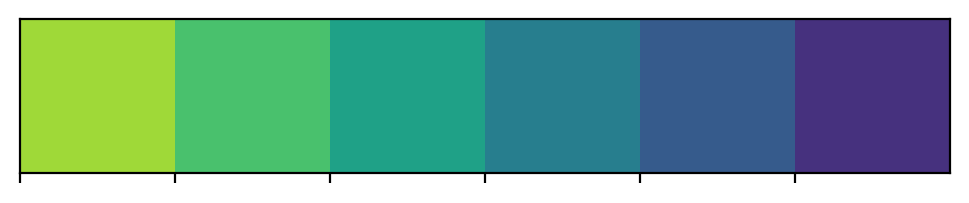

In [9]:
mako = sns.color_palette('viridis', n_colors=6)
mako = mako[::-1] #reverse the palette

#visualize mako palette
sns.palplot(mako)
#plt.show()

In [10]:
# plot line graph for each replicate, using 'Group' as hue to separate the two measurements
def plotLineGraph(rep_df, title, filename):
    fig, ax = plt.subplots()
    sns.lineplot(data=rep_df, x='Time', y='Intensity', hue='Group', palette=mako)
    
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Intensity (a.u.)')

    ax.set_ylim(0, 200) #set limit to 200
    ax.legend(labels=['ex: 450 / em: 540', 'ex: 450 / em: 650'])
    annotate_ax(ax, title)
    
    # save plot as png
    #plt.savefig(result_folder / f'{filename}.png', dpi=300, bbox_inches='tight')

2


/var/folders/zg/rq8bx0nn20ldz2y3n2vmj4rw0000gn/T/ipykernel_4104/2641924624.py:4: UserWarning: The palette list has more values (6) than needed (2), which may not be intended.
  sns.lineplot(data=rep_df, x='Time', y='Intensity', hue='Group', palette=mako)


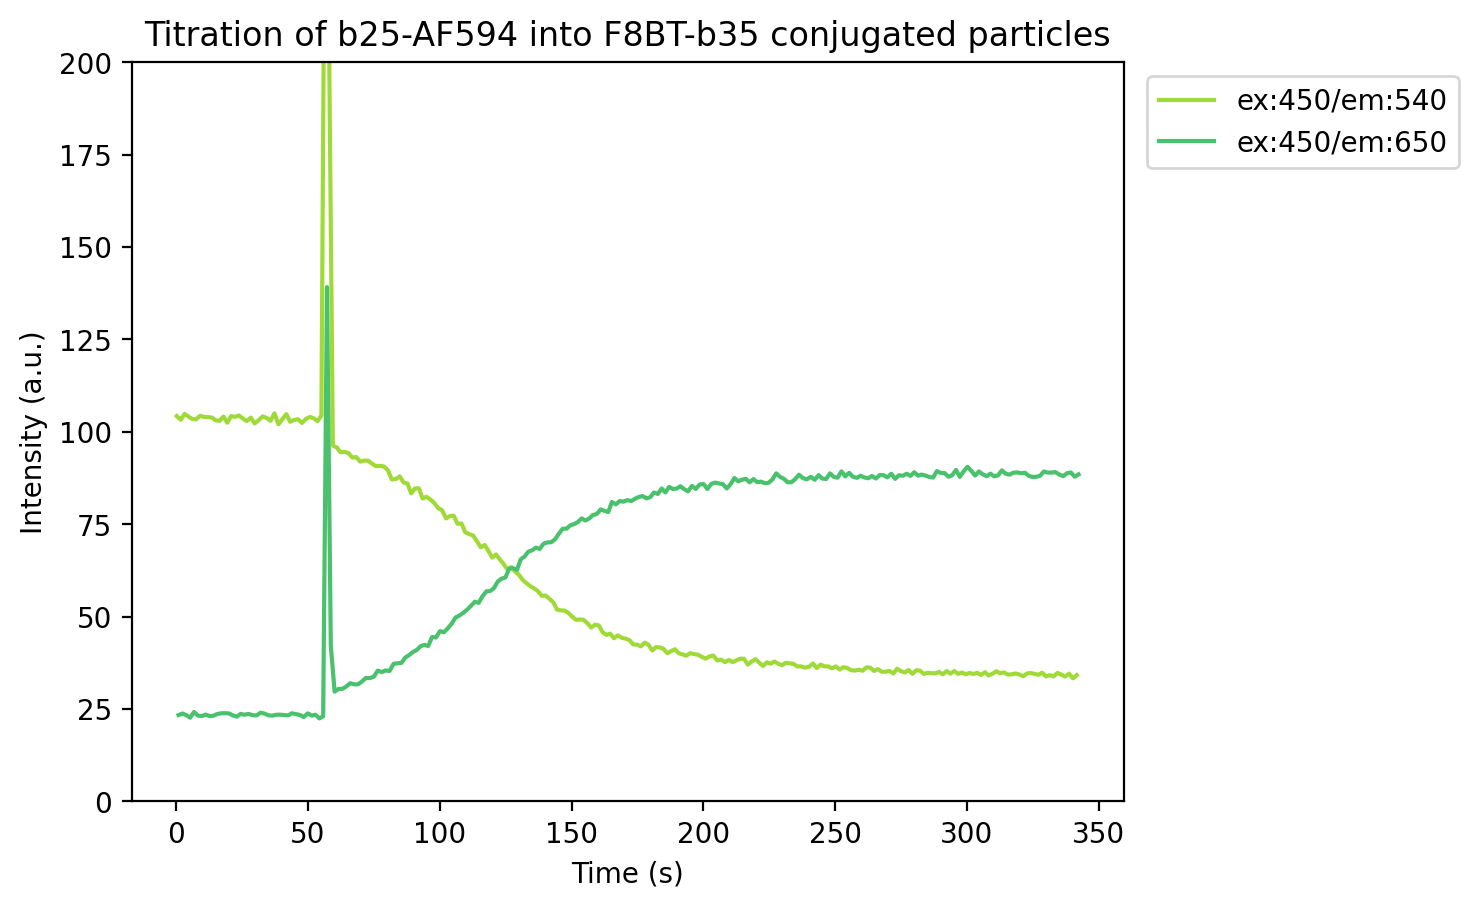

In [11]:
name = 'r5um_02'
# extract last number to get replicate
replicate = name[-1:]
print(replicate)
# extract letters between r and _
conc = name.split('_')[0][1:]

plotLineGraph(r5um_02, "Titration of b25-AF594 into F8BT-b35 conjugated particles", f"{conc}-rep-{replicate}")

----
# Part 2. Second order rxn rate fitting

The initial concentration of the fluorophore is extrapolated as intensity.
- For rep1 we are interested in time regime: 57.65874863 till 459.8099976 for regime 1, and from 461.2600098 till 1056.52002
- For rep2 we are interested in time regime: 76.66374969 till 719.1837769 for regime 1
- For rep3 we are interested in time regime: 70.01499939 till 896.7312622 for regime 1

^For each graph extract only these regions, and store in a rep1trunc, rep2trunc, rep3trunc dataframe.

In [12]:
# add a second column called Wavelength to each dataframe, that extracts the last three numbers from Group
def waveExtractor(rep_df):
    rep_df['Wavelength'] = rep_df['Group'].str.extract(r'(\d+$)')
    #and ensure it is numeric
    rep_df['Wavelength'] = pd.to_numeric(rep_df['Wavelength'])
    return rep_df

r1um_01 = waveExtractor(r1um_01)
r1um_02 = waveExtractor(r1um_02)
r500nm_stopped = waveExtractor(r500nm_stopped)
r500nm_01 = waveExtractor(r500nm_01)
r500nm_02 = waveExtractor(r500nm_02)
r500nm_03 = waveExtractor(r500nm_03)
r2um_01 = waveExtractor(r2um_01)
r2um_02 = waveExtractor(r2um_02)
r2um_03 = waveExtractor(r2um_03)
r5um_01 = waveExtractor(r5um_01)
r5um_02 = waveExtractor(r5um_02)
r5um_03 = waveExtractor(r5um_03)
r8um_01 = waveExtractor(r8um_01)
r8um_02 = waveExtractor(r8um_02)
r8um_03 = waveExtractor(r8um_03)

In [13]:
# define regime of time for rep 1 to extract data from i.e. from 57.65874863 till 459.8099976 for regime 1
r101 = r1um_01[(r1um_01['Time'] >= 61.45624924) & (r1um_01['Time'] < 815.2212524)] #only take first regime because the 2nd part of the curve appears to already have gone to completion (file 02)
r102 = r1um_02[(r1um_02['Time'] >= 65.56200244) & (r1um_02['Time'] < 866.9324951)] #file 12 ; last time is basically till the end of the file.
r50001 = r500nm_01[(r500nm_01['Time'] >= 67.20500183) & (r500nm_01['Time'] < 1335.527466)] #file 04
r50002 = r500nm_02[(r500nm_02['Time'] >= 66.35874939) & (r500nm_02['Time'] < 1293.278809)] #file 05
#r50003 = r500nm_03[(r500nm_03['Time'] >= ) & (r500nm_03['Time'] < )] #fitted the first part of the curve only? note this might not acc have been 500 but more like 1 uM instead.

r201 = r2um_01[(r2um_01['Time'] >= 67.66374969) & (r2um_01['Time'] < 548.5437622)] # file 06 {first injection only}
r202 = r2um_02[(r2um_02['Time'] >= 77.26499939) & (r2um_02['Time'] < 550)] # file 07, approximated till end bc didnt have to do full curve.
r203 = r2um_03[(r2um_03['Time'] >= 65.36374664) & (r2um_03['Time'] < 600)] #file 11 ; approximated cutoff at 600 end

r501 = r5um_01[(r5um_01['Time'] >= 67.11374664) & (r5um_01['Time'] < 347.573761)] #file 08
r502 = r5um_02[(r5um_02['Time'] >= 59.46125031) & (r5um_02['Time'] < 341.6620085)] #file 09
r503 = r5um_03[(r5um_03['Time'] >= 65.56375122) & (r5um_03['Time'] < 367.1187439)] #file 10

r801 = r8um_01[(r8um_01['Time'] >= 64.56200244) & (r8um_01['Time'] < 242.1649933)] #file 13
r802 = r8um_02[(r8um_02['Time'] >= 63.95500183) & (r8um_02['Time'] < 242.9137573)] #file 14
r803 = r8um_03[(r8um_03['Time'] >= 67.21125031) & (r8um_03['Time'] < 280.6712646)] # file 15

td101 = r101['Time'].max() - r101['Time'].min()
td102 = r102['Time'].max() - r102['Time'].min()
td50001 = r50001['Time'].max() - r50001['Time'].min()
td50002 = r50002['Time'].max() - r50002['Time'].min()
td201 = r201['Time'].max() - r201['Time'].min()
td202 = r202['Time'].max() - r202['Time'].min()
td203 = r203['Time'].max() - r203['Time'].min()
td501 = r501['Time'].max() - r501['Time'].min()
td502 = r502['Time'].max() - r502['Time'].min()
td503 = r503['Time'].max() - r503['Time'].min()
td801 = r801['Time'].max() - r801['Time'].min()
td802 = r802['Time'].max() - r802['Time'].min()
td803 = r803['Time'].max() - r803['Time'].min()

tdiff_list = [td101, td102, td50001, td50002, td201, td202, td203, td501, td502, td503, td801, td802, td803]

r102.head()

,Time,Intensity,Group,Wavelength
45,65.565002,104.261612,ex:450/em:540,540
641,66.233749,25.044765,ex:450/em:650,650
46,66.964996,105.035393,ex:450/em:540,540
642,67.633751,24.973000,ex:450/em:650,650
47,68.415001,103.509377,ex:450/em:540,540


In [14]:
# A0 is the first intensity value in the regime i.e.
r101_A0 = r101['Intensity'].iloc[0]
r101_650 = r101['Intensity'].iloc[1]

r102_A0 = r102['Intensity'].iloc[0]
r102_650 = r102['Intensity'].iloc[1]

r50001_A0 = r50001['Intensity'].iloc[0]
r50001_650 = r50001['Intensity'].iloc[1]
r50002_A0 = r50002['Intensity'].iloc[0]
r50002_650 = r50002['Intensity'].iloc[1]

r201_A0 = r201['Intensity'].iloc[0]
r201_650 = r201['Intensity'].iloc[1]
r202_A0 = r202['Intensity'].iloc[0]
r202_650 = r202['Intensity'].iloc[1]
r203_A0 = r203['Intensity'].iloc[0]
r203_650 = r203['Intensity'].iloc[1]

r501_A0 = r501['Intensity'].iloc[0]
r501_650 = r501['Intensity'].iloc[1]
r502_A0 = r502['Intensity'].iloc[0]
r502_650 = r502['Intensity'].iloc[1]
r503_A0 = r503['Intensity'].iloc[0]
r503_650 = r503['Intensity'].iloc[1]

r801_A0 = r801['Intensity'].iloc[0]
r801_650 = r801['Intensity'].iloc[1]
r802_A0 = r802['Intensity'].iloc[0]
r802_650 = r802['Intensity'].iloc[1]
r803_A0 = r803['Intensity'].iloc[0]
r803_650 = r803['Intensity'].iloc[1]

# turn these into a list
A0_list = [r101_A0, r102_A0, r50001_A0, r50002_A0, r201_A0, r202_A0, r203_A0, r501_A0, r502_A0, r503_A0, r801_A0, r802_A0, r803_A0]

___
# Part 3: Fitting a Sigmoidal function to the data

Inspiration paper: https://pubs.acs.org/doi/10.1021/acsanm.0c02104 <-- paper that discusses how surface density of DNA on a nanoparticle influences the kinetics of the reaction.

"By understanding how the surface density of DNA modulates the cooperativity and attinebility of the oligonucleotides, the accessibility of the linkers to the target nucleic acid, and the repulsion between the nanoparticles, we demonstrate that the optimal combination of surface densities for rapid nanoparticle disassembly is one that facilitates target hybridization while maintaining a high repulsive force."

"In each grouped combination inFigure 1a−c, we observed faster hybridization and aggregationkinetics with increased Probe density at a ﬁxed Seq 2 density.Figure 1b shows that the hybridization transition time (Th), determined from the minimum of the ﬁrst derivatives of the aggregation curve"
- Action: take the derivative of the sigmoidal function to find Th.

Why is high local density good?
A: "the cooperativity eﬀect.6,31−34 When the DNA density ishigh, there are many DNA linkers at the interparticle junction;they synergistically enhance the apparent aﬃnity of a singleduplex. This phenomenon is known as avidity, where onehybridization event can enhance other strands at theinterparticle space to hybridize due to the aligned orientationand proximity of DNA that has limited lateral ﬂexibility."
A2: "high local density also promotes the rehybridization of strands that have transiently dehybridized" <-- a concept known as attinebility by Vörös and co-workers; it refers to the enhanced retention of an incoming target strand near the high local concentration of ligands. The probability of the target diﬀusing away from the particle surface after a transient dissociation event is low when the density of DNA is high because of fast rehybridization. Attinebility, therefore, leads to a smaller dissociation rate constant of DNA on surfaces compared to in solution."

The paper also made use of a <b> Logistic function model </b> is:

Y = A1 + (A2 - A1) / (1 + 10^{(x_0 -x)p})^s

Where:
> We ﬁtted the melting data to a ﬁve-parameter logistic equation 39 (eq 1) where A1 is the bottom asymptote, A2 is the top asymptote, x0 is the center of the transition, p is the Hill slope, and S is asymmetry parameter. BUT we use:
<br>
<b> Alternatively we use:
Y = A1 + (A2 - A1) / (1 + (x/c)^p)^s </b> 

Where:
- Coefficients A2 and A1 control the location of the upper and the lower asymptotes of the equation. These are the values that the responses ( y ) approach as the log of the dose ( x ) approach 0 and infinity.
- Coefficient c controls the location of the transition on the dose ( x ) axis. This is the inflection point in the transition between the two asymptotes. In 4PL regressions, c is the midpoint between the two asymptotes.  In 5PL regressions, c is above or below the midpoint between the two asymptotes.
- Coefficient p is the slope at the transition point ( c ) and controls the rate of approach to the asymptotes. The sign of p controls whether the curve is monotonically ascending or descending.
- Coefficient s controls the asymmetry in a 5PL curve. This is the difference in the rates of approach from the inflection point ( c ) to the lower and the upper asymptotes. In a 4PL curve, s = 1 and is factored out.  In a 5PL curve, g is less than or greater than 1, depending upon the location of the inflection point.

#### Q: Should we use a 4PL or 5PL model?
The 4PL curve model describes a sigmoidal shape that is symmetric around its inflection point (where the curve changes from convex to concave) in the middle of the curve.  The 5PL curve model describes a sigmoidal shape that is asymmetric with an inflection point above or below the middle of the curve. (see source: https://www.brendan.com/comparing-4pl-5pl-curve-fitting-and-optimizing-calibrator-doses/)

Thus: use a 5PL because we are not sure the inflection point is exactly in the center.

In [ ]:
# In SciPy’s curve_fit, the first argument of the fitting function must be the independent variable (here, your time values) i.e.
# curve_fit expects your function signature to be f(x, *params), with x first, followed by the parameters to be optimized. Thus x should go first.
def five_parameter_logistic_equation(x, A1, A2, x0, p, S):
    return A1 + ((A2 - A1) / (1 + 10**(x0 - x)*p)**S)

In [16]:
def alt_five_param_logistic_equation(x, A1, A2, c, p, S):
    return A1 + ((A2 - A1) / (1 + (x/c)**p)**S) #this is the original equation

#### Conclusion: the alt_five_param_logistic_equation works great! Use this for all fitting of curves.

In [17]:
def fit_reaction_segments(df, wavelength, A0_guess, repnumber):
    data = df[df['Wavelength'] == wavelength].copy()
    segment1 = data
    segment1['Time_normalized'] = segment1['Time'] - segment1['Time'].min() # Normalize time to start at 0 for each segment
    
    # Choose appropriate function based on wavelength
    wavelength = str(wavelength)
    if wavelength == '540':
        #fit_func = five_parameter_logistic_equation
        fit_func = alt_five_param_logistic_equation #for 540 nm, use the alternative function
    else:
        #fit_func = five_parameter_logistic_equation #for 650 nm, use the same function as for 540 nm
        fit_func = alt_five_param_logistic_equation
        
    #print which function is being used
    print(f'Fitting data for {wavelength} nm')
        
    # Set better initial guesses (this is the offset, C)
    final_intensity = segment1['Intensity'].iloc[-1]
    
    try:
        popt, pcov = curve_fit(
            fit_func, 
            segment1['Time_normalized'], #x
            segment1['Intensity'], #y
            p0=[final_intensity, A0_guess, final_intensity/1.5, 1e-3, 1.0],  # initial guesses for A, A2, x0, p, S 
            #NOTE: we don't divide final_intensity by 2 because the data is a 5PL so we expect the inflection point to be above or below, not in the exact middle.
            bounds=([0, 0, 0, 1e-8, 0],[np.inf, np.inf, np.inf, np.inf, np.inf]),
            maxfev=10000)
        
    except RuntimeError as e:
        print(f"Failed to fit data for {wavelength}nm: {str(e)}")
        return None
    
    # if A0_guess is your initial conc. (in same units as Intensity)
    A1, A2, c, p, S = popt

    # note that for second order kinetics of A + A -> P, the rate law is:
    # t_1/2 = 1 / k[A]_0 so we can simply take the fitted value of c and divide by the initial concentration to get k.
    k_effective = 1.0 / (c * A0_guess)
    
    if repnumber.startswith('1'):
        k_effective /= 1e-0
    elif repnumber.startswith('2'):
        k_effective /= 2e-0
    elif repnumber.startswith('5'):
        k_effective /= 5e-0
    elif repnumber.startswith('8'):
        k_effective /= 8e-0
    else:
        print(f"Unknown replicate number: {repnumber}. Using k_per_s as is.")

    k_effective = 1/k_effective

    print(f"Derived 2nd‐order k = {k_effective:.3e} (same units as your 2nd‐order fit)")
    
    # Plot results
    plt.figure(figsize=(10, 6))
    plt.scatter(data['Time'], data['Intensity'], alpha=0.5, label='Data')
    
    if popt is not None:
        t_fit = np.linspace(0, segment1['Time_normalized'].max(), 100)
        y_fit = fit_func(t_fit, *popt)
        plt.plot(t_fit + segment1['Time'].min(), y_fit, 'r-', label=f'Fit 1 (k={k_effective:.3e} s⁻¹)')
    
    plt.xlabel('Time (s)')
    plt.ylabel('Intensity (a.u.)')
    plt.title(f'Second Order Reaction Fits for {wavelength}nm, {repnumber}')
    plt.legend()

    popt[0] = k_effective
    
    #save figure as png
    plt.savefig(result_folder / f'2ndfit_{wavelength}_{repnumber}.png', dpi=300, bbox_inches='tight')
    
    #save popt and pcov parameters to a text file as well
    with open(result_folder / f'2ndfit_{wavelength}_r{repnumber}.txt', 'w') as f:
        f.write(f'params: {popt} \n covariance: {pcov}')
        
    return {
        'params': popt,
        'covariance': pcov,
        'A0_guess' : A0_guess
    }

Fitting data for 540 nm
Derived 2nd‐order k = 3.408e+07 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 6.292e+07 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 2.605e+05 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 6.365e+06 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 1.165e+05 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 3.824e+06 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 2.906e+05 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 8.523e+04 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 5.754e+04 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 4.306e+04 (same units as your 2nd‐order fit)
Fitting data for 540 nm
Derived 2nd‐order k = 3.560e+04 (same units as your 2nd‐order fit)

/var/folders/zg/rq8bx0nn20ldz2y3n2vmj4rw0000gn/T/ipykernel_4104/2790829300.py:58: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10, 6))


Fitting data for 650 nm
Derived 2nd‐order k = 1.734e+04 (same units as your 2nd‐order fit)
Fitting data for 650 nm
Derived 2nd‐order k = 2.050e+04 (same units as your 2nd‐order fit)
Fitting data for 650 nm
Derived 2nd‐order k = 2.796e+04 (same units as your 2nd‐order fit)
Fitting data for 650 nm
Derived 2nd‐order k = 2.514e+04 (same units as your 2nd‐order fit)


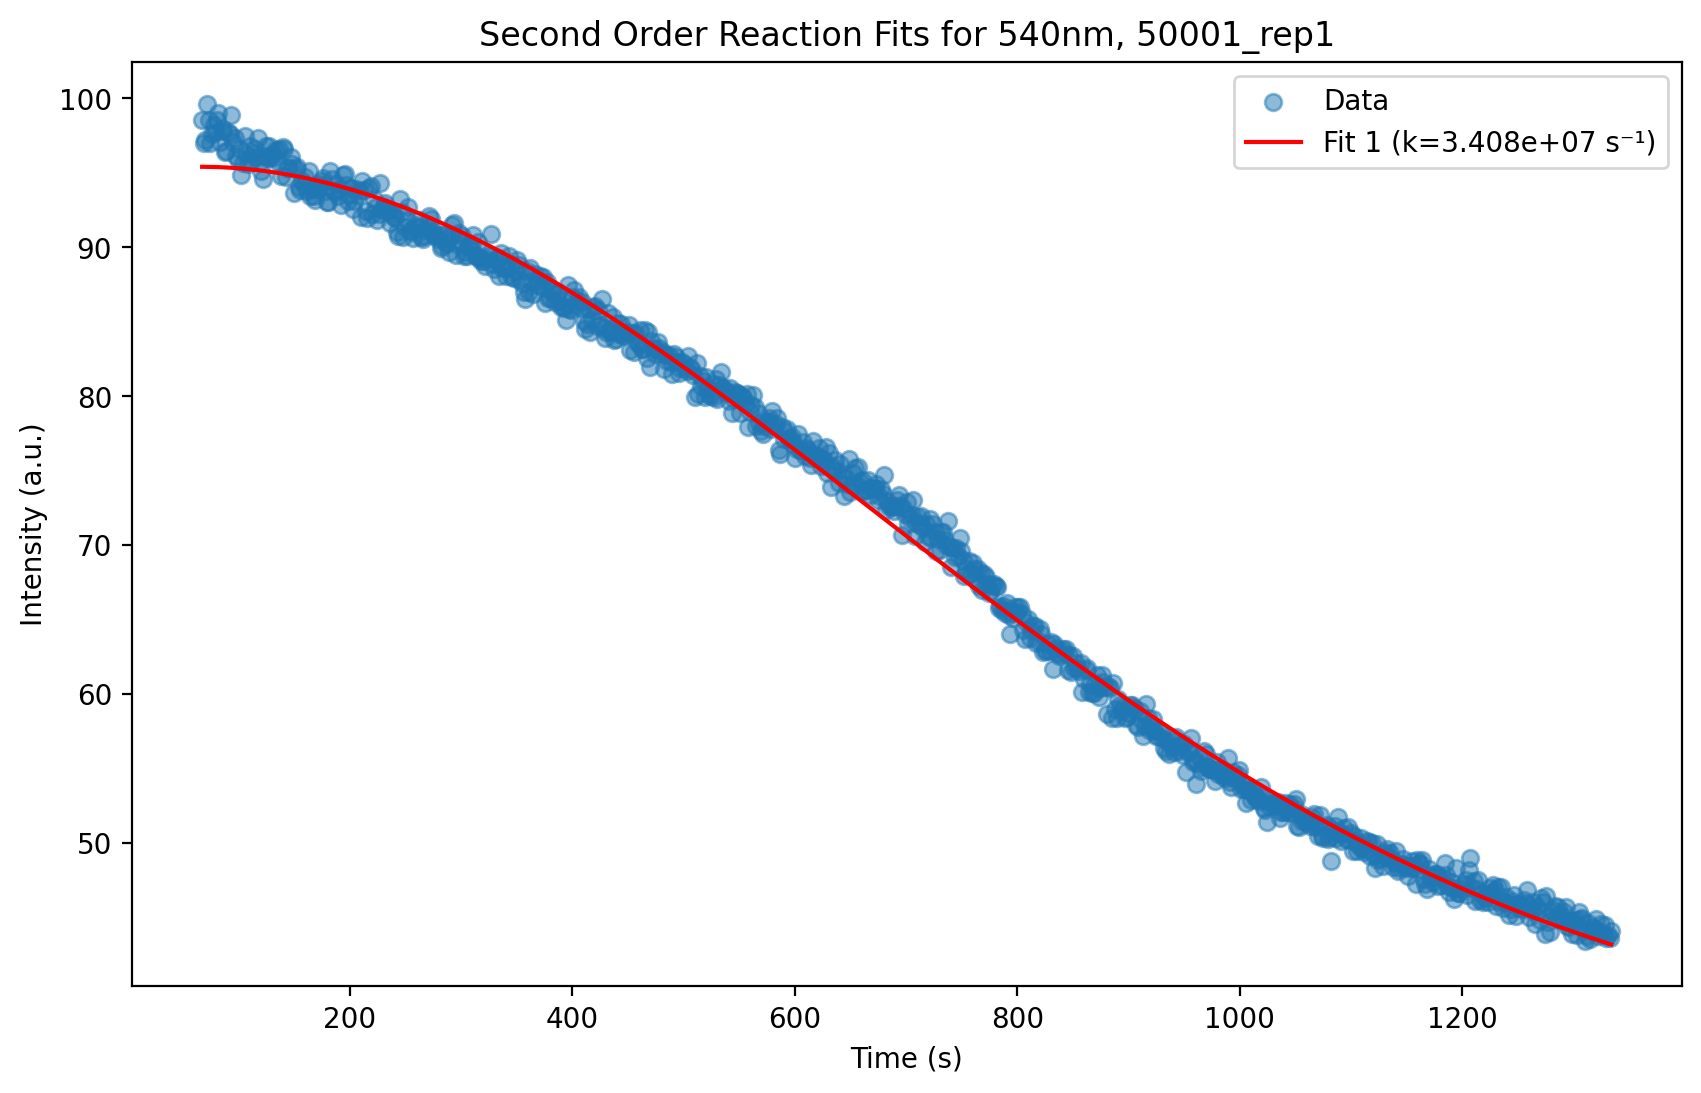

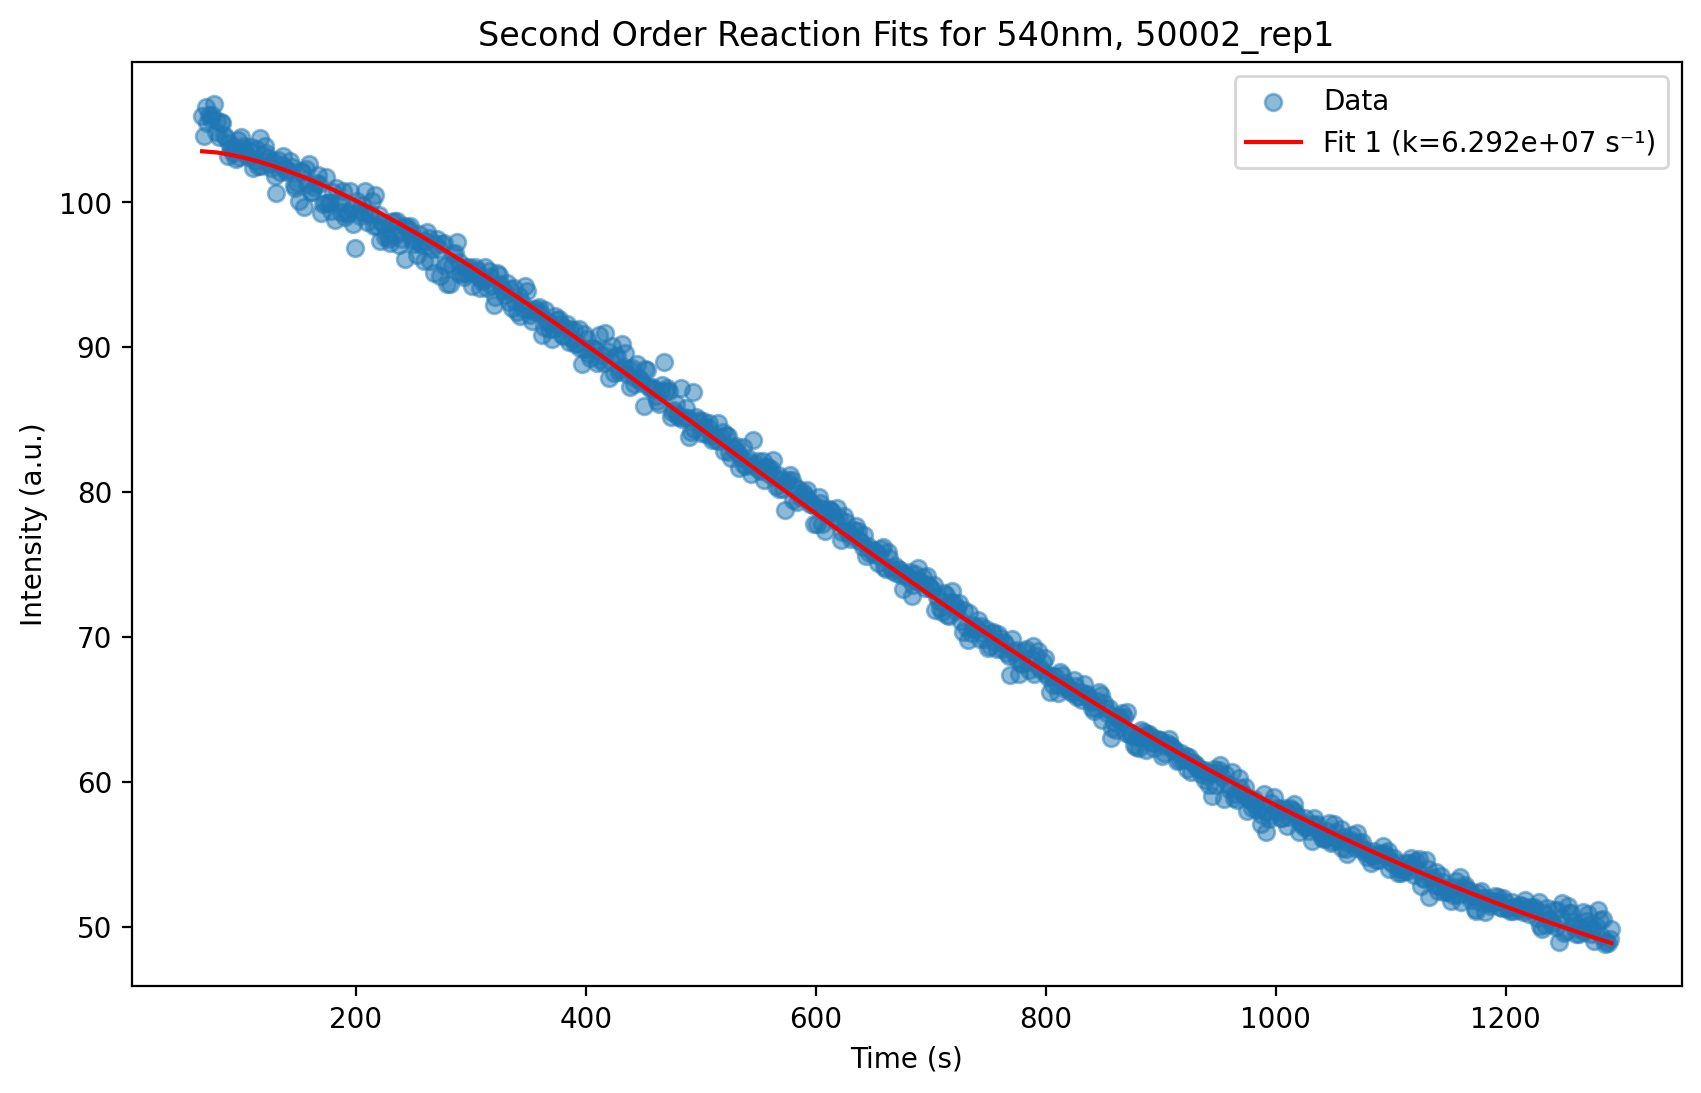

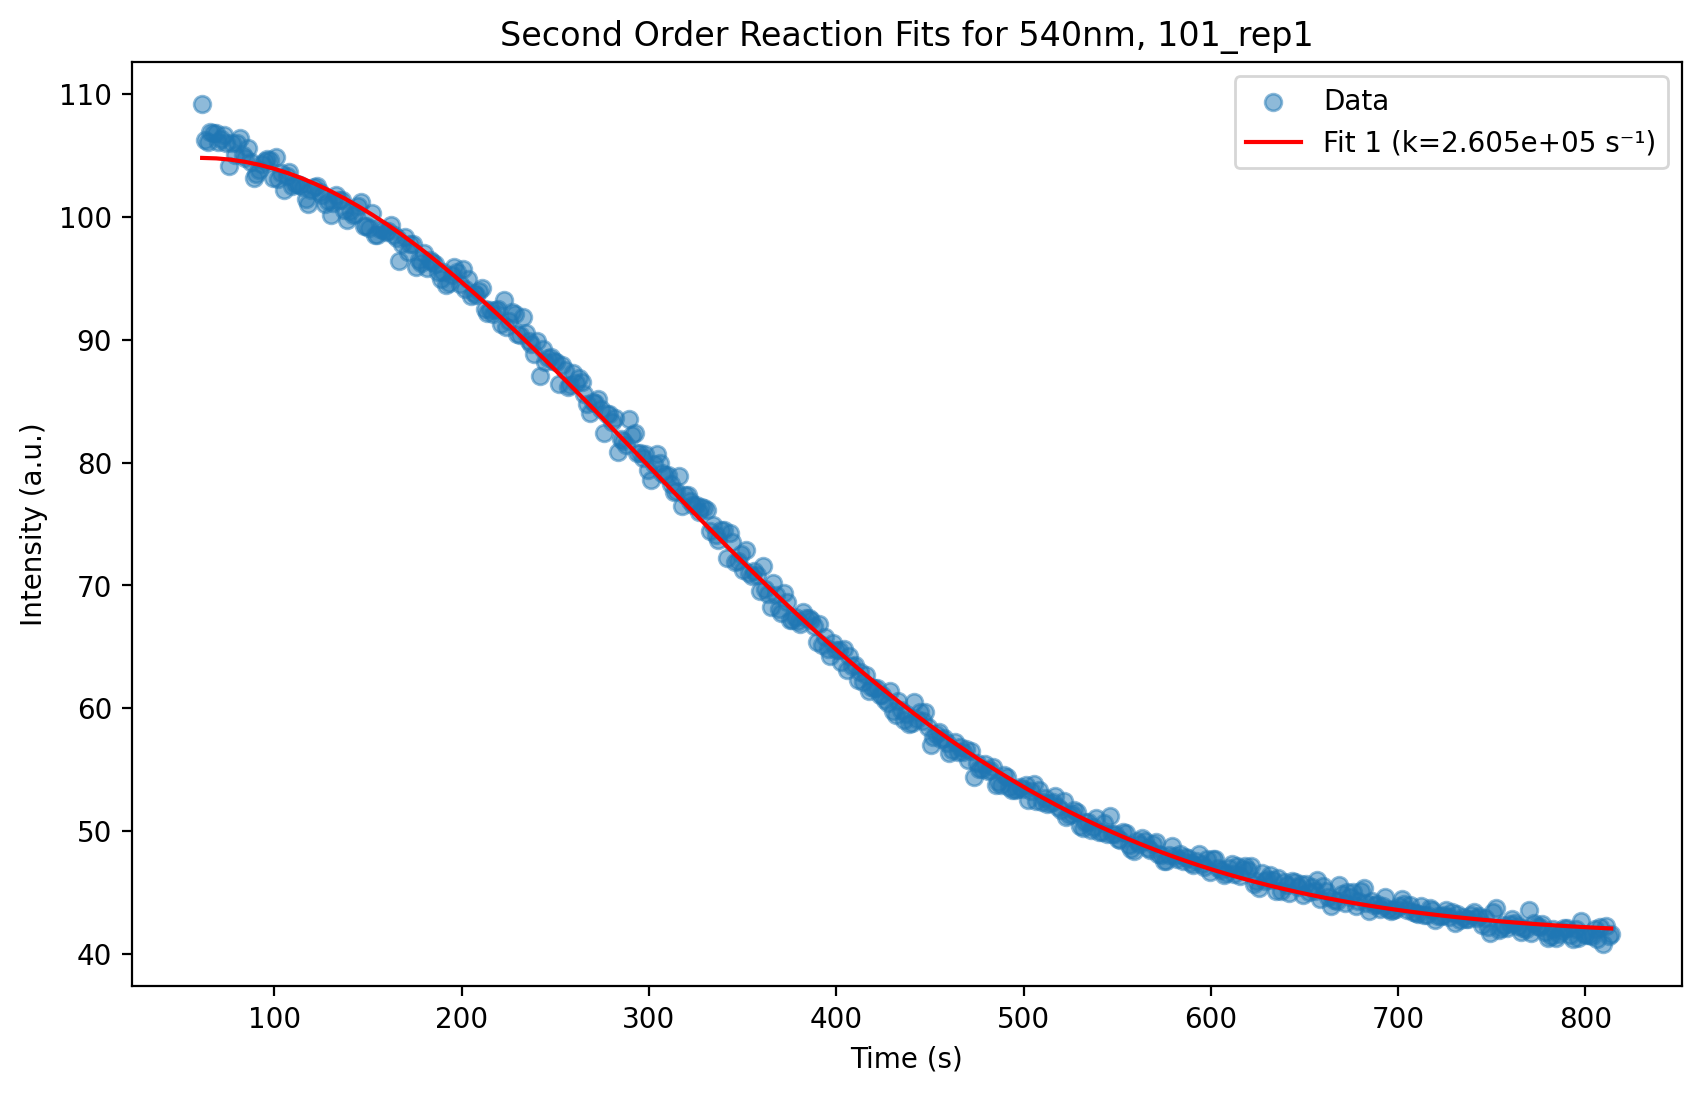

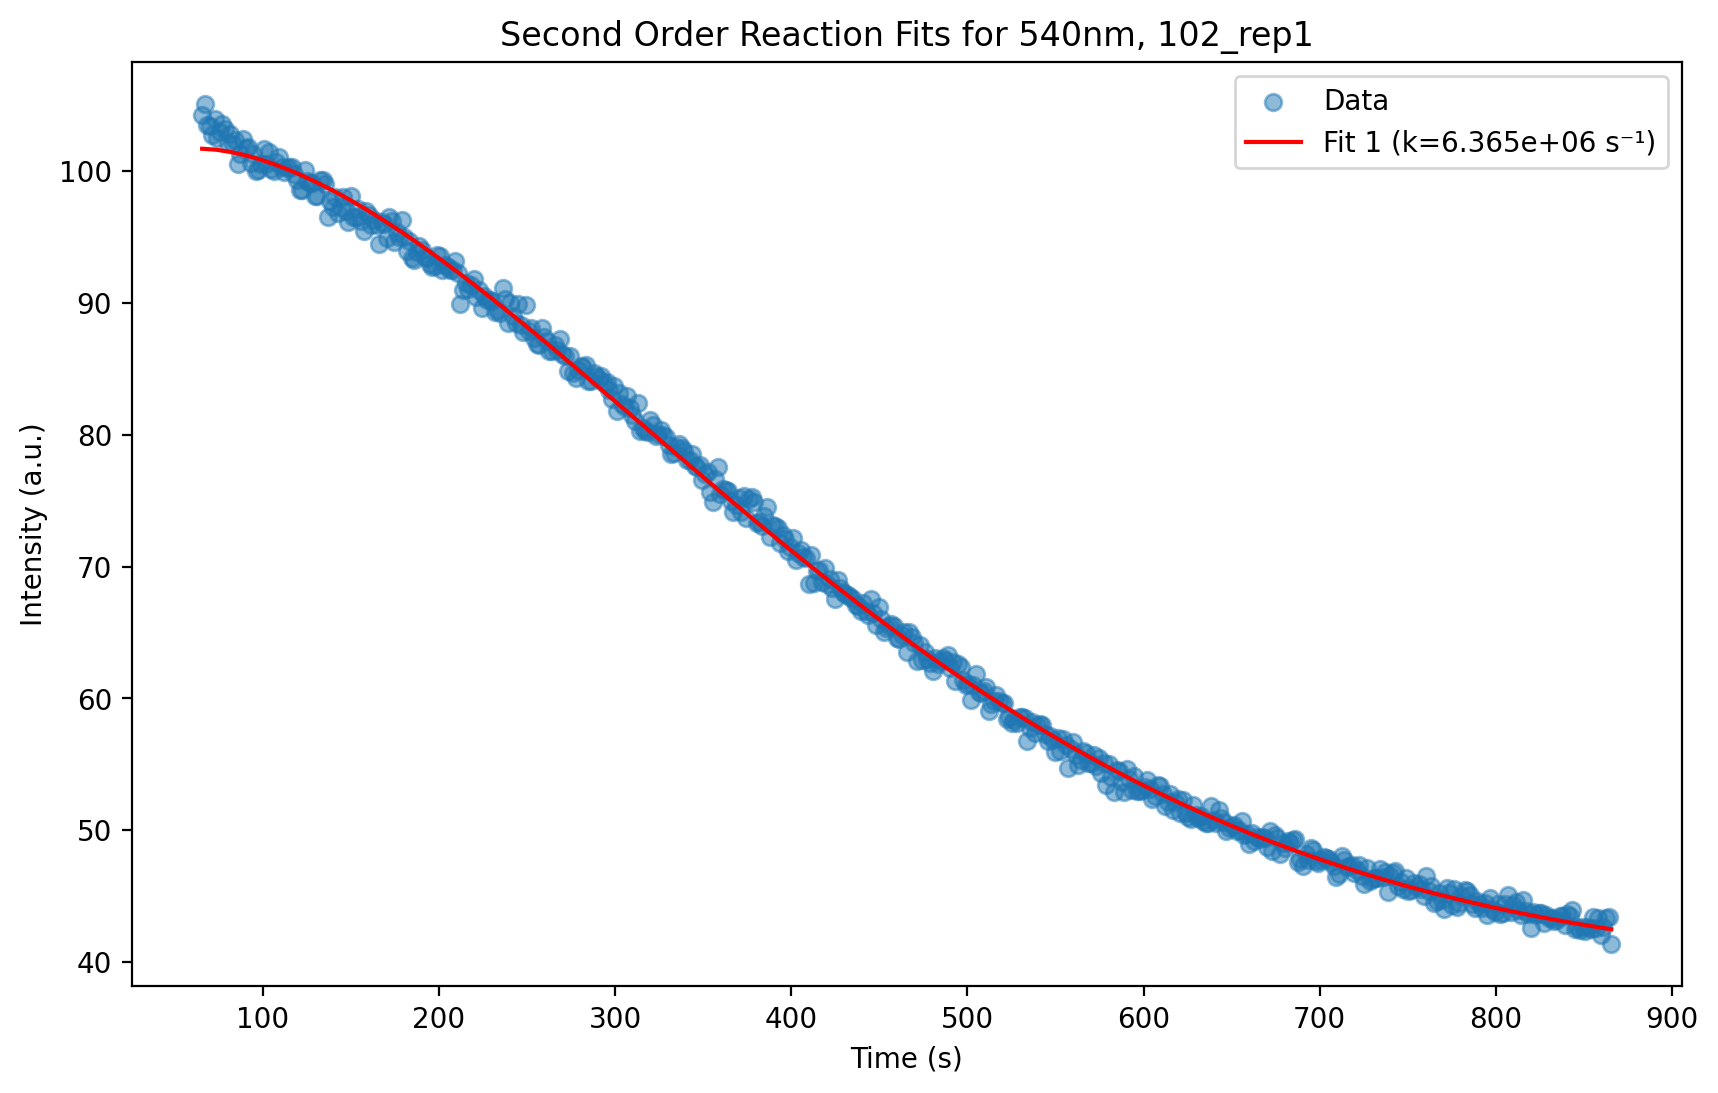

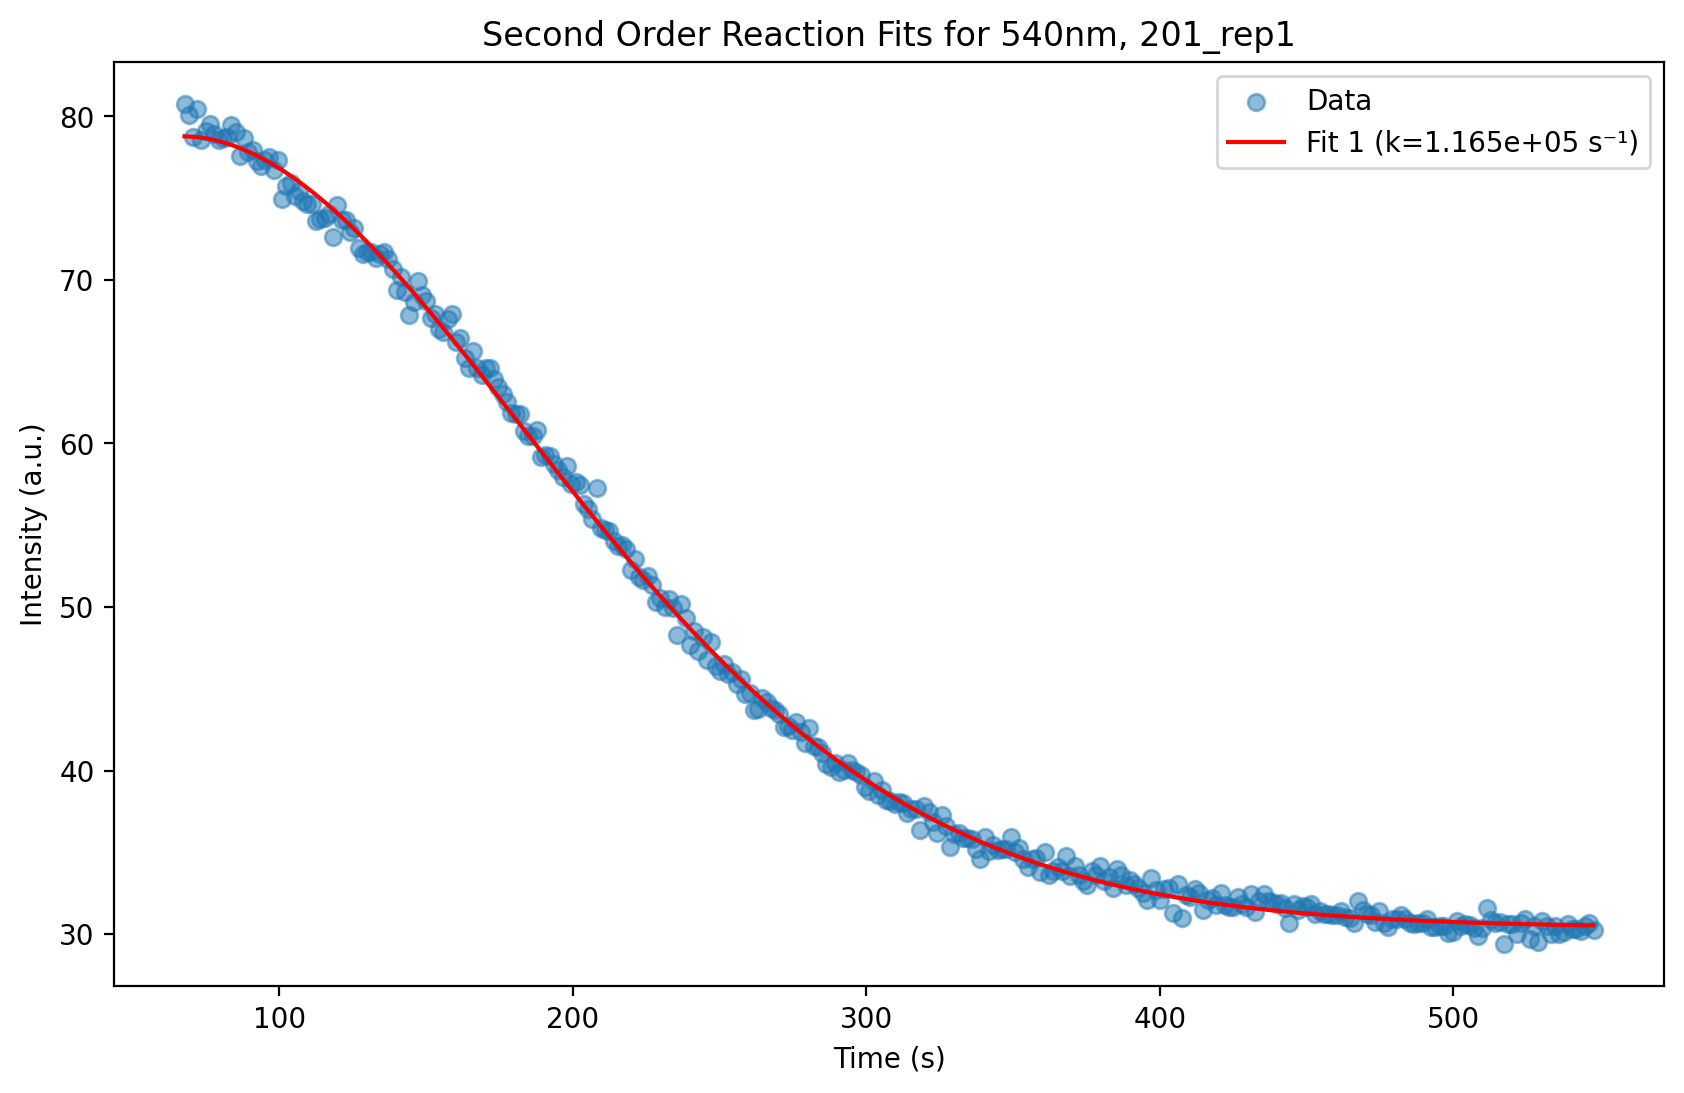

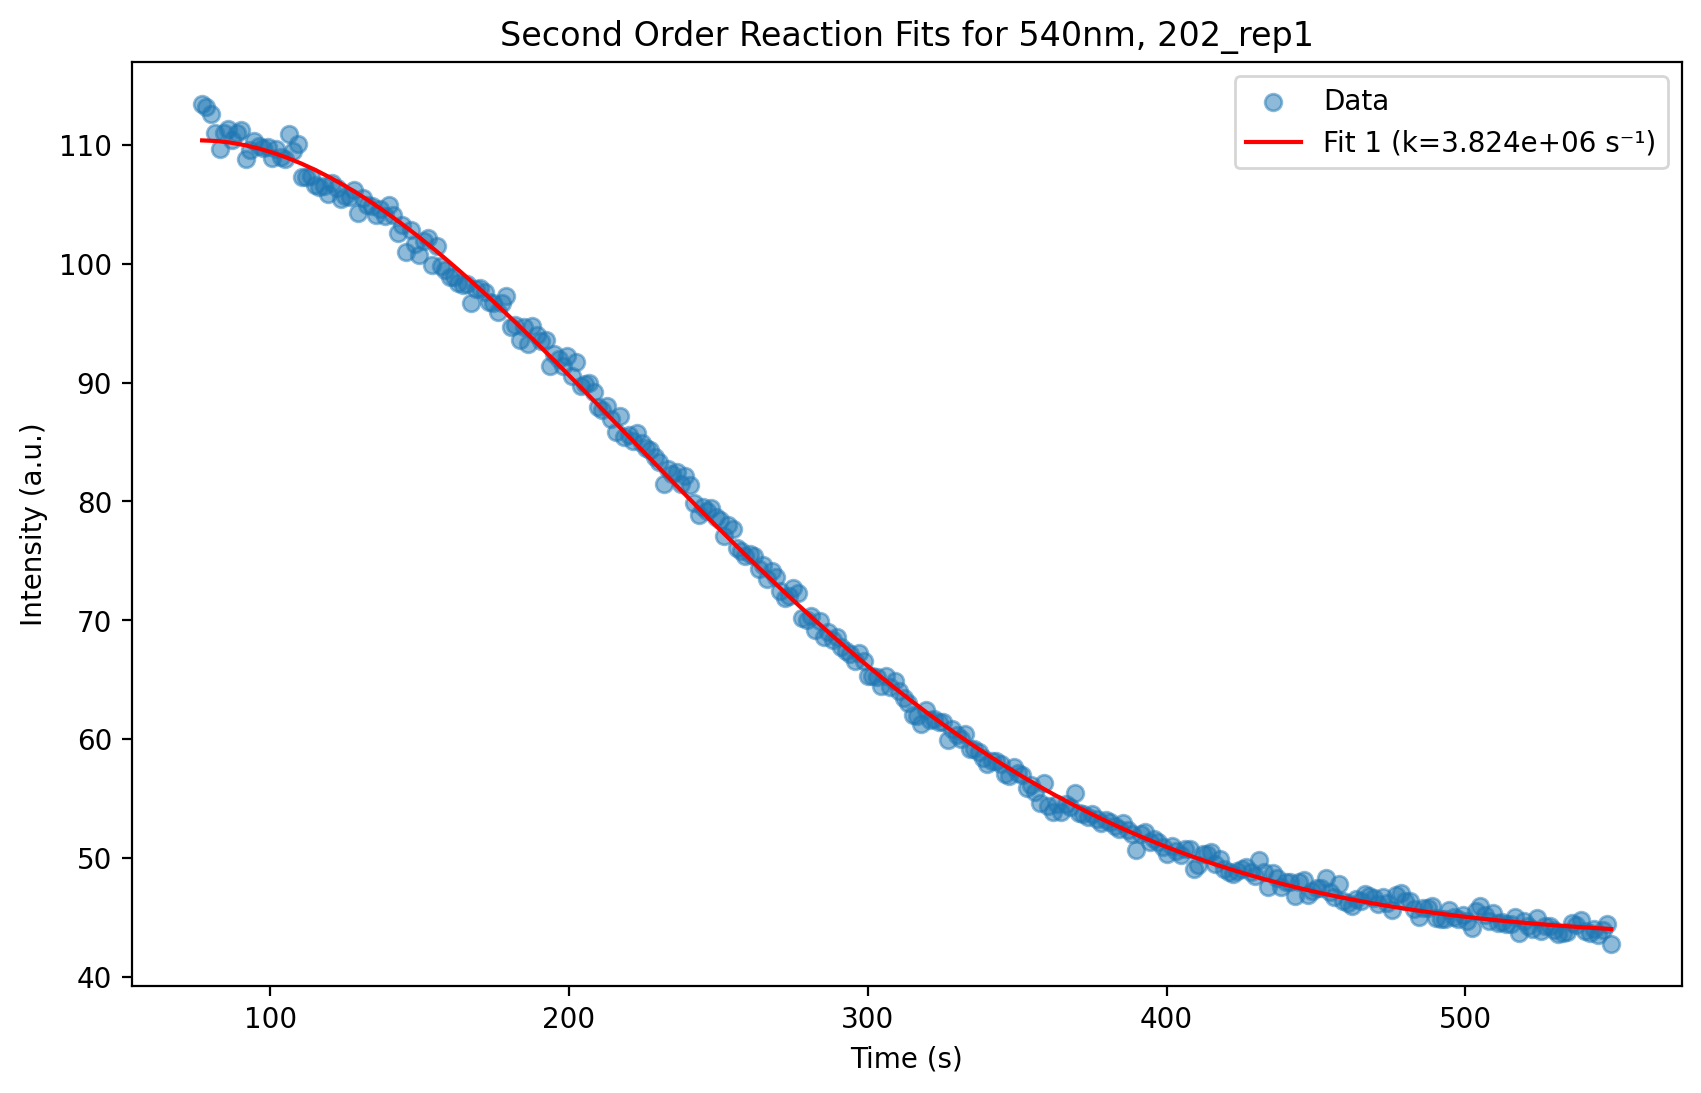

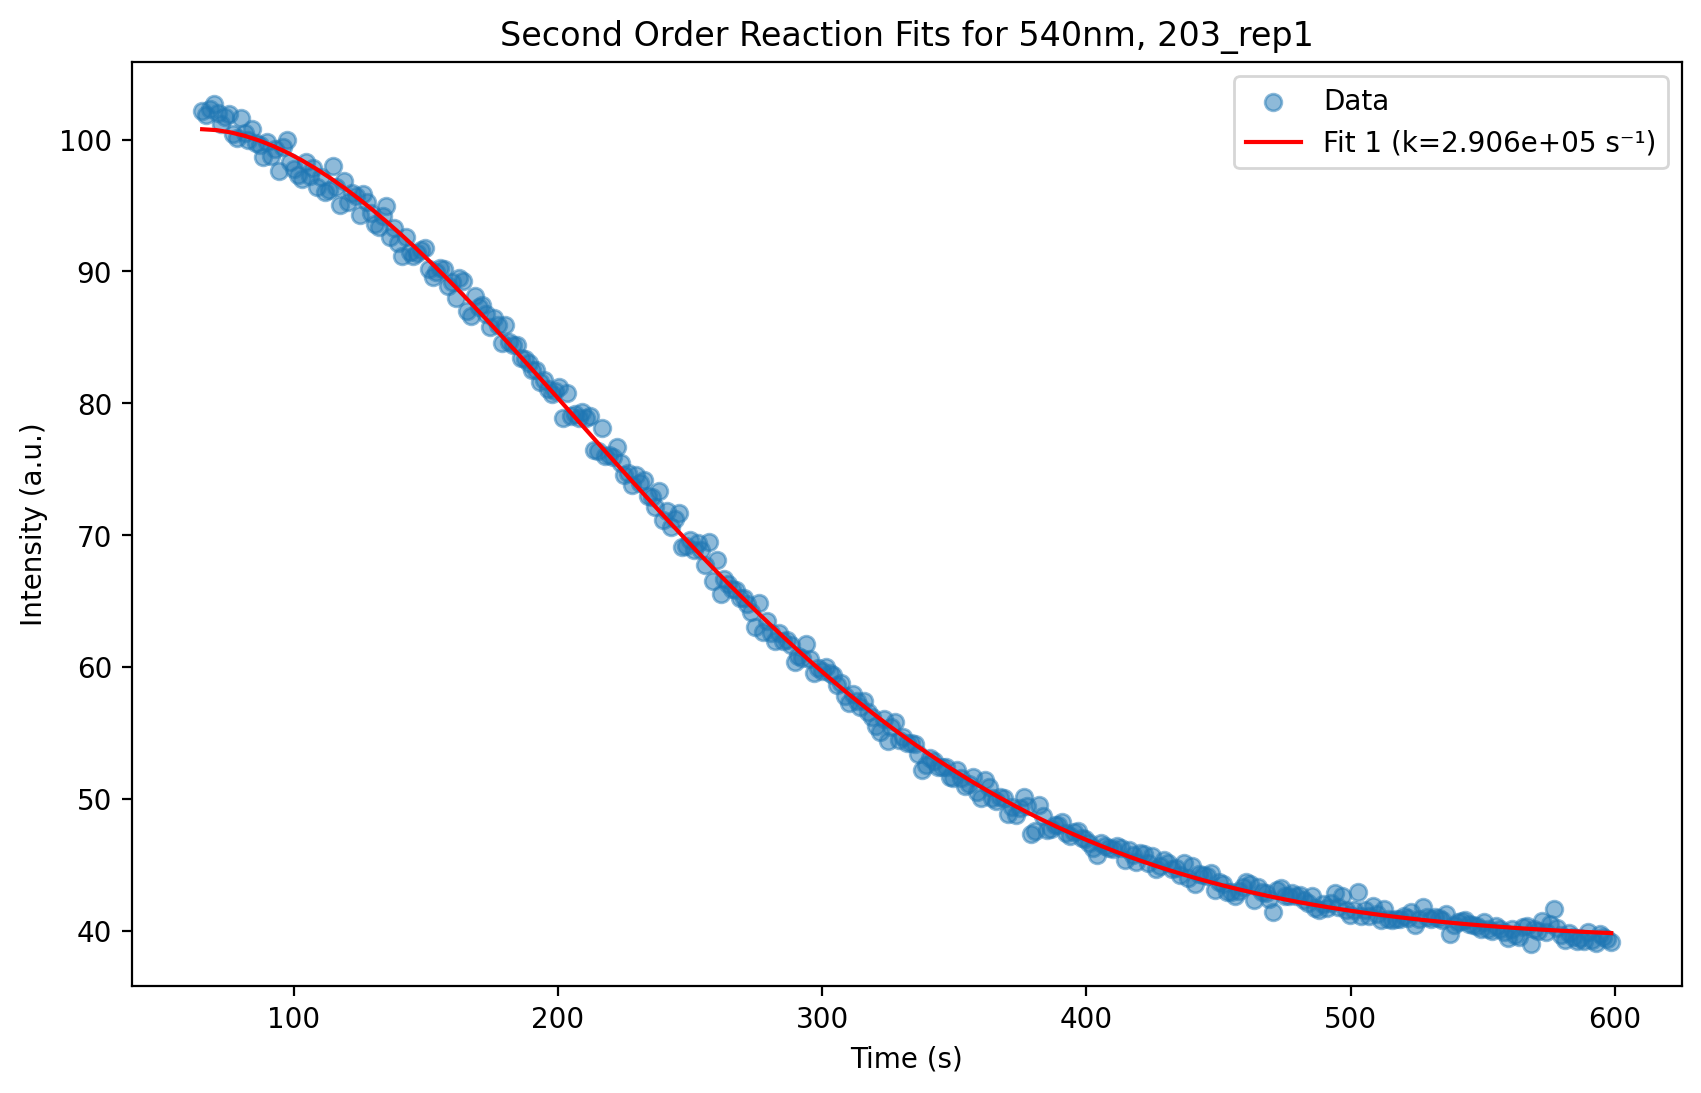

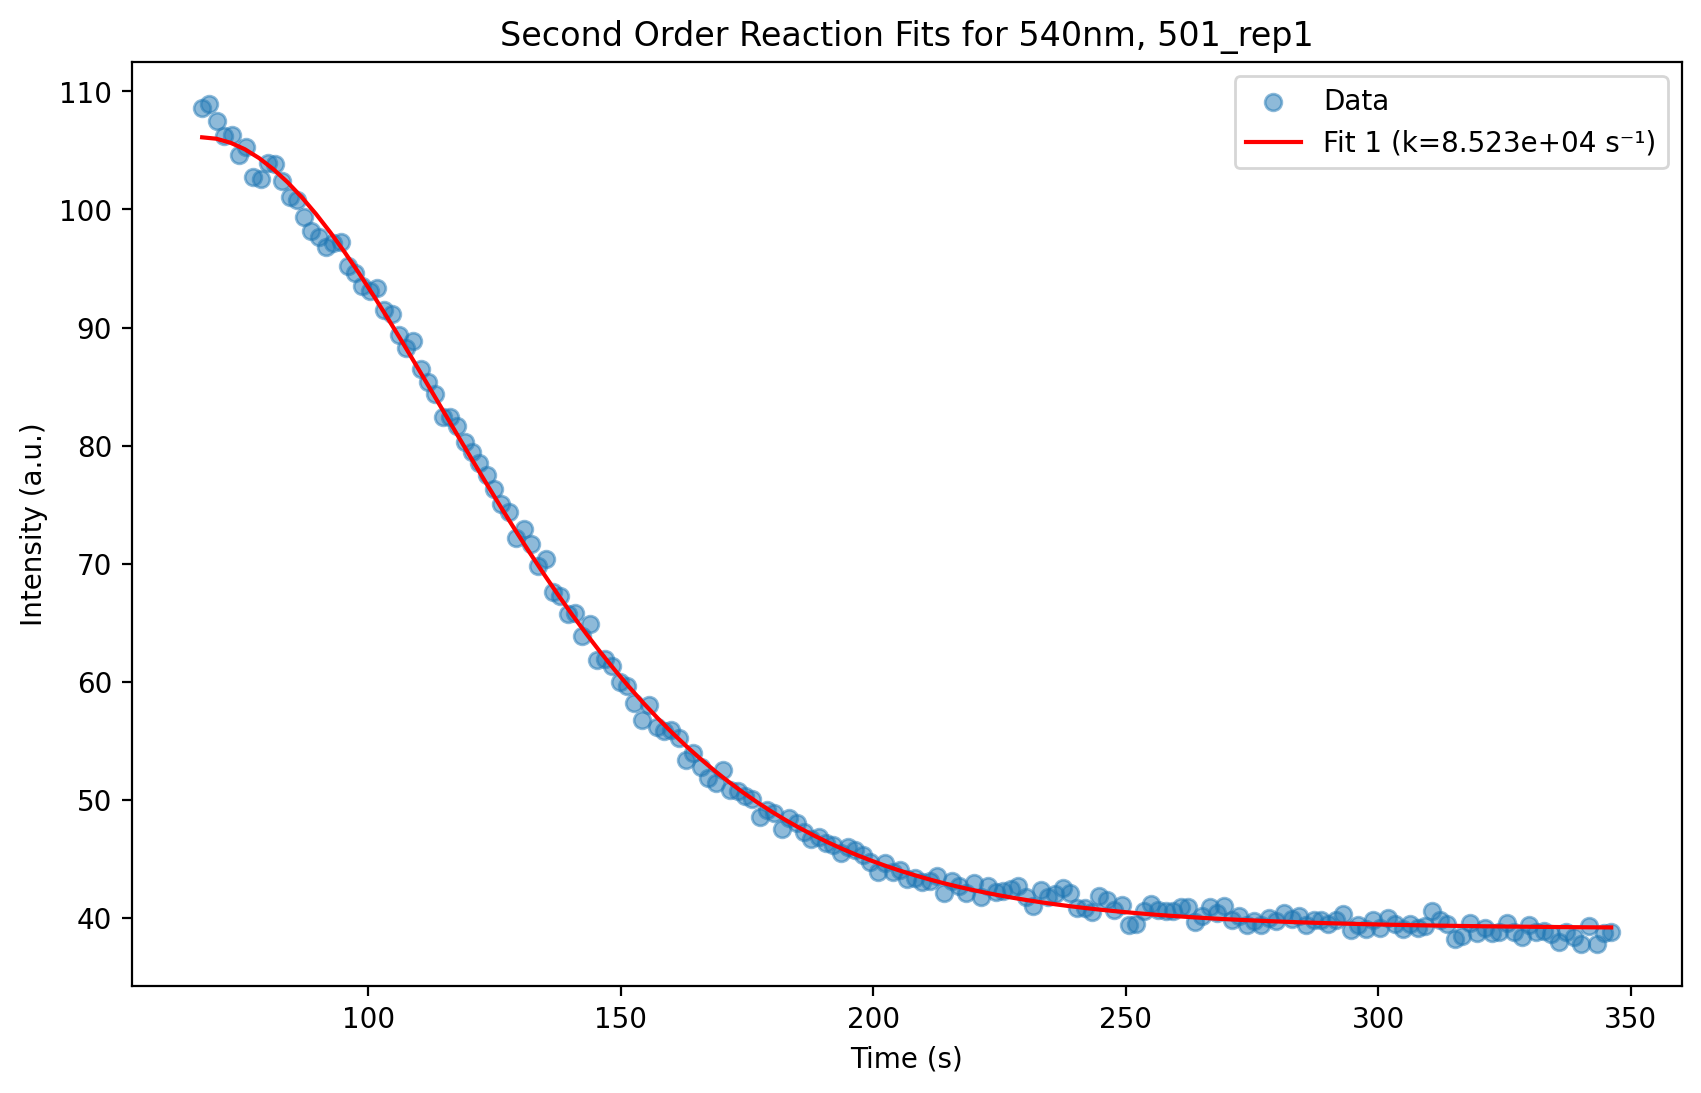

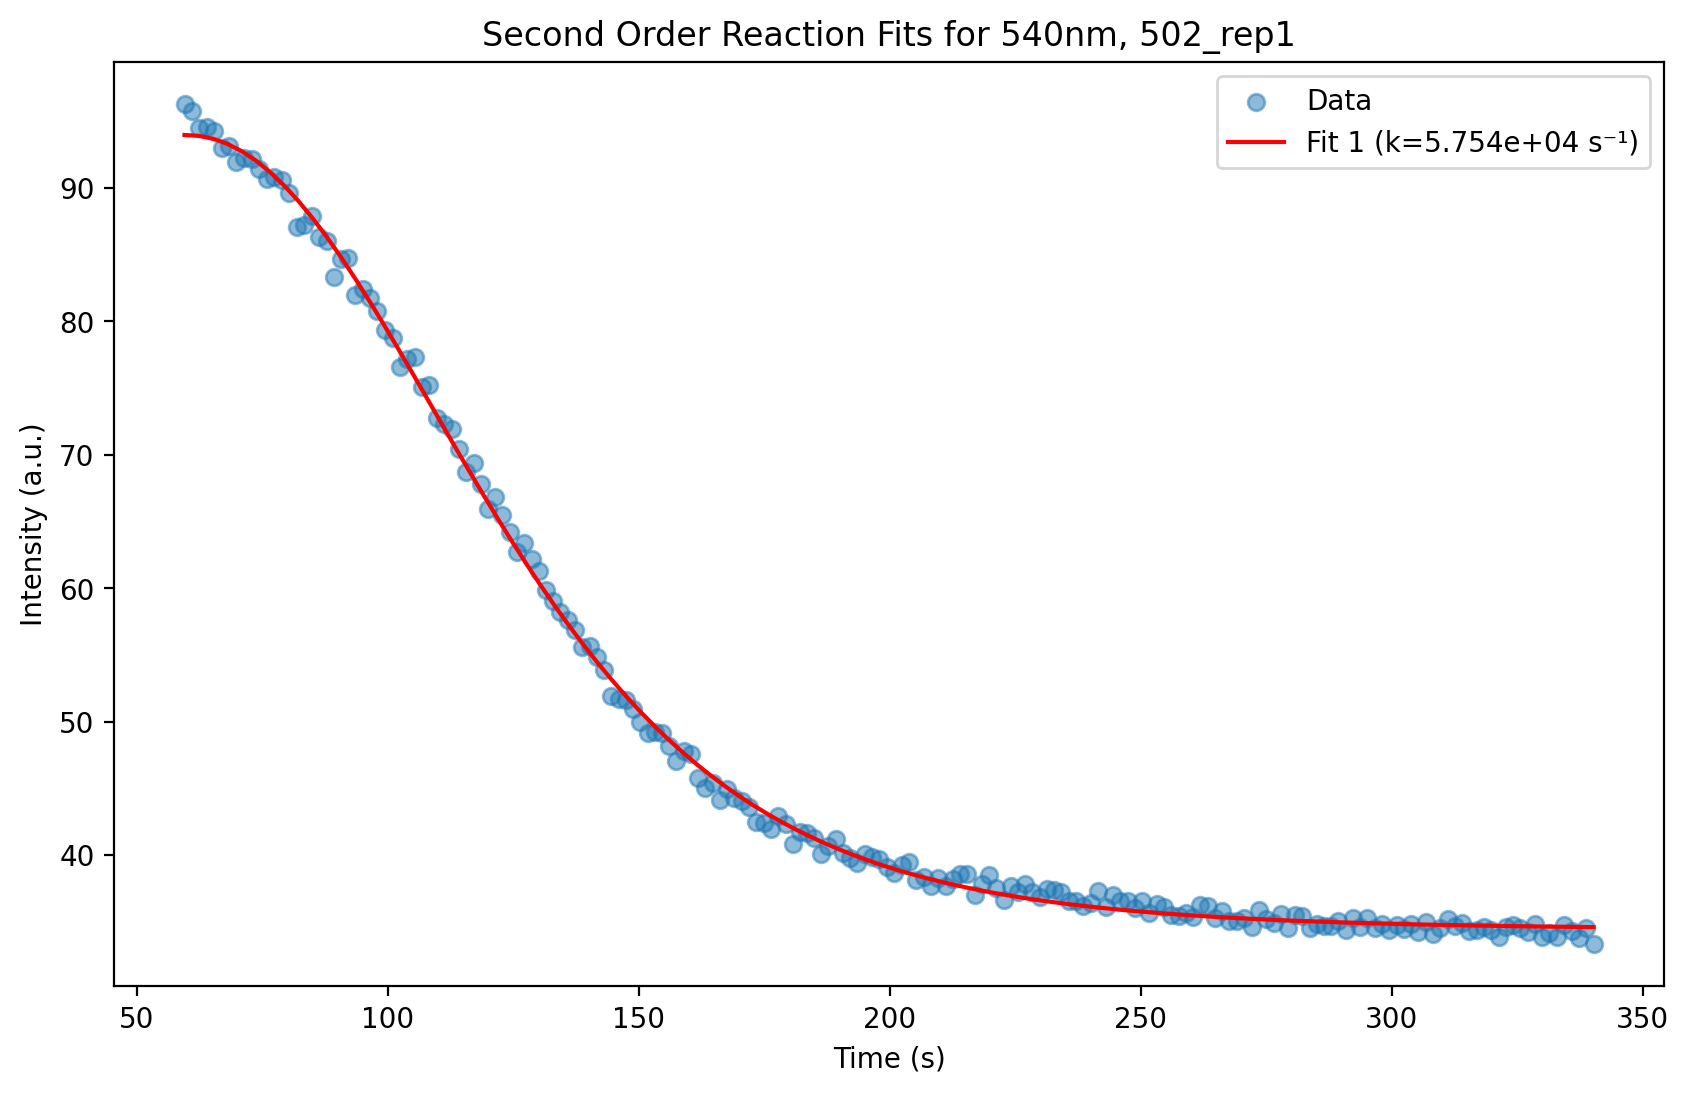

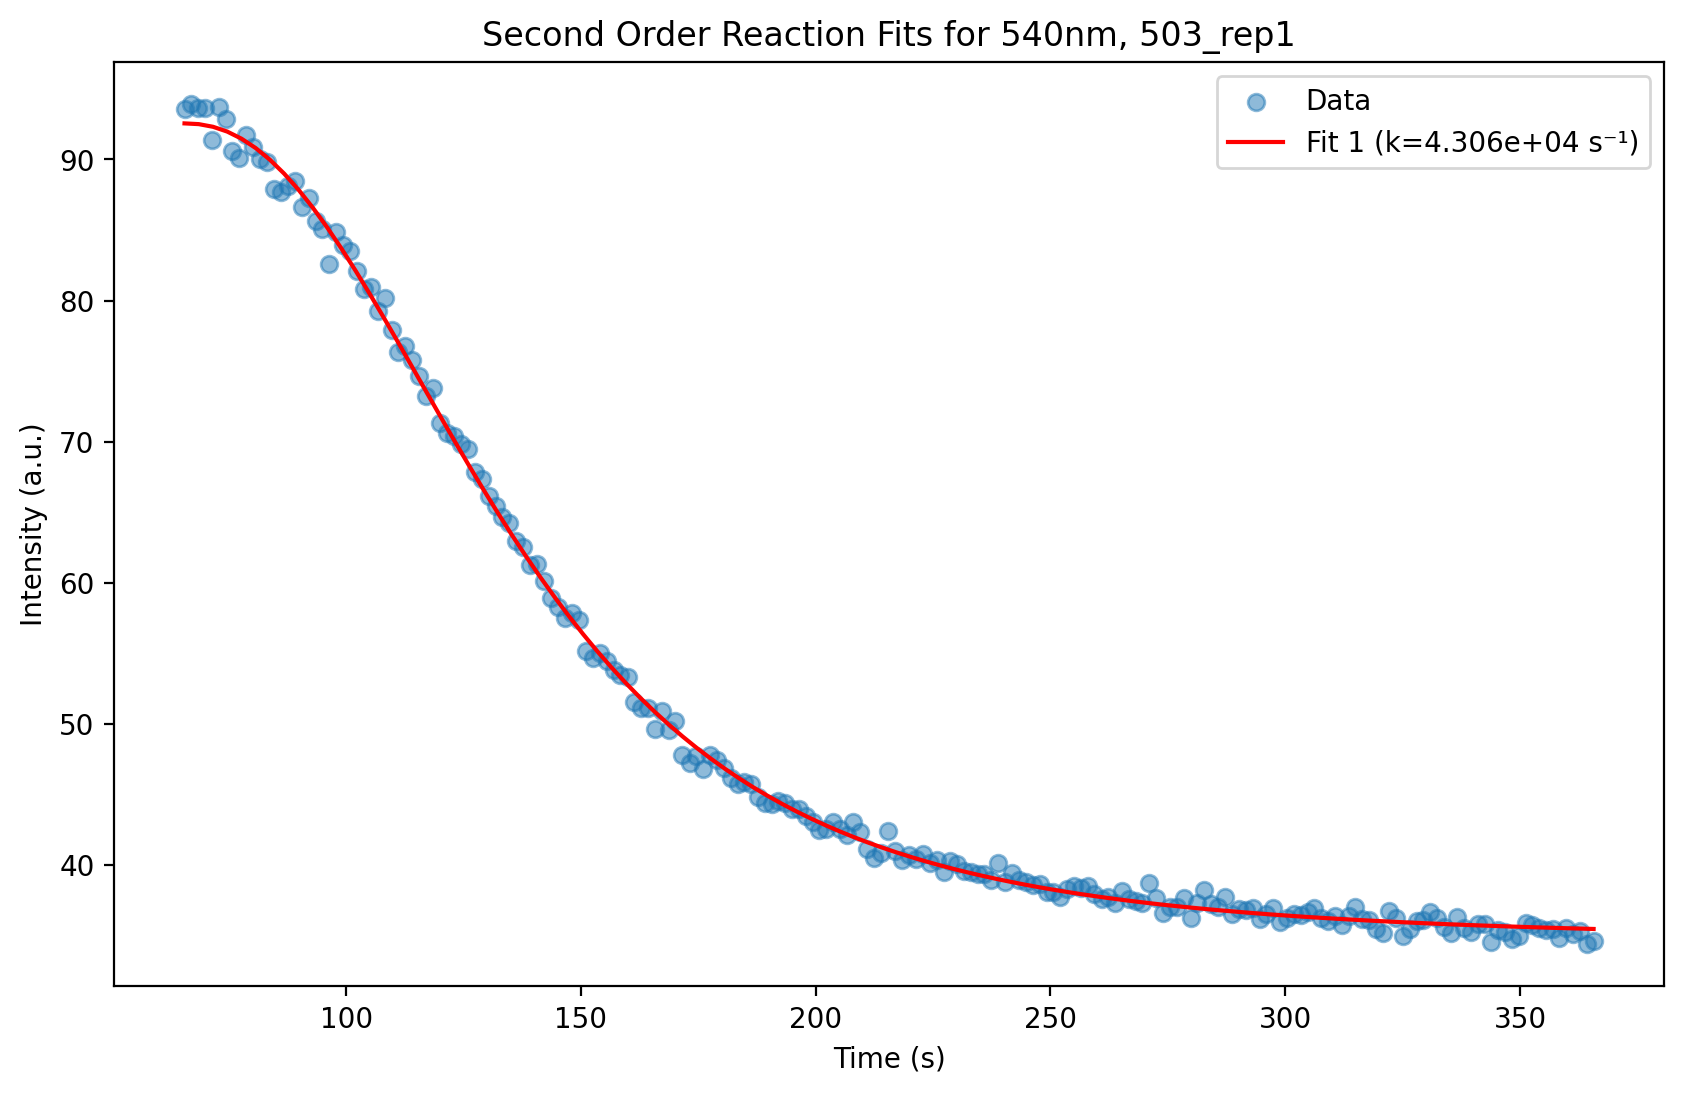

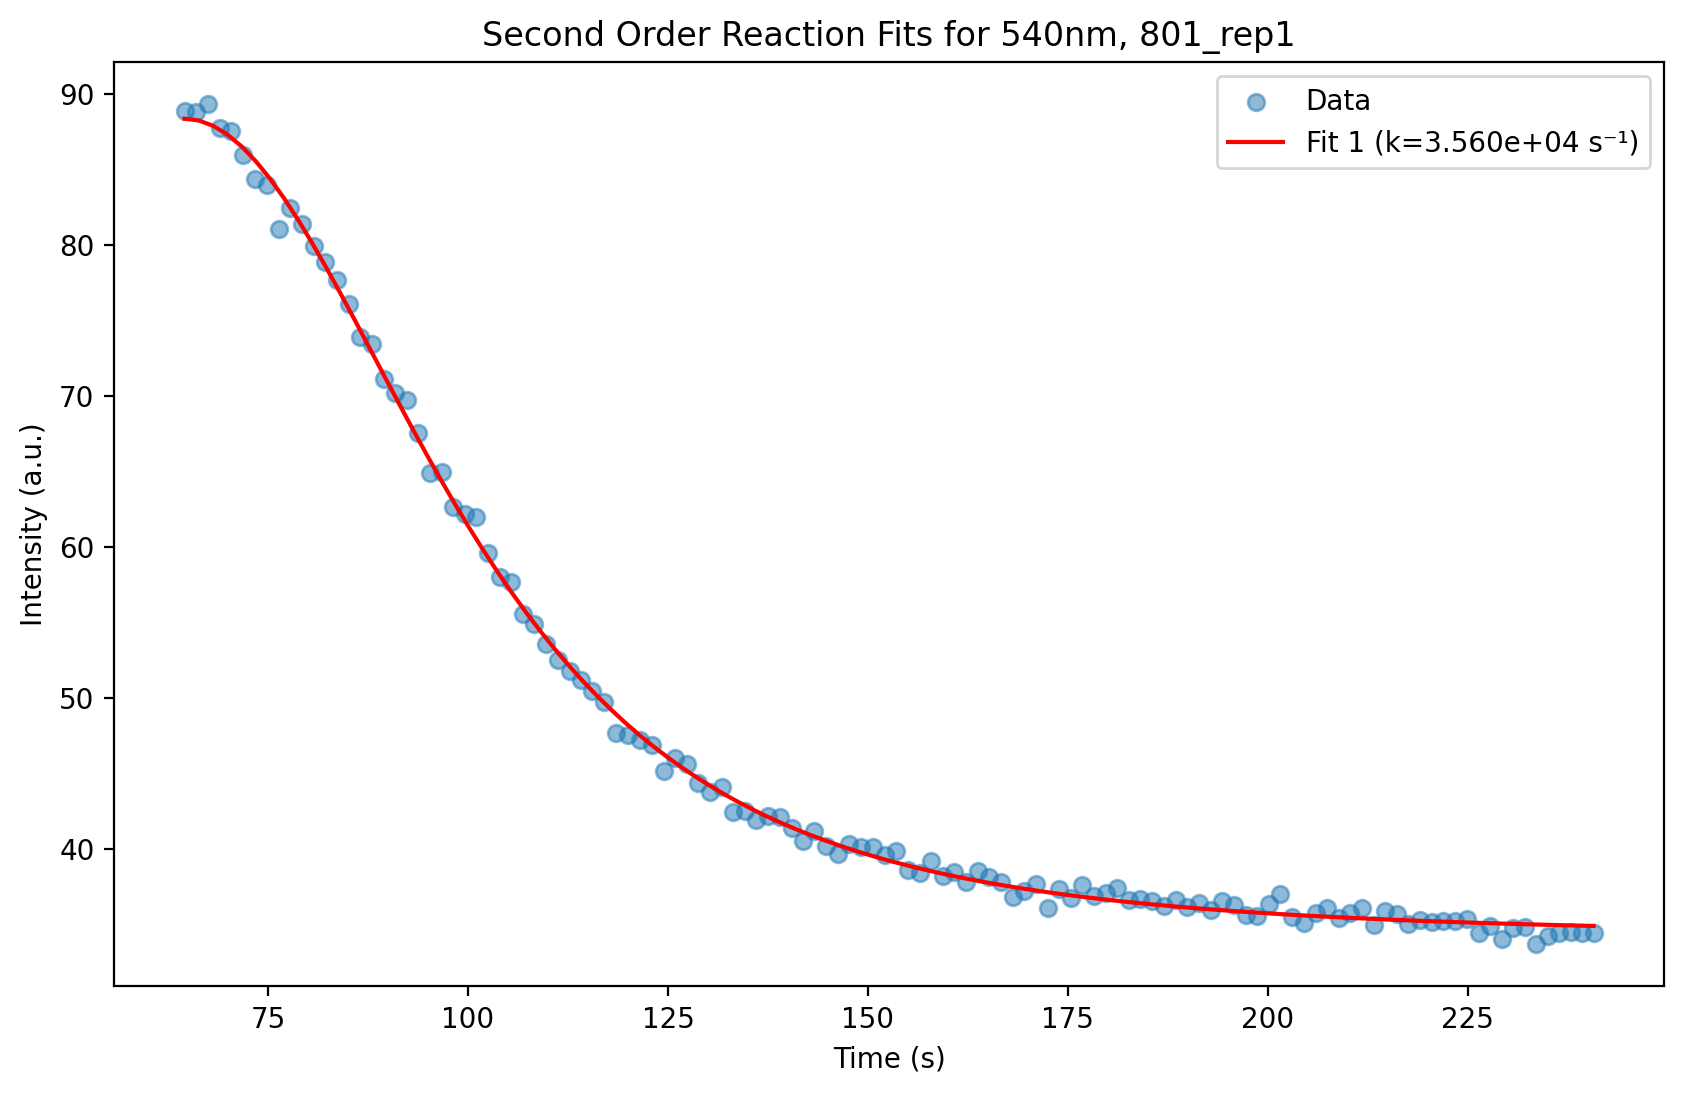

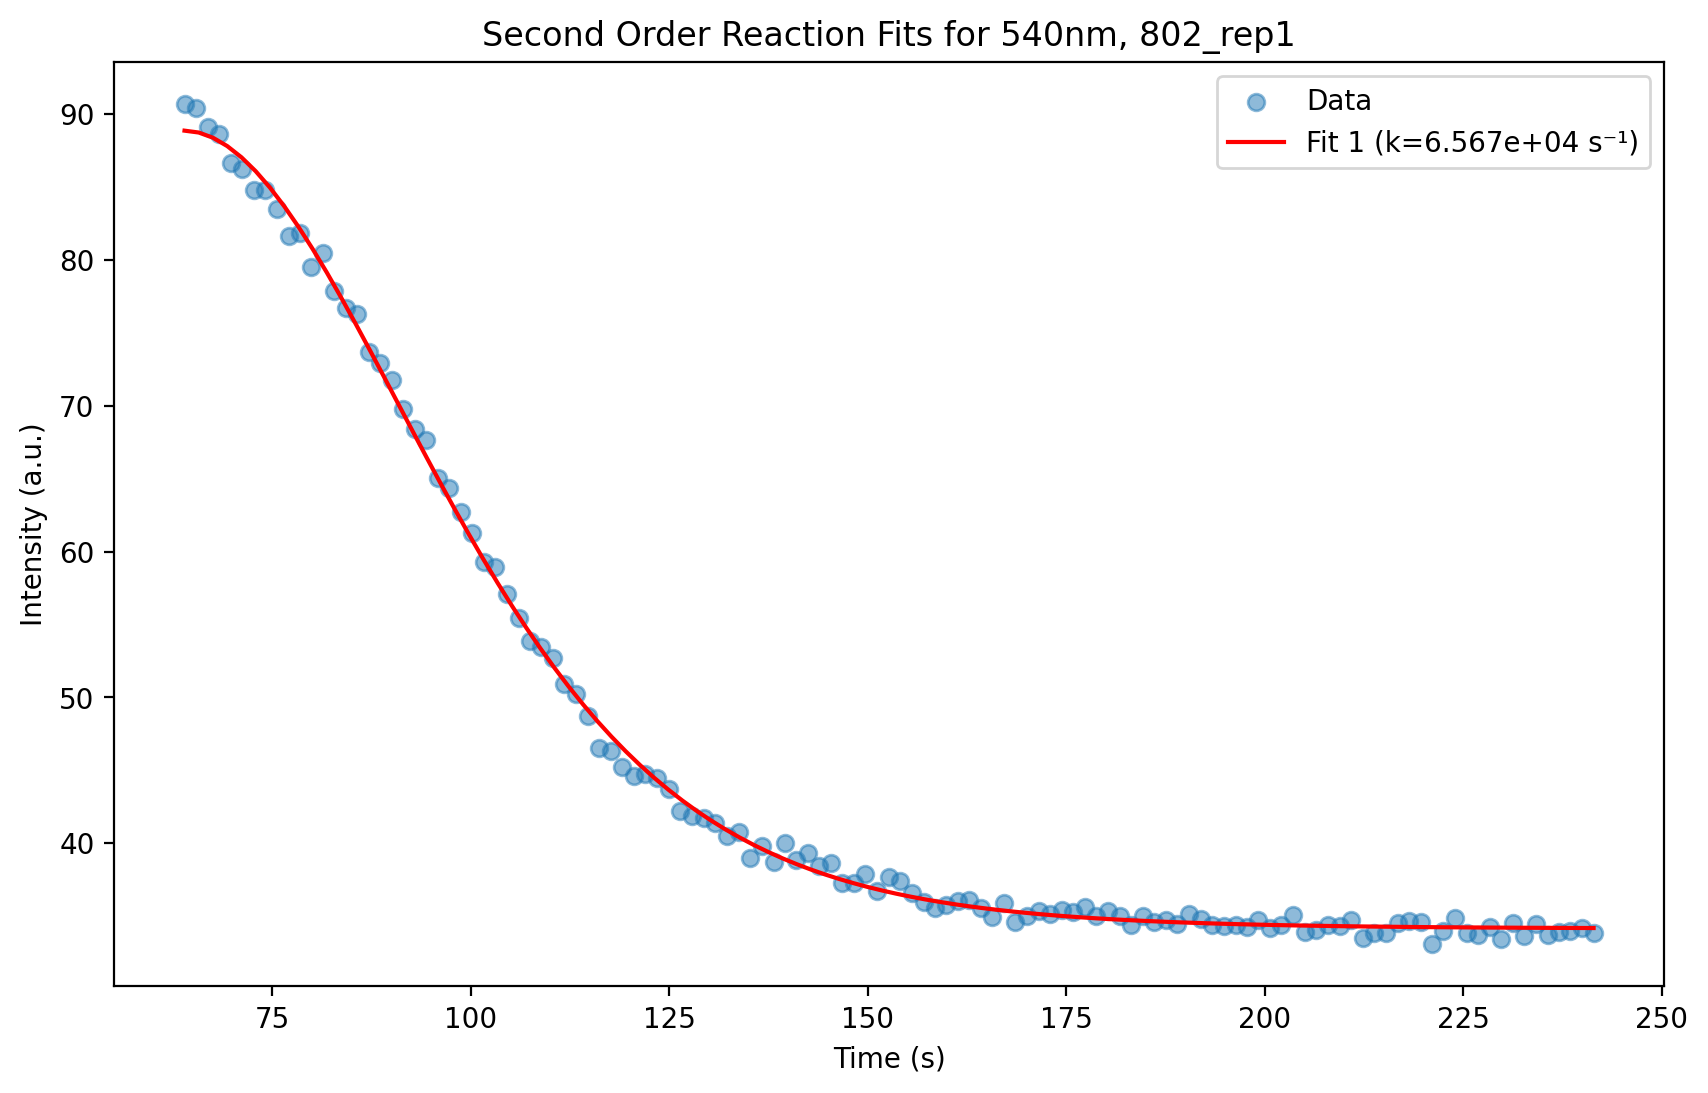

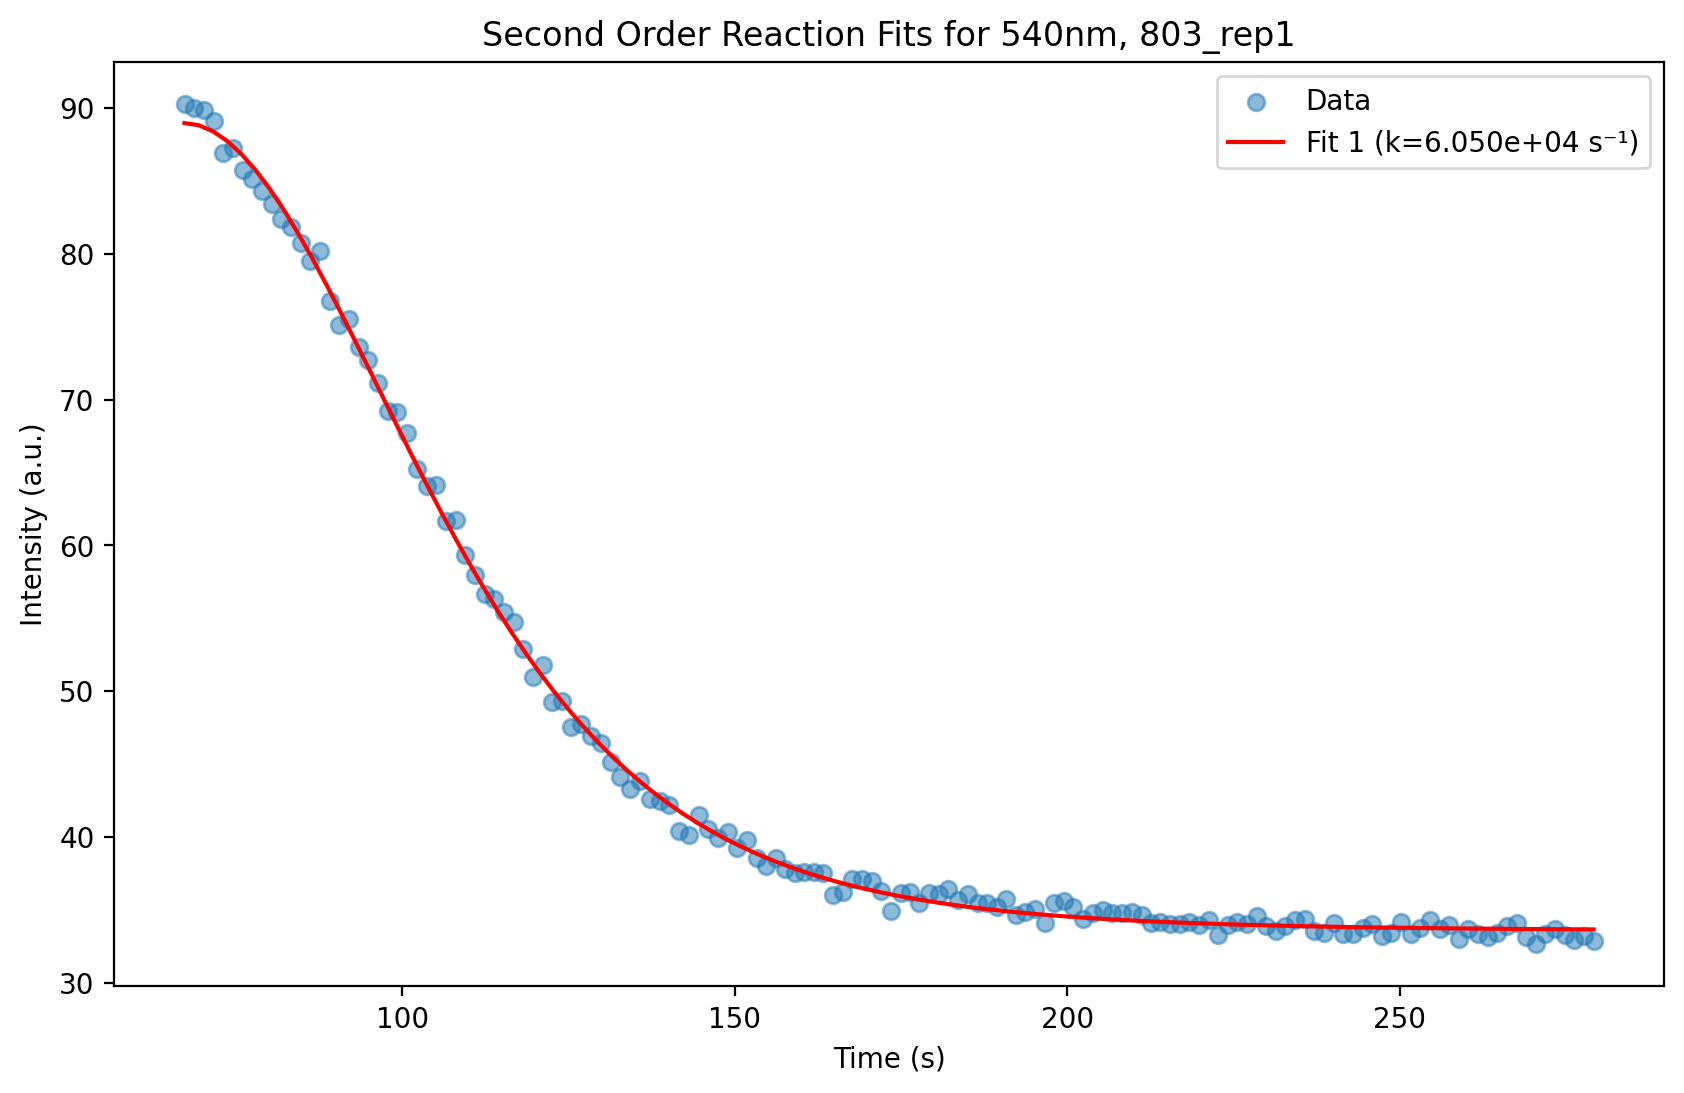

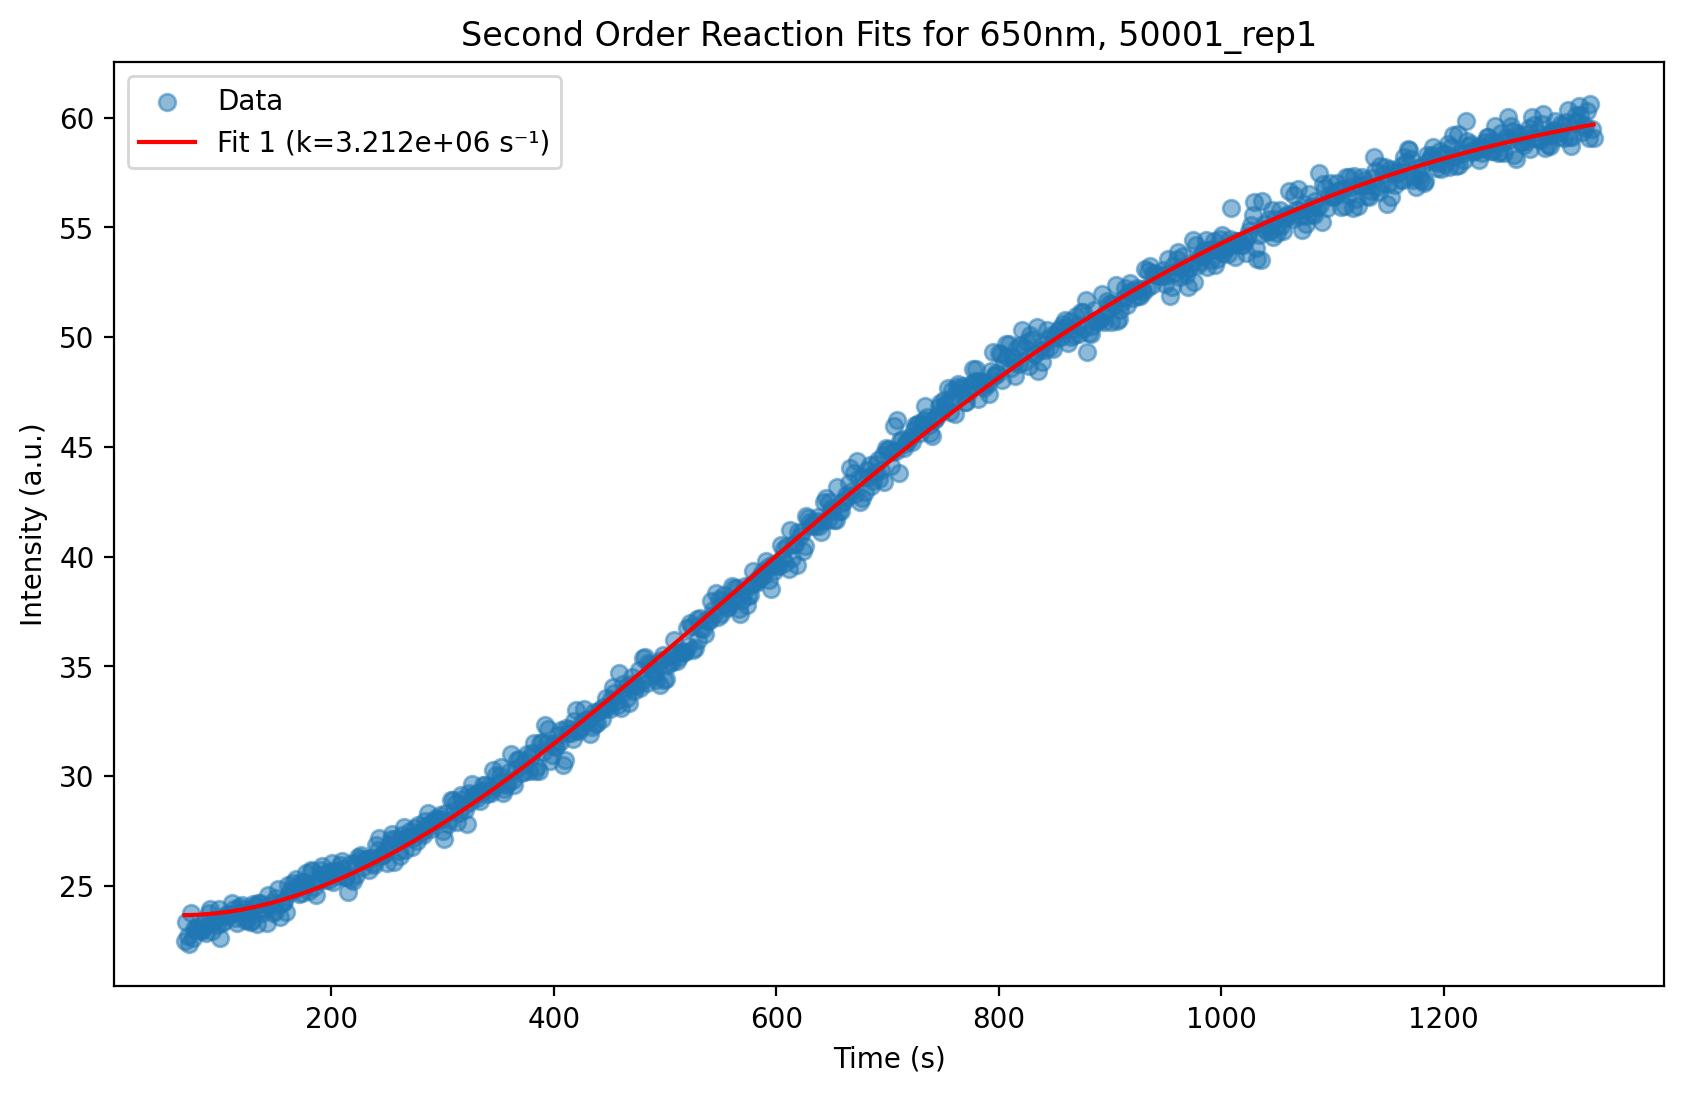

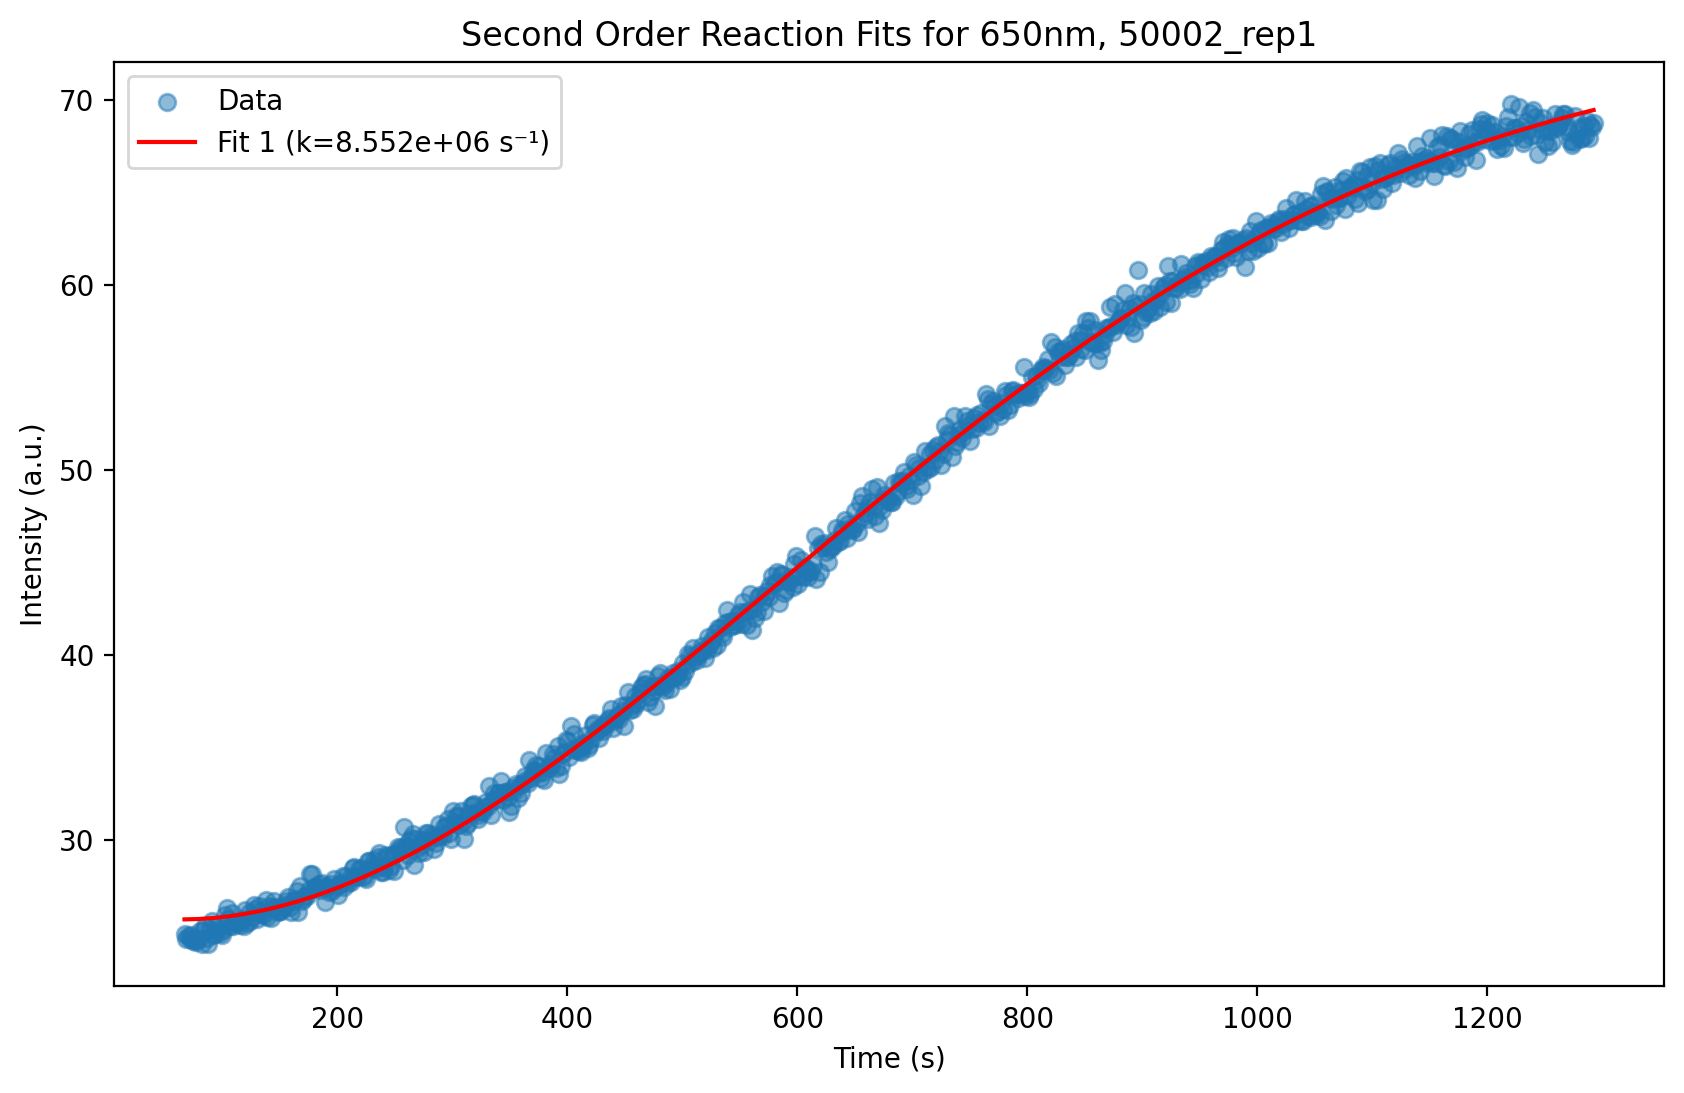

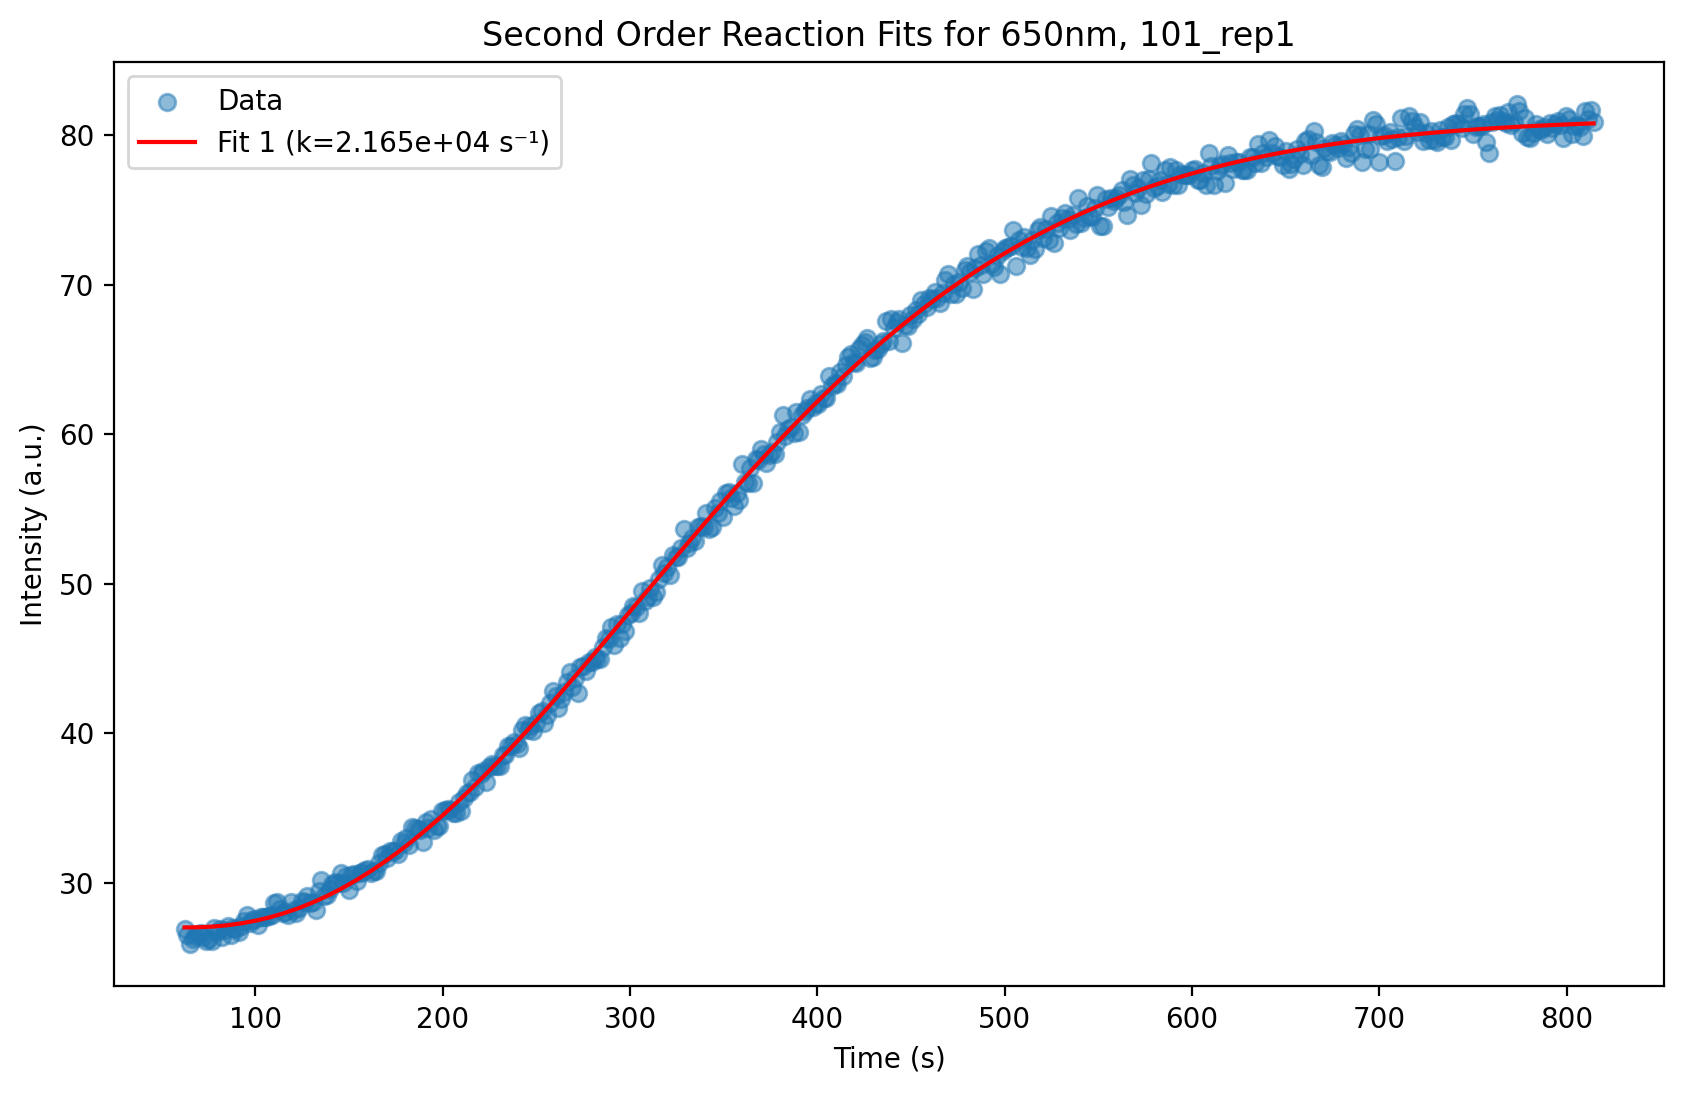

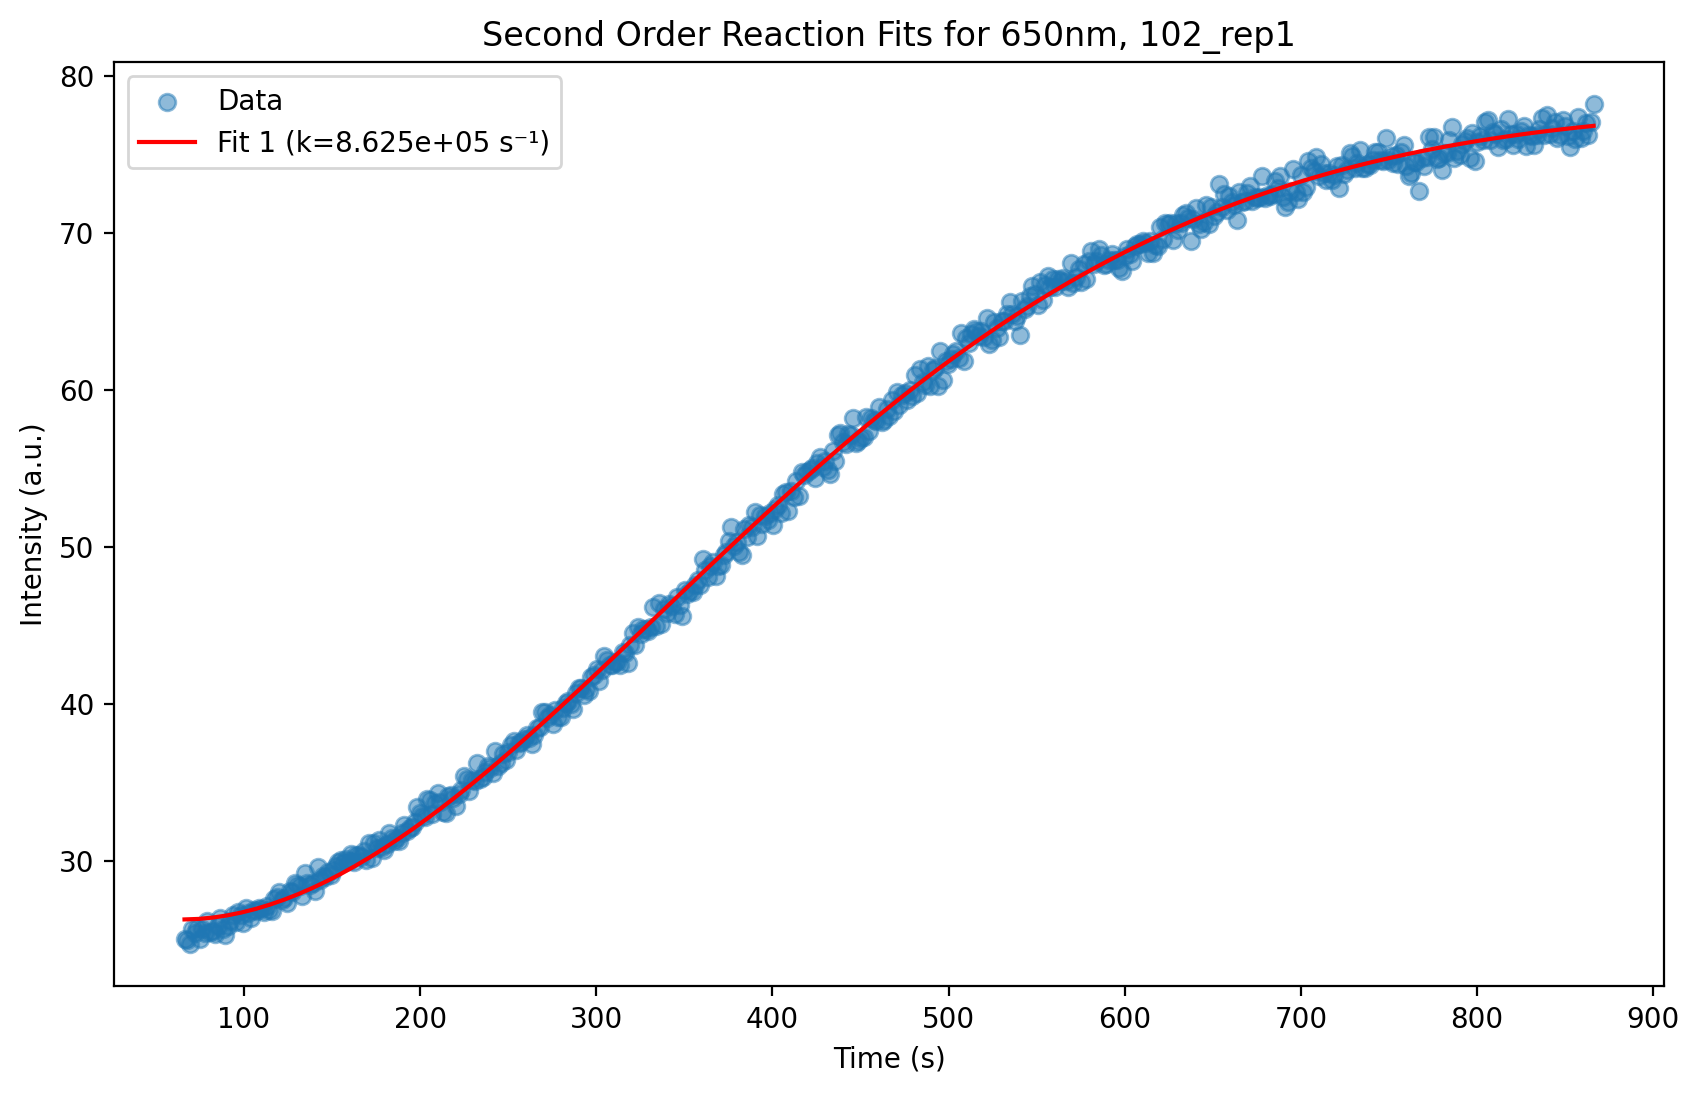

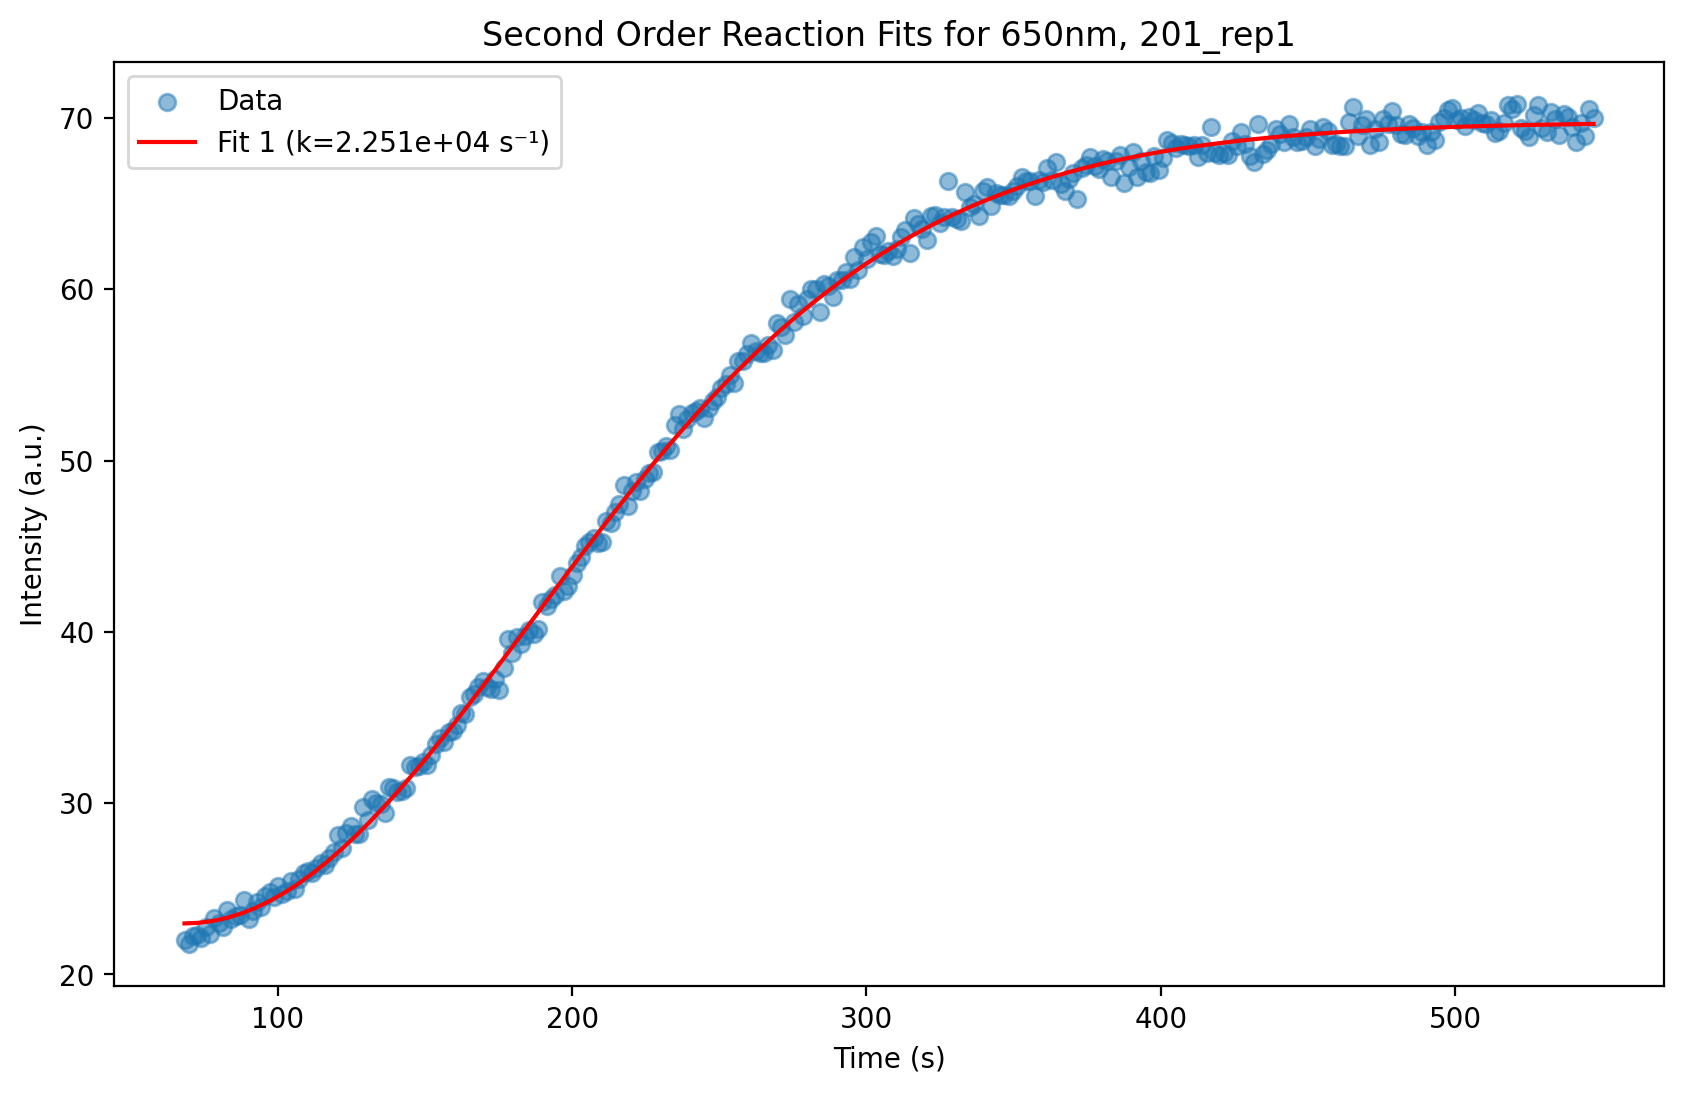

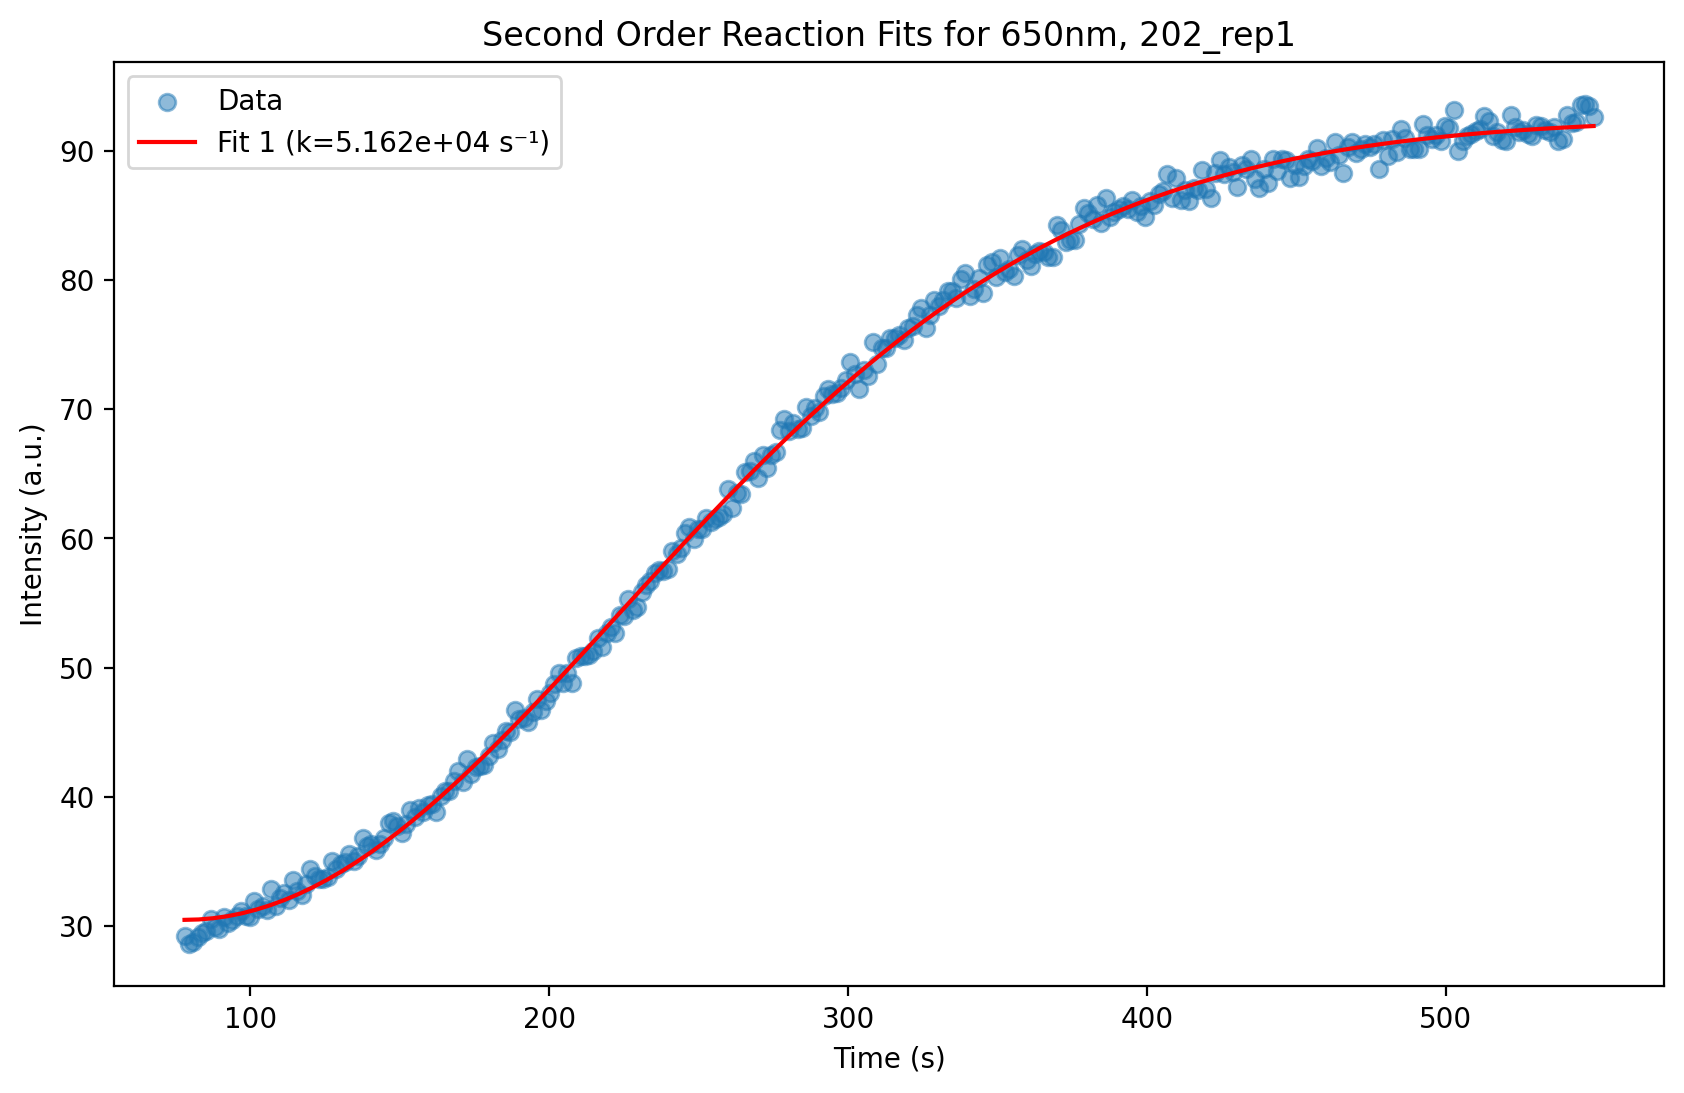

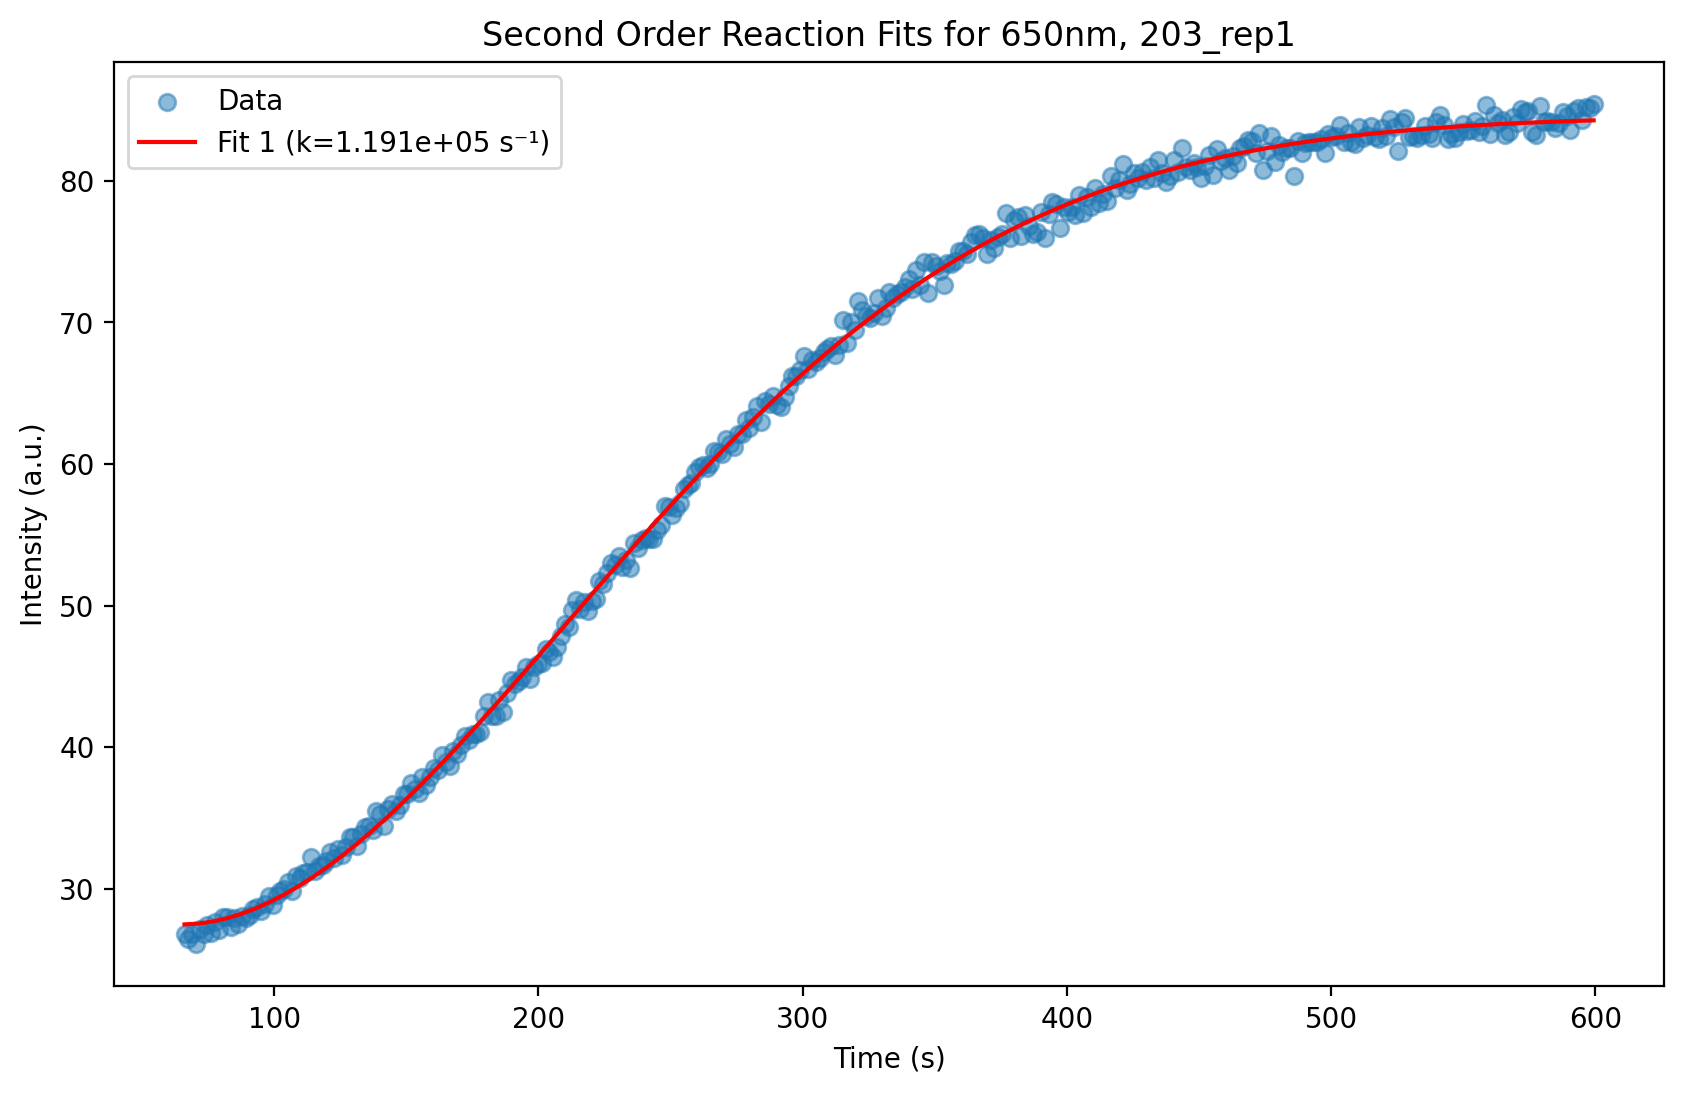

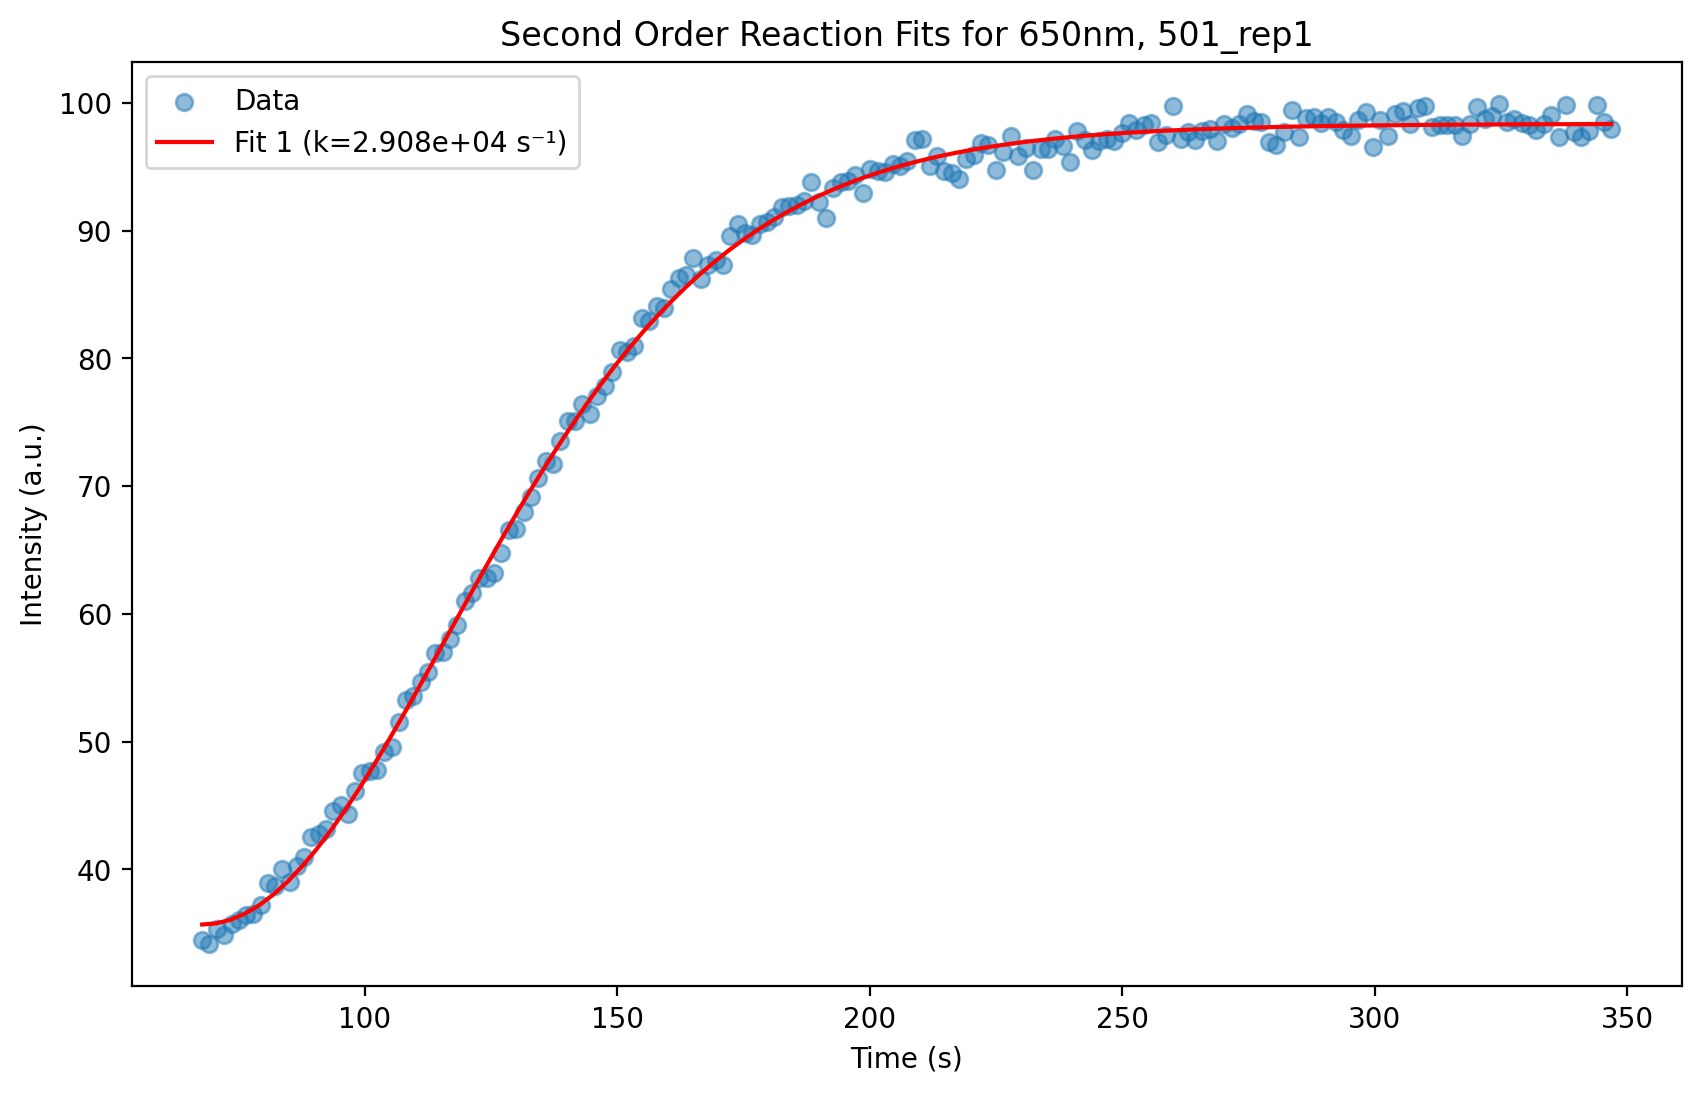

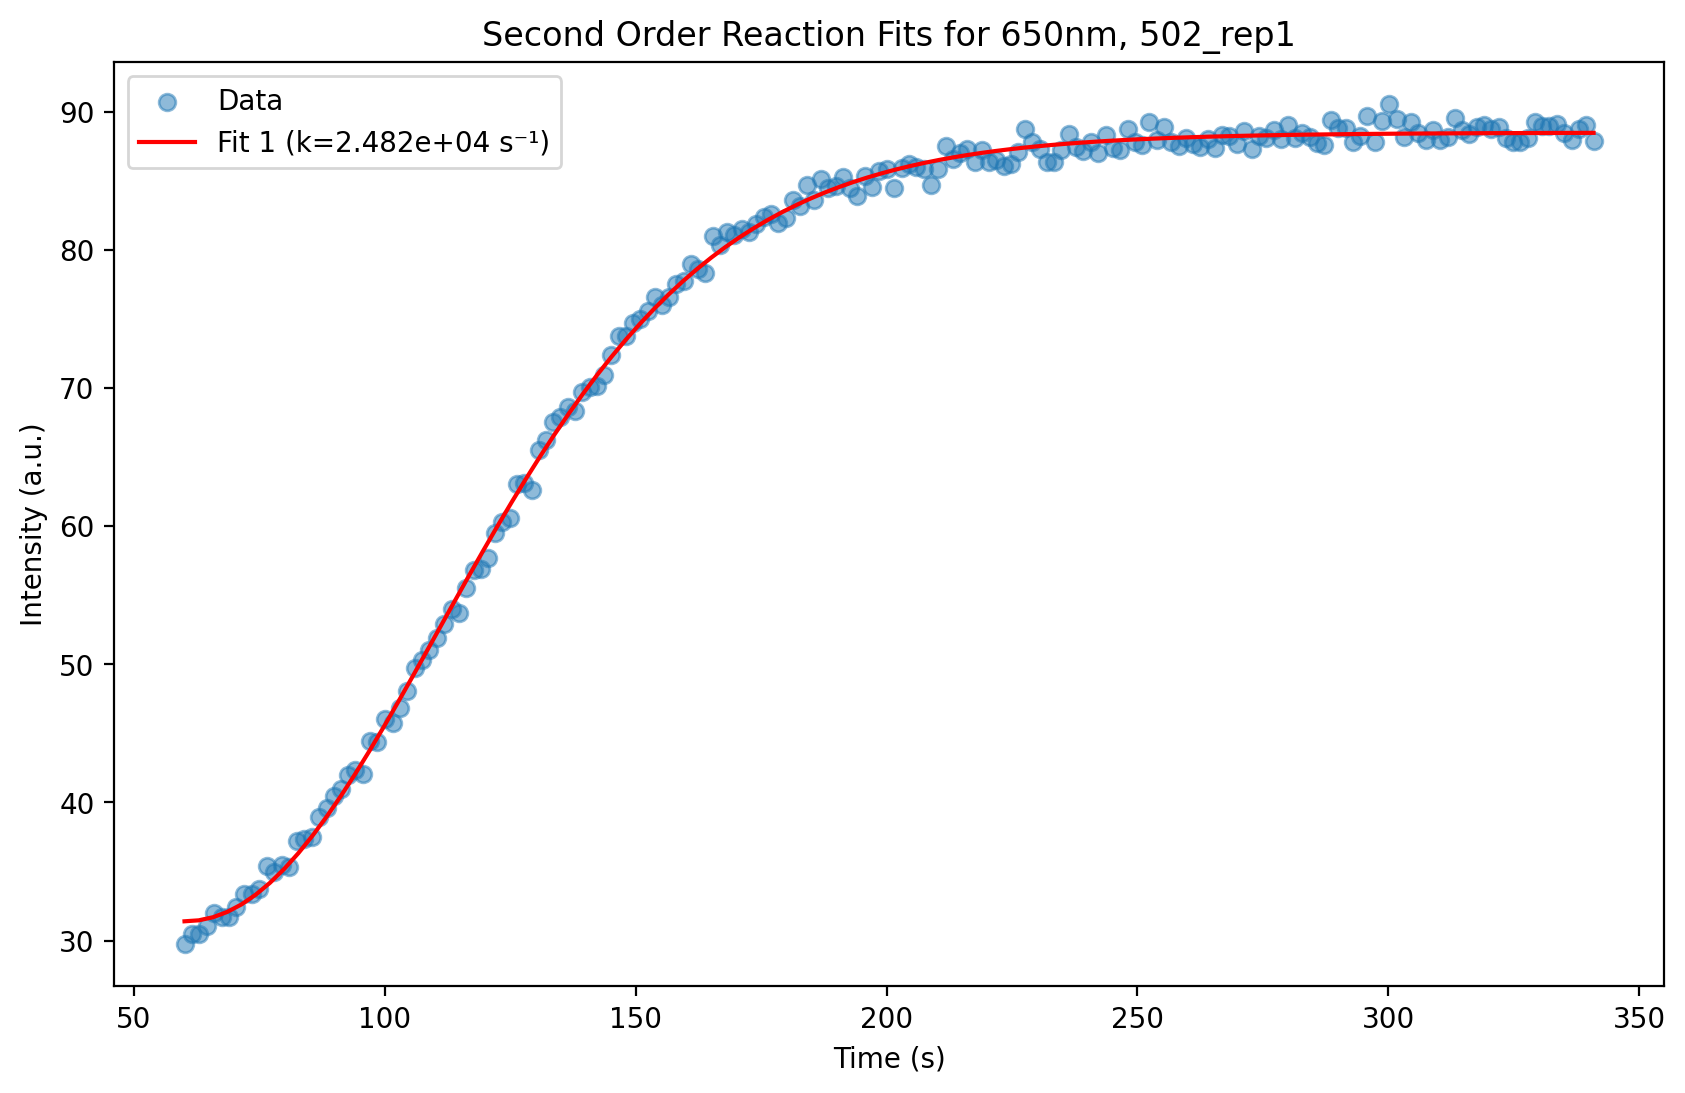

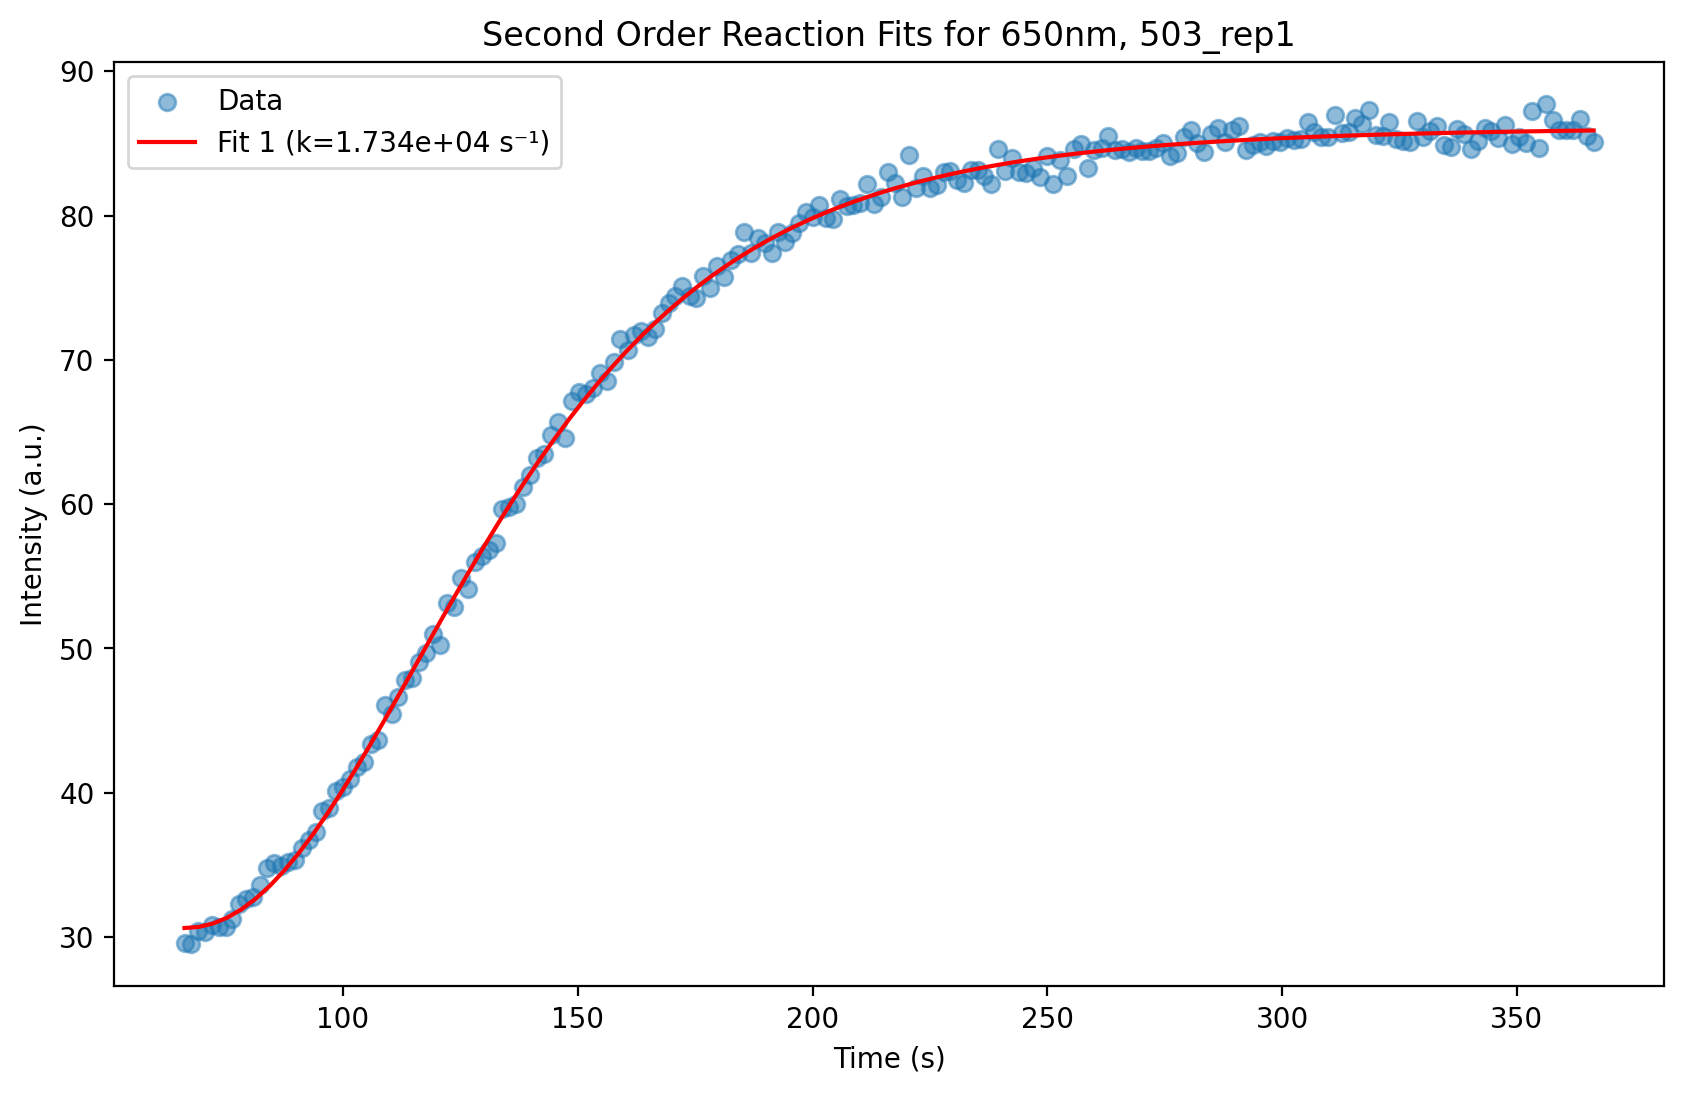

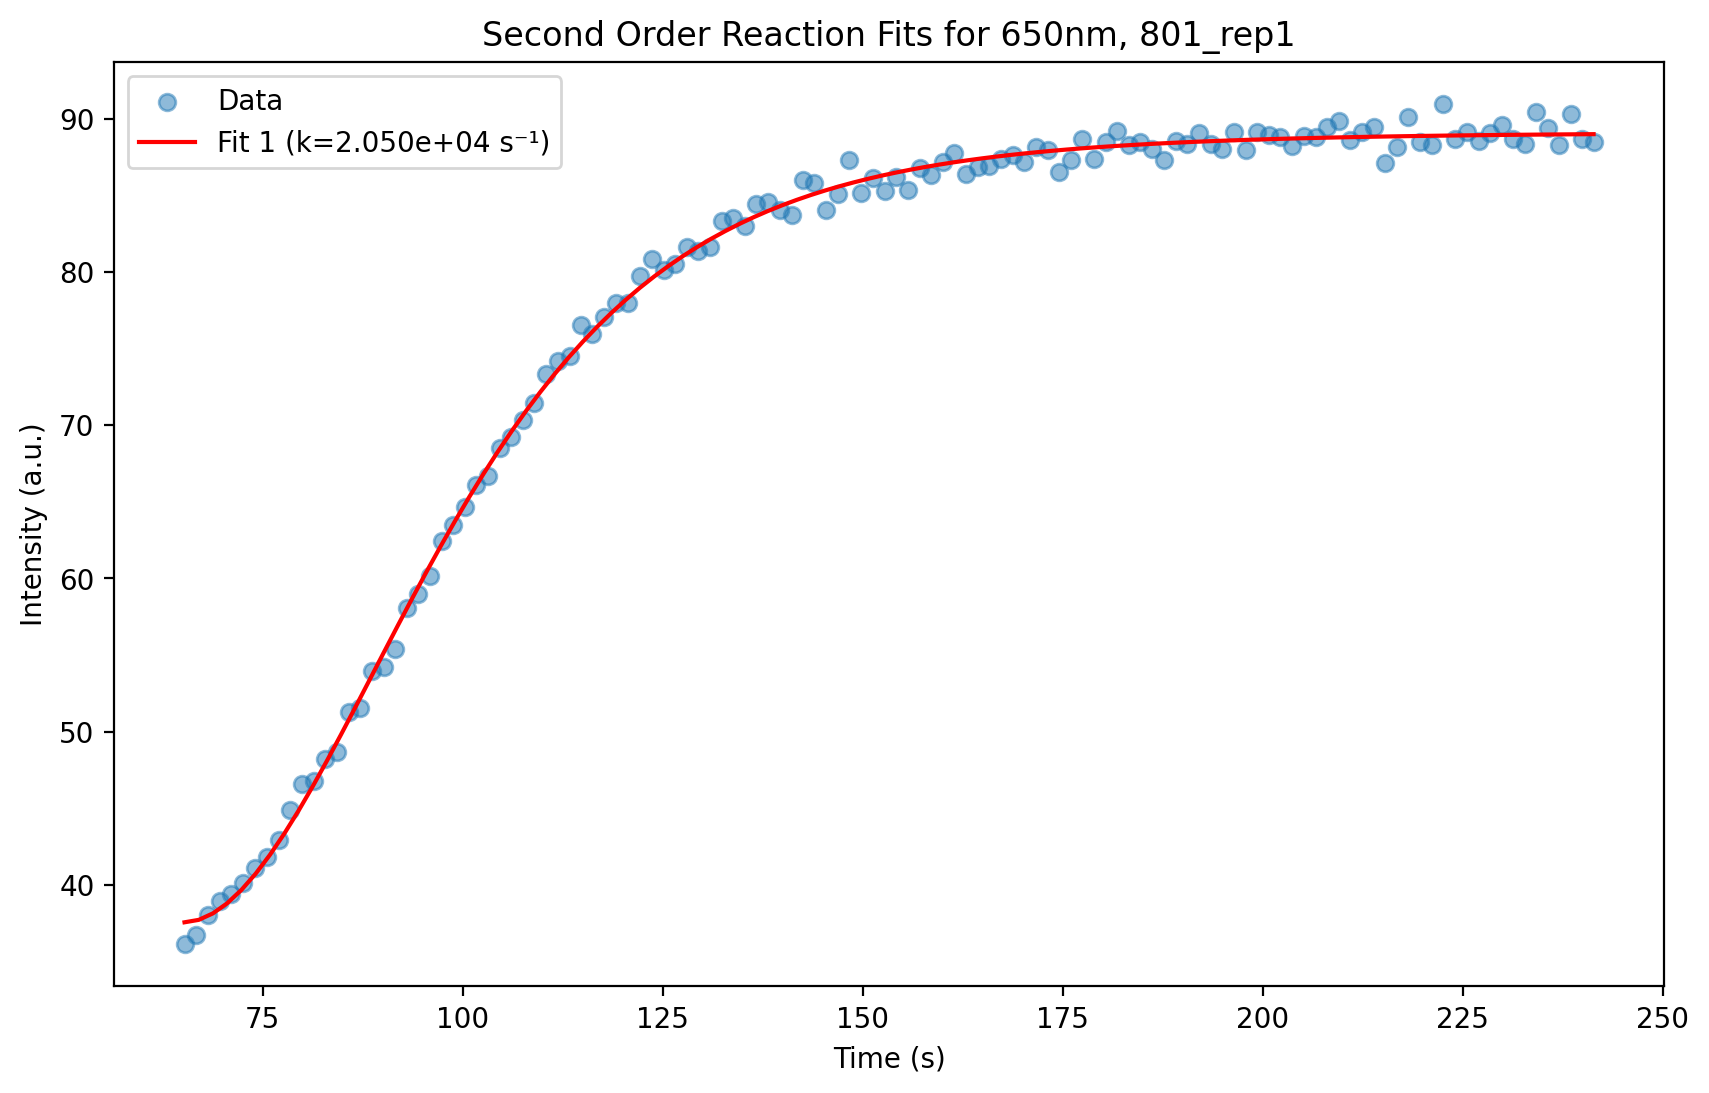

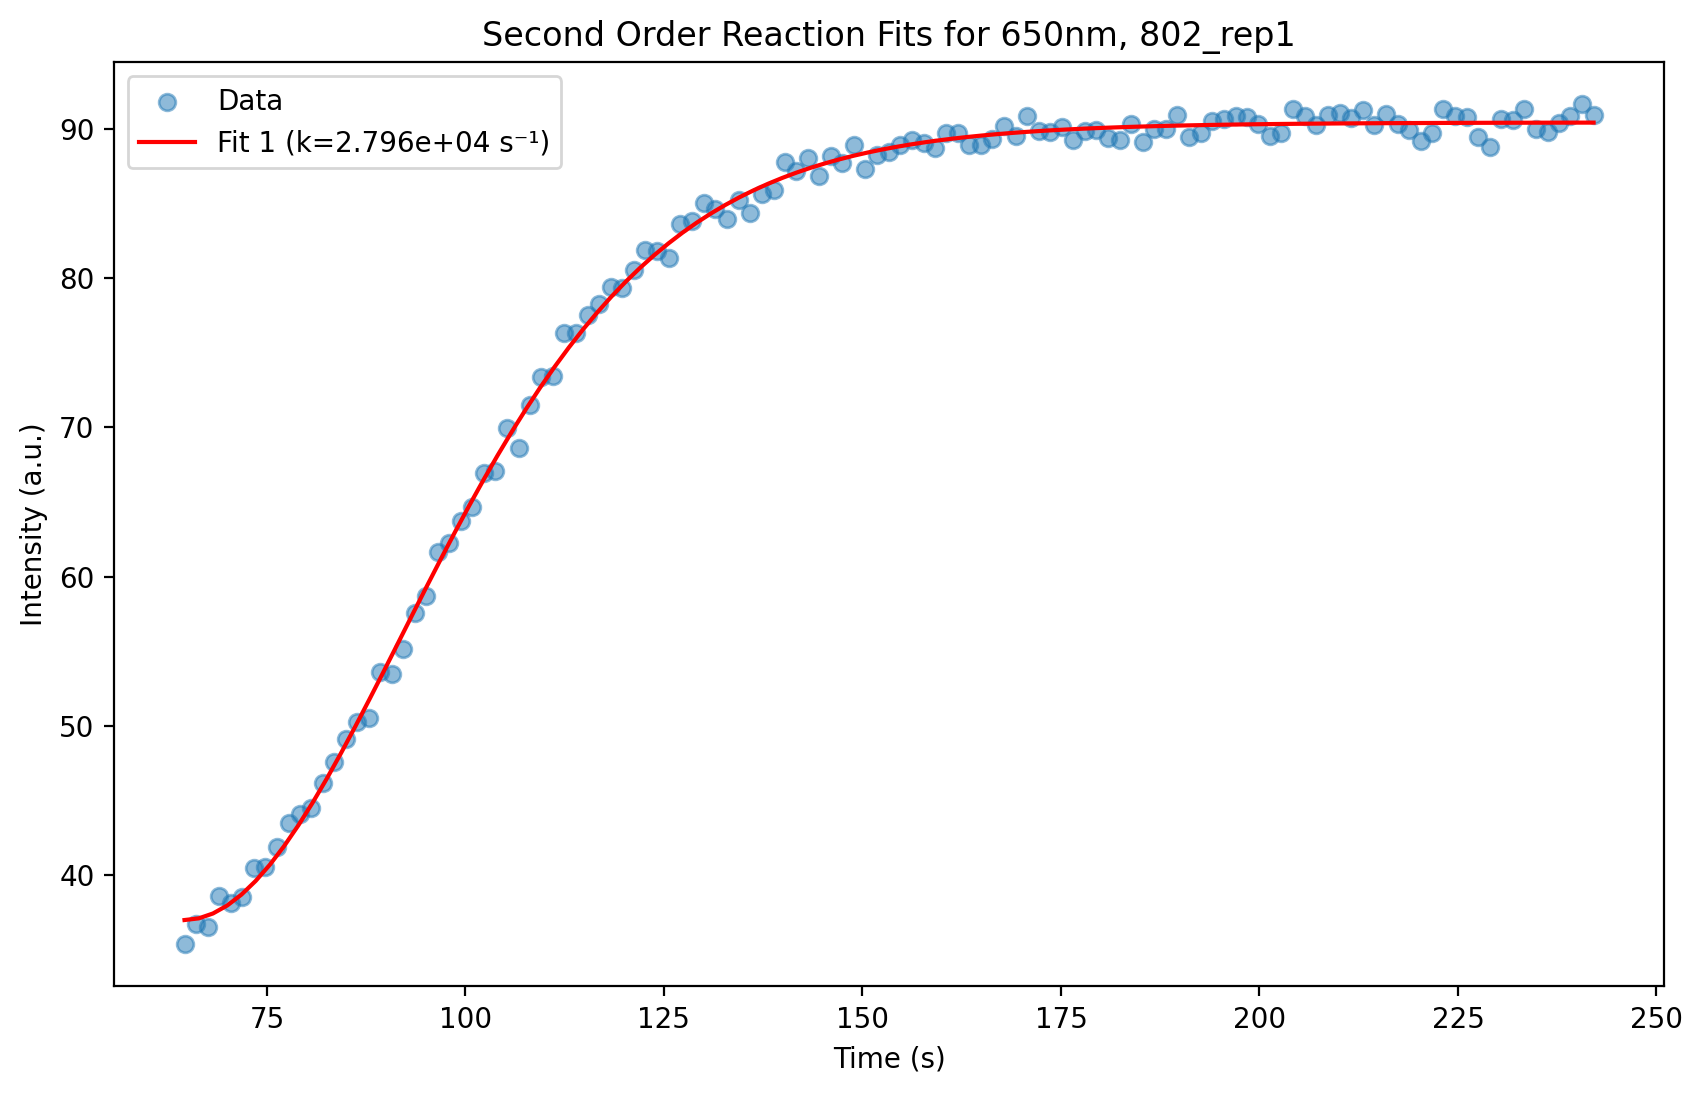

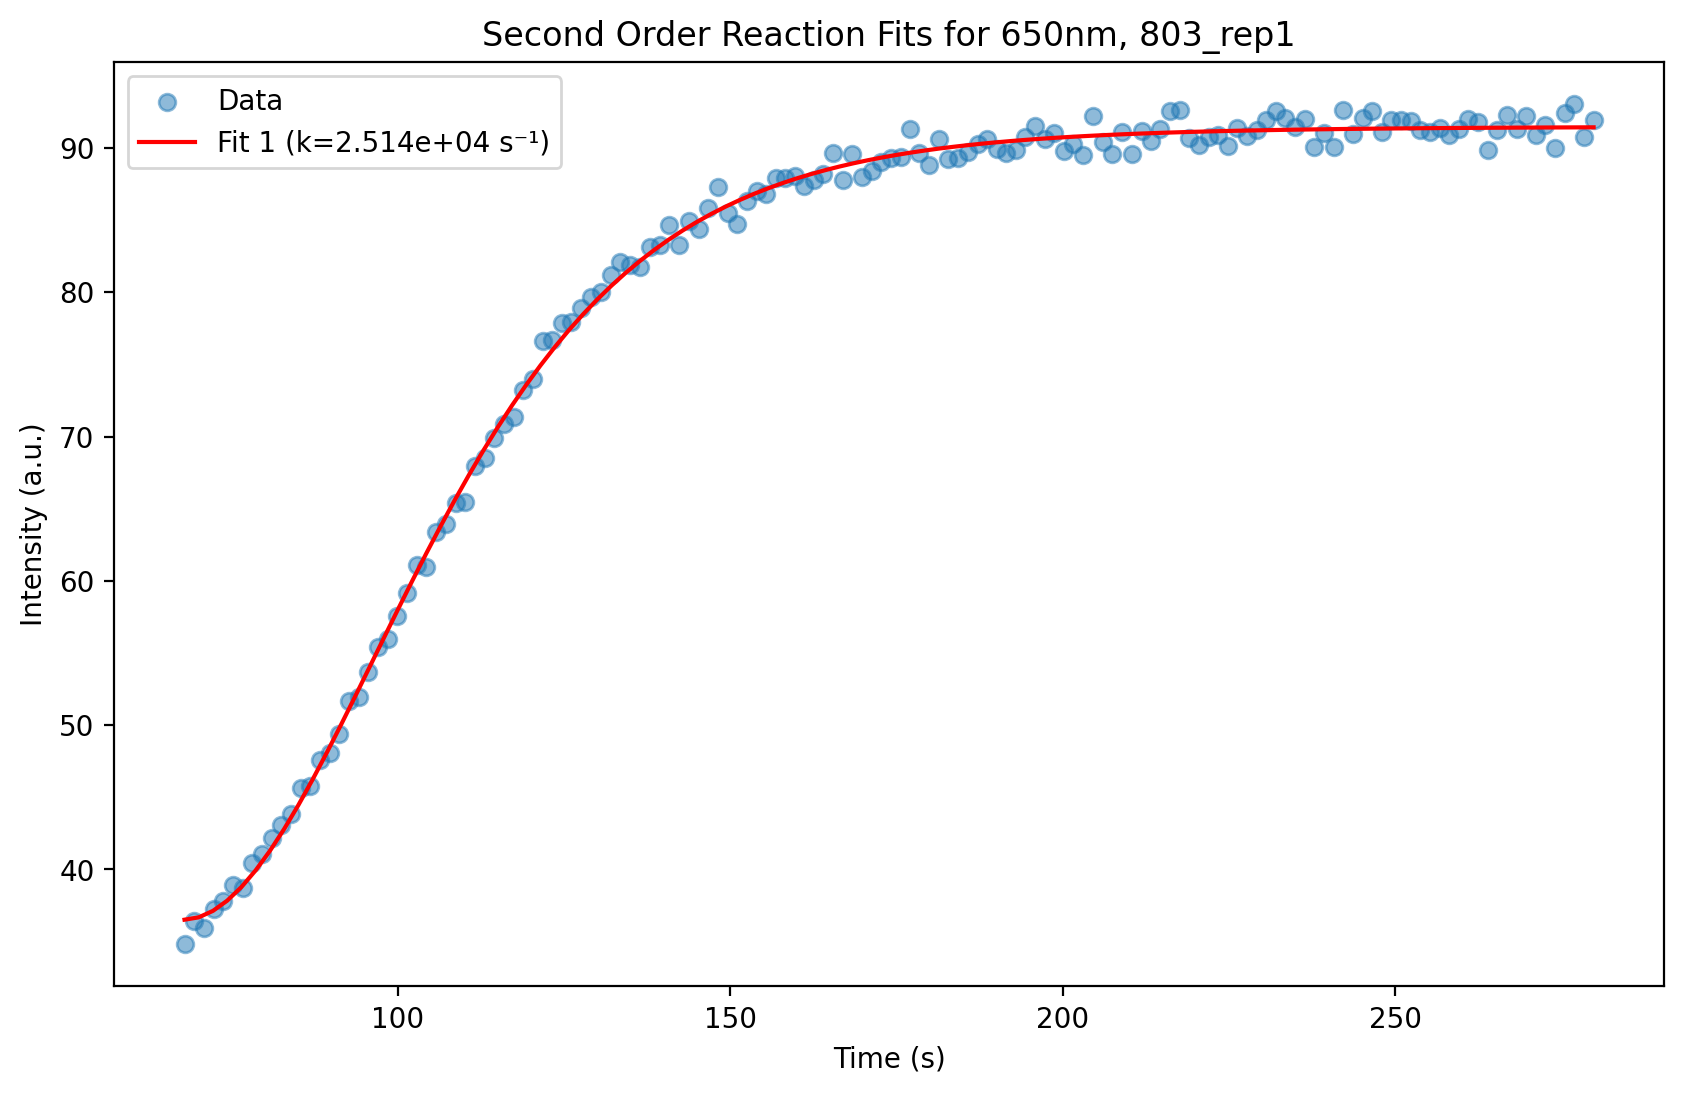

In [18]:
r50001_fit = fit_reaction_segments(r50001, 540, r50001_A0, '50001_rep1') #201... #101... #501... #801...r50001_A0
r50002_fit = fit_reaction_segments(r50002, 540, r50002_A0, '50002_rep1') #201... #101... #501... #801...r50001_A0
r101_fit = fit_reaction_segments(r101, 540, r101_A0, '101_rep1') #201... #101... #501... #801...r50001_A0
r102_fit = fit_reaction_segments(r102, 540, r102_A0, '102_rep1')
r201_fit = fit_reaction_segments(r201, 540, r201_A0, '201_rep1')
r202_fit = fit_reaction_segments(r202, 540, r202_A0, '202_rep1') 
r203_fit = fit_reaction_segments(r203, 540, r203_A0, '203_rep1') 
r501_fit = fit_reaction_segments(r501, 540, r501_A0, '501_rep1') 
r502_fit = fit_reaction_segments(r502, 540, r502_A0, '502_rep1') 
r503_fit = fit_reaction_segments(r503, 540, r503_A0, '503_rep1') 
r801_fit = fit_reaction_segments(r801, 540, r801_A0, '801_rep1') 
r802_fit = fit_reaction_segments(r802, 540, r802_A0, '802_rep1') 
r803_fit = fit_reaction_segments(r803, 540, r803_A0, '803_rep1') 

r50001_650_fit = fit_reaction_segments(r50001, 650, r50001_650, '50001_rep1')
r50002_650_fit = fit_reaction_segments(r50002, 650, r50002_650, '50002_rep1')
r101_650_fit = fit_reaction_segments(r101, 650, r101_650, '101_rep1')
r102_650_fit = fit_reaction_segments(r102, 650, r102_650, '102_rep1')
r201_650_fit = fit_reaction_segments(r201, 650, r201_650, '201_rep1')
r202_650_fit = fit_reaction_segments(r202, 650, r202_650, '202_rep1')
r203_650_fit = fit_reaction_segments(r203, 650, r203_650, '203_rep1')
r501_650_fit = fit_reaction_segments(r501, 650, r501_650, '501_rep1')
r502_650_fit = fit_reaction_segments(r502, 650, r502_650, '502_rep1')
r503_650_fit = fit_reaction_segments(r503, 650, r503_650, '503_rep1')
r801_650_fit = fit_reaction_segments(r801, 650, r801_650, '801_rep1')
r802_650_fit = fit_reaction_segments(r802, 650, r802_650, '802_rep1')
r803_650_fit = fit_reaction_segments(r803, 650, r803_650, '803_rep1')

----

# Part 3: Extracting the rate constants from stored text files

In [ ]:
# create also a dictionary to store filenames
data_folder = data_pth
data_list = []

# Loop through all matching Excel files
for file in data_folder.glob("KINETICS-titration-b35-*.xlsx"):
    df = pd.read_excel(file)
    df = df.drop(df.index[0])    # Drop that first row
    df = df.reset_index(drop=True)
    # Add the filename stem (e.g., "KINETICS-titration-b35-01") as an identifier
    df["source_file"] = file.stem
    data_list.append(df)

# Combine all into one big DataFrame
combined_df = pd.concat(data_list, ignore_index=True)

#update sample1_ex450_em540 to time_540
combined_df.rename(columns={'Sample1_Ex450_Em540': 'Time (s)_540', 'Sample1_Ex450_Em620': 'Time (s)_650'}, inplace=True)
#rename also Unnamed :1 to Intensity (a.u.)_540 and Intensity (a.u.)_650
combined_df.rename(columns={'Unnamed: 1': 'Intensity (a.u.)_540', 'Unnamed: 3': 'Intensity (a.u.)_650'}, inplace=True)

# for each file where 01 is the last number in the excel name add '1' to a column called 'concentration' ; if 02 add 0.5 ; if 03 add 0.5 ;...
#r1um_01, r500nm_stopped, r500nm_01, r500nm_02, r2um_01, r2um_02, r5um_01, r5um_02, r5um_03, r2um_03, r1um_02, r8um_01, r8um_02, r8um_03, r500nm_03 = data_dict.values()
# Extract the file number (e.g. '01', '02', ...) and convert to integer
combined_df["file_num"] = combined_df["source_file"].str.extract(r"(\d+)$").astype(int)
# Map the file number to the corresponding concentration
conc_map = {
    1: 1.0, 2: 0.5,
    3: 0.5, 4: 0.5,
    5: 2.0, 6: 2.0,
    7: 5.0, 8: 5.0,
    9: 5.0, 10: 2.0,
    11: 1.0, 12: 8.0,
    13: 8.0, 14: 8.0,
    15: 0.5
}

# and do the same for replicate
rep_map = {
    1: 1, 2: 0,
    3: 1, 4: 2,
    5: 1, 6: 2,
    7: 1, 8: 2,
    9: 3, 10: 3,
    11: 2, 12: 1,
    13: 2, 14: 3,
    15: 3
}

combined_df["Concentration (uM)"] = combined_df["file_num"].map(conc_map)
combined_df["Replicate"] = combined_df["file_num"].map(rep_map)
combined_df.head()

,Time (s)_540,Intensity (a.u.)_540,Time (s)_650,Intensity (a.u.)_650,source_file,file_num,Concentration (uM),Replicate
0,0.25,109.187729,0.915,25.355564,KINETICS-titration-b35-11,11,1.0,2.0
1,1.7625,109.190224,2.42875,23.967314,KINETICS-titration-b35-11,11,1.0,2.0
2,3.21375,109.447571,3.88375,23.875641,KINETICS-titration-b35-11,11,1.0,2.0
3,4.61375,108.264946,5.2825,24.86507,KINETICS-titration-b35-11,11,1.0,2.0
4,6.06375,108.644829,6.73375,24.450577,KINETICS-titration-b35-11,11,1.0,2.0


In [20]:
raw_data_lookup = {}

# Group by the actual filename stem (e.g. "KINETICS-titration-b35-11")
for name, group in combined_df.groupby("source_file"):
    raw_data_lookup[name] = {
        "Time (s)_540": group["Time (s)_540"].values,
        "Intensity (a.u.)_540": group["Intensity (a.u.)_540"].values
    }

print("raw_data_lookup keys:", list(raw_data_lookup.keys()))
print("example source_file from combined_df:", combined_df["source_file"].unique()[0])

raw_data_lookup keys: ['KINETICS-titration-b35-01', 'KINETICS-titration-b35-02', 'KINETICS-titration-b35-03', 'KINETICS-titration-b35-04', 'KINETICS-titration-b35-05', 'KINETICS-titration-b35-06', 'KINETICS-titration-b35-07', 'KINETICS-titration-b35-08', 'KINETICS-titration-b35-09', 'KINETICS-titration-b35-10', 'KINETICS-titration-b35-11', 'KINETICS-titration-b35-12', 'KINETICS-titration-b35-13', 'KINETICS-titration-b35-14', 'KINETICS-titration-b35-15', 'KINETICS-titration-b35-16']
example source_file from combined_df: KINETICS-titration-b35-11


In [21]:
def dataExtractor(result_folder):
    results = {}
    
    # file structure: 2ndfit_650_502_rep1
    for file in result_folder.glob("2ndfit_*.txt"):
        #print("Found file:", file)
        with open(file, "r") as f:
            content = f.read()  # read entire text file

        try:
            filename = file.stem.replace("2ndfit_", "")
            params_match = re.search(r'params:\s*\[([^]]+)\]', content, flags=re.DOTALL)
            if not params_match:
                raise ValueError("Could not find 'params' array in text.")

            params_str = params_match.group(1)
            params_str = params_str.replace("[", "").replace("]", "").replace(",", "")
            tokens = params_str.split() #no argument splits on all whitespaces
            #print("DEBUC:G: tokens:", tokens)
            params = [float(x) for x in tokens]
            if len(params) != 5:
                raise ValueError(f"Expected 5 parameters, got {len(params)}: {params}")

            A1, A2, c, p_val, S = params
            # A1 now contains the rate constant.

            cov_match = re.search(r'covariance:\s*(\[\[.*\]\])', content, flags=re.DOTALL)
            if not cov_match:
                raise ValueError("Could not find 'covariance' array in text.")

            cov_str = cov_match.group(1)
            #print("DEBUC:G: cov_str:", cov_str)
            cov_str = cov_str.replace("[", '').replace("]", "").replace(",", "")
            cov_tokens = cov_str.split()
            cov_nums = [float(x) for x in cov_tokens]

            if len(cov_nums) != 25:
                raise ValueError(f"Expected at least 25 covariance values, got {len(cov_nums)}")
            
            # Suppose the diagonal is the first 5 entries (depending on shape):
            A1_cov = cov_nums[0]
            A2_cov = cov_nums[6]
            c_cov = cov_nums[12]
            p_cov = cov_nums[18]
            S_cov = cov_nums[24]

            # -- Add RSSE Calculation --
            if filename in raw_data_lookup:
                time_data = raw_data_lookup[filename]["Time (s)_540"]
                intensity_data = raw_data_lookup[filename]["Intensity (a.u.)_540"]

            # Normalize time as done in fit (shift so it starts at zero)
                time_norm = time_data - time_data.min()
                y_pred = alt_five_param_logistic_equation(time_norm, A1, A2, c, p_val, S)

            # store in dictionary
            results[filename] = [A1, A2, c, p_val, S, A1_cov, A2_cov, c_cov, p_cov, S_cov]

        except Exception as e:
            print(f"Error processing {file}: {e}")

    df = pd.DataFrame.from_dict(
        results, 
        orient='index', 
        columns=["A1", "A2", "c", "p", "S", "A1_cov", "A2_cov", "c_cov", "p_cov", "S_cov"]
    )

    return df

In [22]:
dfrates = dataExtractor(result_folder)

# order of the A0_list
#A0_list = [r101_A0, r102_A0, r50001_A0, r50002_A0, r201_A0, r202_A0, r203_A0, r501_A0, r502_A0, r503_A0, r801_A0, r802_A0, r803_A0]

#convert dfrates to the same order as A0_list ; names 2ndfit_540_802_rep1
dfrates['A0'] = np.nan
dfrates.loc['540_r101_rep1', 'A0'] = r101_A0
dfrates.loc['650_r101_rep1', 'A0'] = r101_650
dfrates.loc['540_r102_rep1', 'A0'] = r102_A0
dfrates.loc['650_r102_rep1', 'A0'] = r102_650

dfrates.loc['540_r50001_rep1', 'A0'] = r50001_A0
dfrates.loc['540_r50002_rep1', 'A0'] = r50002_A0
dfrates.loc['650_r50001_rep1', 'A0'] = r50001_650
dfrates.loc['650_r50002_rep1', 'A0'] = r50002_650

dfrates.loc['540_r201_rep1', 'A0'] = r201_A0
dfrates.loc['540_r202_rep1', 'A0'] = r202_A0
dfrates.loc['540_r203_rep1', 'A0'] = r203_A0
dfrates.loc['650_r201_rep1', 'A0'] = r201_650
dfrates.loc['650_r202_rep1', 'A0'] = r202_650
dfrates.loc['650_r203_rep1', 'A0'] = r203_650

dfrates.loc['540_r501_rep1', 'A0'] = r501_A0
dfrates.loc['540_r502_rep1', 'A0'] = r502_A0
dfrates.loc['540_r503_rep1', 'A0'] = r503_A0
dfrates.loc['650_r501_rep1', 'A0'] = r501_650
dfrates.loc['650_r502_rep1', 'A0'] = r502_650
dfrates.loc['650_r503_rep1', 'A0'] = r503_650

dfrates.loc['540_r801_rep1', 'A0'] = r801_A0
dfrates.loc['540_r802_rep1', 'A0'] = r802_A0
dfrates.loc['540_r803_rep1', 'A0'] = r803_A0
dfrates.loc['650_r801_rep1', 'A0'] = r801_650
dfrates.loc['650_r802_rep1', 'A0'] = r802_650
dfrates.loc['650_r803_rep1', 'A0'] = r803_650

# now add the tdiff_list to the dataframe
# tdiff_list = [td101, td102, td50001, td50002, td201, td202, td203, td501, td502, td503, td801, td802, td803]
dfrates['tdiff (s)'] = np.nan
dfrates.loc['540_r101_rep1', 'tdiff (s)'] = td101
dfrates.loc['650_r101_rep1', 'tdiff (s)'] = td101
dfrates.loc['540_r102_rep1', 'tdiff (s)'] = td102
dfrates.loc['650_r102_rep1', 'tdiff (s)'] = td102

dfrates.loc['540_r50001_rep1', 'tdiff (s)'] = td50001
dfrates.loc['540_r50002_rep1', 'tdiff (s)'] = td50002
dfrates.loc['650_r50001_rep1', 'tdiff (s)'] = td50001
dfrates.loc['650_r50002_rep1', 'tdiff (s)'] = td50002

dfrates.loc['540_r201_rep1', 'tdiff (s)'] = td201
dfrates.loc['540_r202_rep1', 'tdiff (s)'] = td202
dfrates.loc['540_r203_rep1', 'tdiff (s)'] = td203
dfrates.loc['650_r201_rep1', 'tdiff (s)'] = td201
dfrates.loc['650_r202_rep1', 'tdiff (s)'] = td202
dfrates.loc['650_r203_rep1', 'tdiff (s)'] = td203

dfrates.loc['540_r501_rep1', 'tdiff (s)'] = td501
dfrates.loc['540_r502_rep1', 'tdiff (s)'] = td502
dfrates.loc['540_r503_rep1', 'tdiff (s)'] = td503
dfrates.loc['650_r501_rep1', 'tdiff (s)'] = td501
dfrates.loc['650_r502_rep1', 'tdiff (s)'] = td502
dfrates.loc['650_r503_rep1', 'tdiff (s)'] = td503

dfrates.loc['540_r801_rep1', 'tdiff (s)'] = td801
dfrates.loc['540_r802_rep1', 'tdiff (s)'] = td802
dfrates.loc['540_r803_rep1', 'tdiff (s)'] = td803
dfrates.loc['650_r801_rep1', 'tdiff (s)'] = td801
dfrates.loc['650_r802_rep1', 'tdiff (s)'] = td802
dfrates.loc['650_r803_rep1', 'tdiff (s)'] = td803

dfrates['C'] = 0

dfrates

,A1,A2,c,p,S,A1_cov,A2_cov,c_cov,p_cov,S_cov,A0,tdiff (s),C
650_r202_rep1,5.161654e+04,30.473526,884.015756,2.018363,18.620148,0.079009,0.024593,1.497036e+05,0.001411,2.319462e+02,29.194357,472.180008,0
650_r203_rep1,1.190515e+05,27.478311,2221.318540,1.875135,78.373969,0.030034,0.018315,1.020229e+07,0.000882,4.217460e+04,26.797480,533.980003,0
540_r50002_rep1,6.292123e+07,103.527152,118733.539000,1.587985,2568.576360,0.543822,0.010034,2.147340e+13,0.000216,2.531765e+10,105.987289,1226.088761,0
540_r201_rep1,1.164930e+05,78.777305,721.522221,1.907563,15.432029,0.015448,0.018276,5.276372e+04,0.001170,7.142248e+01,80.727211,480.210030,0
650_r50002_rep1,8.552180e+06,25.695899,68691.796200,1.898838,5157.292740,0.049688,0.003758,1.822057e+12,0.000149,3.700697e+10,24.900150,1226.088761,0
540_r801_rep1,3.559675e+04,88.365817,50.058841,1.993042,1.692566,0.065313,0.077066,2.392420e+01,0.005044,6.218696e-02,88.887260,176.818741,0
650_r101_rep1,2.165302e+04,26.999974,804.415094,2.240465,7.822598,0.021302,0.008402,9.542583e+03,0.000833,3.421590e+00,26.917715,752.983753,0
540_r501_rep1,8.523392e+04,106.112504,156.916669,1.949720,4.526181,0.023804,0.068925,4.443191e+02,0.002228,8.923083e-01,108.635902,279.680016,0
650_r803_rep1,2.513513e+04,36.511847,90.293140,1.912911,3.829741,0.021092,0.110444,2.307435e+02,0.004697,9.125263e-01,34.796562,212.623741,0
650_r802_rep1,2.796494e+04,36.980066,98.901430,1.975619,5.800149,0.015325,0.092898,4.509331e+02,0.004523,3.936343e+00,35.344460,178.127502,0


In [23]:
# convert all columns to numbers
dfrates = dfrates.apply(pd.to_numeric, errors='ignore')

/var/folders/zg/rq8bx0nn20ldz2y3n2vmj4rw0000gn/T/ipykernel_4104/3839515249.py:2: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  dfrates = dfrates.apply(pd.to_numeric, errors='ignore')


In [24]:
# and reorder so we have 50001 then 50002, then all 1 sequences, then 2, then 5 then 8
dfrates = dfrates.reindex([
    '540_r50001_rep1', '540_r50002_rep1', '540_r101_rep1',
    '540_r102_rep1', '540_r201_rep1', '540_r202_rep1', 
    '540_r203_rep1', '540_r501_rep1', '540_r502_rep1', '540_r503_rep1',
    '540_r801_rep1', '540_r802_rep1', '540_r803_rep1', 
    '650_r50001_rep1', '650_r50002_rep1', '650_r101_rep1', '650_r102_rep1',
    '650_r201_rep1', '650_r202_rep1', '650_r203_rep1',
    '650_r501_rep1', '650_r502_rep1', '650_r503_rep1',
    '650_r801_rep1', '650_r802_rep1', '650_r803_rep1'
])

In [25]:
dfrates.head()

,A1,A2,c,p,S,A1_cov,A2_cov,c_cov,p_cov,S_cov,A0,tdiff (s),C
540_r50001_rep1,3.407858e+07,95.411577,69178.972100,1.953125,5143.134450,0.314919,0.011410,3.824370e+12,0.000407,8.058522e+10,98.522949,1267.492508,0
540_r50002_rep1,6.292123e+07,103.527152,118733.539000,1.587985,2568.576360,0.543822,0.010034,2.147340e+13,0.000216,2.531765e+10,105.987289,1226.088761,0
540_r101_rep1,2.605021e+05,104.799445,2386.578200,1.967318,47.102836,0.056656,0.017127,4.326651e+06,0.000869,6.036966e+03,109.152985,752.983753,0
540_r102_rep1,6.365069e+06,101.676824,61049.013500,1.695803,4569.158330,0.063545,0.011737,3.650079e+12,0.000175,5.872591e+10,104.261612,800.537476,0
540_r201_rep1,1.164930e+05,78.777305,721.522221,1.907563,15.432029,0.015448,0.018276,5.276372e+04,0.001170,7.142248e+01,80.727211,480.210030,0


In [26]:
def compute_inflection(A1, A2, c, p, S):
    """
    Given 5PL parameters for a sigmoidal curve defined as:
    
       f(x) = A1 + (A2 - A1)/(1 + (x/c)**p)**S,
    
    this function computes the inflection point (x at maximum derivative)
    and the maximum derivative f'(x_inf).
    
    The inflection point is given by the second derivative to find the maxima of f'(x). the inflection point ocurs when f''(x)=0, and we assume that p>1.
       x_inflect = c*((p-1)/(1+S*p))**(1/p)
    and the derivative is given by:
       f'(x) = (-S*p(a-d))/c**p) * x**(p-1) * (1 + (x/c)**p)**(-S-1)
       
    If p <= 1, the formula is not valid because p-1 where p=1 is 0 and x^0 = 1 hence all x would cancel out and the equation would no longer be solvable for x.
    """
    if p <= 1:
        return np.nan, np.nan  # or handle differently if needed
    
    u = (p - 1) / (p * S + 1)
    x_inf = c * (u)**(1/p)
    ratio = x_inf / c
    derivative = ((-S * p *  (A2 - A1)) / c**p) * ratio**(p-1) *  ((1 + (ratio/c)**p)**(-S - 1))
    return x_inf, derivative

In [27]:
numeric_cols = [
    'A1', 'A2', 'c', 'p', 'S', 
    'A1_cov', 'A2_cov', 'c_cov', 'p_cov', 'S_cov']

dfrates[numeric_cols] = dfrates[numeric_cols].apply(pd.to_numeric, errors="coerce")

dfrates[['inflection_time (s)', 'max_deriv (M/s)']] = dfrates.apply(
    lambda row: pd.Series(compute_inflection(row['A1'], row['A2'], row['c'], row['p'], row['S'])),
    axis=1
)

dfrates['inflection_time (s)'] = dfrates['inflection_time (s)'].apply(lambda x: f"{x:.2f}" if not pd.isnull(x) else "0")
dfrates['max_deriv (M/s)'] = dfrates['max_deriv (M/s)'].apply(lambda x: f"{x:.2e}" if not pd.isnull(x) else "0") # max derivative IS Th ; set 0 as NaN so we dont have to worry about strings

# ensure inflection time and max deriv are numeric
dfrates['inflection_time (s)'] = pd.to_numeric(dfrates['inflection_time (s)'], errors='coerce')
dfrates['max_deriv (M/s)'] = pd.to_numeric(dfrates['max_deriv (M/s)'], errors='coerce')

In [28]:
## - Action: take the derivative of the alt_five_param_logistic_equation function to find Th.
# The derivative of the alt_five_param_logistic_equation 5PL function is given by:
# Th = (A2 - A1) / (c * p * (c / p)^(p - 1)) * S * (c / p)^p * ln(c / p)

#dfrates['Th'] = ( - dfrates['S'] * dfrates['p'] * (dfrates['A2'] - dfrates['A1']) ) / (dfrates['c'] ** dfrates['p']) * ( ratio?? ** (dfrates['p'] - 1) ) * ((1 + (ratio?? / dfrates['c'])** dfrates['p'])**(- dfrates['S'] -1) ))

# turn k column into significant figures
dfrates['k'] = dfrates['max_deriv (M/s)'] / dfrates['tdiff (s)']
dfrates['k'] = dfrates['A1'] #we already fixed this earlier.
dfrates['k'] = dfrates['k'].apply(lambda x: f'{x:.2e}')
dfrates['k'] = pd.to_numeric(dfrates['k'], errors='coerce')

dfrates.head(2)

,A1,A2,c,p,S,A1_cov,A2_cov,c_cov,p_cov,S_cov,A0,tdiff (s),C,inflection_time (s),max_deriv (M/s),k
540_r50001_rep1,34078581.8,95.411577,69178.9721,1.953125,5143.13445,0.314919,0.011410,3.824370e+12,0.000407,8.058522e+10,98.522949,1267.492508,0,602.94,1.31,34100000.0
540_r50002_rep1,62921229.8,103.527152,118733.5390,1.587985,2568.57636,0.543822,0.010034,2.147340e+13,0.000216,2.531765e+10,105.987289,1226.088761,0,452.49,84.90,62900000.0


In [29]:
# update C column to 'conc (uM)' and add the following entries
dfrates['Concentration'] = ['0.5', '0.5', '1.0', '1.0', '2.0', '2.0', '2.0', '5.0', '5.0', '5.0', '8.0', '8.0', '8.0', 
                    '0.5', '0.5', '1.0', '1.0', '2.0', '2.0', '2.0', '5.0', '5.0', '5.0', '8.0', '8.0', '8.0',] # uM concentration

# convert k to numeric
dfrates['k'] = pd.to_numeric(dfrates['k'], errors='coerce')
dfrates['Concentration'] = pd.to_numeric(dfrates['Concentration'], errors='coerce')

# add also column for wavelength; 13 x 540 followed by 13 x 650
dfrates['Wavelength'] = ['540'] * 13 + ['650'] * 13
dfrates['Wavelength'] = pd.to_numeric(dfrates['Wavelength'], errors='coerce')

dfrates.tail(10)

,A1,A2,c,p,S,A1_cov,A2_cov,c_cov,p_cov,S_cov,A0,tdiff (s),C,inflection_time (s),max_deriv (M/s),k,Concentration,Wavelength
650_r102_rep1,862505.5540,26.272250,34438.555800,1.891067,4529.766430,0.023916,0.007267,1.094517e+12,0.000198,6.762716e+10,25.044765,800.537476,0,269.69,0.258,863000.0,1.0,650
650_r201_rep1,22506.8997,22.976857,511.784497,2.021263,9.438164,0.013974,0.017464,1.055767e+04,0.001417,1.102848e+01,21.988649,480.210030,0,117.25,0.318,22500.0,2.0,650
650_r202_rep1,51616.5430,30.473526,884.015756,2.018363,18.620148,0.079009,0.024593,1.497036e+05,0.001411,2.319462e+02,29.194357,472.180008,0,146.02,0.350,51600.0,2.0,650
650_r203_rep1,119051.4770,27.478311,2221.318540,1.875135,78.373969,0.030034,0.018315,1.020229e+07,0.000882,4.217460e+04,26.797480,533.980003,0,144.01,0.847,119000.0,2.0,650
650_r501_rep1,29075.5023,35.689060,168.544431,2.019178,5.732608,0.018556,0.080615,8.590997e+02,0.003126,2.656505e+00,34.501884,279.680016,0,48.56,3.020,29100.0,5.0,650
650_r502_rep1,24822.5452,31.396255,167.041407,2.071546,5.694438,0.011054,0.050030,5.964887e+02,0.002487,1.944045e+00,29.720230,281.420006,0,50.45,2.010,24800.0,5.0,650
650_r503_rep1,17342.5618,30.625055,117.200563,2.069247,2.586981,0.026411,0.051624,1.234191e+02,0.003159,1.498869e-01,29.594673,300.773743,0,49.54,1.930,17300.0,5.0,650
650_r801_rep1,20501.7908,37.561728,70.956645,1.883507,3.205113,0.032363,0.113223,1.454404e+02,0.005582,6.221397e-01,36.116756,176.818741,0,23.58,15.200,20500.0,8.0,650
650_r802_rep1,27964.9407,36.980066,98.901430,1.975619,5.800149,0.015325,0.092898,4.509331e+02,0.004523,3.936343e+00,35.344460,178.127502,0,27.24,10.400,28000.0,8.0,650
650_r803_rep1,25135.1270,36.511847,90.293140,1.912911,3.829741,0.021092,0.110444,2.307435e+02,0.004697,9.125263e-01,34.796562,212.623741,0,28.43,11.600,25100.0,8.0,650


In [30]:
# save dataframe in resultant file
dfrates.to_csv(result_folder / f'{ELN}_reaction_rates.csv', index=True)

In [31]:
# finally take the mean of the k values for each group, grouping by 'group' AND 'wavelength', and add it to the dataframe
dfrates['mean_k'] = dfrates.groupby(['Concentration', 'Wavelength'])['k'].transform('mean')
dfrates['mean_k'] = pd.to_numeric(dfrates['mean_k'], errors='coerce')

# and the std of the k values for each group
dfrates['std_k'] = dfrates.groupby(['Concentration', 'Wavelength'])['k'].transform('std')
dfrates['std_k'] = pd.to_numeric(dfrates['std_k'], errors='coerce')

# take also the mean of max_deriv
dfrates['mean_max_deriv'] = dfrates.groupby(['Concentration', 'Wavelength'])['max_deriv (M/s)'].transform('mean')
dfrates['mean_max_deriv'] = pd.to_numeric(dfrates['mean_max_deriv'], errors='coerce')
# take also the std of max_deriv
dfrates['std_max_deriv'] = dfrates.groupby(['Concentration', 'Wavelength'])['max_deriv (M/s)'].transform('std')
dfrates['std_max_deriv'] = pd.to_numeric(dfrates['std_max_deriv'], errors='coerce')

dfrates

,A1,A2,c,p,S,A1_cov,A2_cov,c_cov,p_cov,S_cov,...,C,inflection_time (s),max_deriv (M/s),k,Concentration,Wavelength,mean_k,std_k,mean_max_deriv,std_max_deriv
540_r50001_rep1,3.407858e+07,95.411577,69178.972100,1.953125,5143.134450,0.314919,0.011410,3.824370e+12,0.000407,8.058522e+10,...,0,602.94,1.3100,34100000.0,0.5,540,4.850000e+07,2.036468e+07,43.105000,59.107056
540_r50002_rep1,6.292123e+07,103.527152,118733.539000,1.587985,2568.576360,0.543822,0.010034,2.147340e+13,0.000216,2.531765e+10,...,0,452.49,84.9000,62900000.0,0.5,540,4.850000e+07,2.036468e+07,43.105000,59.107056
540_r101_rep1,2.605021e+05,104.799445,2386.578200,1.967318,47.102836,0.056656,0.017127,4.326651e+06,0.000869,6.036966e+03,...,0,233.49,0.5770,261000.0,1.0,540,3.315500e+06,4.319715e+06,4.418500,5.432701
540_r102_rep1,6.365069e+06,101.676824,61049.013500,1.695803,4569.158330,0.063545,0.011737,3.650079e+12,0.000175,5.872591e+10,...,0,250.80,8.2600,6370000.0,1.0,540,3.315500e+06,4.319715e+06,4.418500,5.432701
540_r201_rep1,1.164930e+05,78.777305,721.522221,1.907563,15.432029,0.015448,0.018276,5.276372e+04,0.001170,7.142248e+01,...,0,114.43,2.2700,116000.0,2.0,540,1.409000e+06,2.089820e+06,3.403333,0.990067
540_r202_rep1,3.824394e+06,110.376272,16862.263100,1.889705,3822.728390,0.045262,0.021986,6.138451e+11,0.000496,1.124398e+11,...,0,143.89,4.1000,3820000.0,2.0,540,1.409000e+06,2.089820e+06,3.403333,0.990067
540_r203_rep1,2.905538e+05,100.779908,1422.349250,1.837601,30.847112,0.048682,0.020293,8.129240e+05,0.000852,1.155704e+03,...,0,142.16,3.8400,291000.0,2.0,540,1.409000e+06,2.089820e+06,3.403333,0.990067
540_r501_rep1,8.523392e+04,106.112504,156.916669,1.949720,4.526181,0.023804,0.068925,4.443191e+02,0.002228,8.923083e-01,...,0,47.34,12.6000,85200.0,5.0,540,6.193333e+04,2.139727e+04,7.290000,4.705008
540_r502_rep1,5.753725e+04,93.981317,119.534375,2.103369,2.901627,0.023993,0.050950,1.238345e+02,0.002760,1.905267e-01,...,0,49.32,5.6300,57500.0,5.0,540,6.193333e+04,2.139727e+04,7.290000,4.705008
540_r503_rep1,4.306178e+04,92.558229,92.025202,2.191739,1.613310,0.048121,0.042326,3.638807e+01,0.003349,3.080909e-02,...,0,50.01,3.6400,43100.0,5.0,540,6.193333e+04,2.139727e+04,7.290000,4.705008


In [32]:
# save dataframe in resultant file
dfrates.to_csv(result_folder / f'{ELN}_reaction_rates-mean.csv', index=True)

In [33]:
# plot for each also 1/[A] concentration vs k and add a linear regression line
def plot_k_vs_concentration(dfrates, wavelength):
    fig, ax = plt.subplots(figsize=(8, 6))
    
    dfrates['Concentration'] = pd.to_numeric(dfrates['Concentration'])
    # do 1/concentration for the x-axis
    dfrates['Concentration'] = 1 / dfrates['Concentration']

    # and filter dfrates so that only values for 540 nm and 650 nm are shown
    dfrates = dfrates[dfrates['Wavelength'] == wavelength]

    # Plotting
    sns.scatterplot(data=dfrates, x='Concentration', y='k', alpha=0.5, ax=ax, legend=False)
    
    # Fit a linear regression line
    model = LinearRegression()
    X = dfrates[['Concentration']]
    y = dfrates['k']
    model.fit(X, y)
    
    # Predict values for the line
    x_fit = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
    y_fit = model.predict(x_fit)
    
    # Plot the regression line
    ax.plot(x_fit, y_fit, color='red')
    # add equation and r^2 value to legend
    ax.legend(title=f'k = {model.coef_[0]:.2e} * [A] + {model.intercept_:.2e} \nR² = {model.score(X, y):.2f}')
    
    # Set labels and title
    ax.set_xlabel('1/[A] (µM⁻¹)')
    ax.set_ylabel('k (s⁻¹)')
    ax.set_title(f'k vs 1/[A] for Inc25-AF594 hybridizing to F8BT-Sub35 for {wavelength} nm')
    
    ax.set_ylim(1e2, 5e7)
    #ax.set_yscale('log')  # Set y-axis to logarithmic scale and show scientific notation
    # Set y-axis to scientific notation
    
    ax.yaxis.set_major_formatter(ScalarFormatter(useMathText=True))
    #ax.yaxis.get_major_formatter().set_powerlimits(( -4, 0 ))
    
    # Save figure as png
    plt.savefig(result_folder / f'k_vs_concentration_{wavelength}.png', dpi=300, bbox_inches='tight')
    plt.show()

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/var/folders/zg/rq8bx0nn20ldz2y3n2vmj4rw0000gn/T/ipykernel_4104/717663905.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f'k = {model.coef_[0]:.2e} * [A] + {model.intercept_:.2e} \nR² = {model.score(X, y):.2f}')


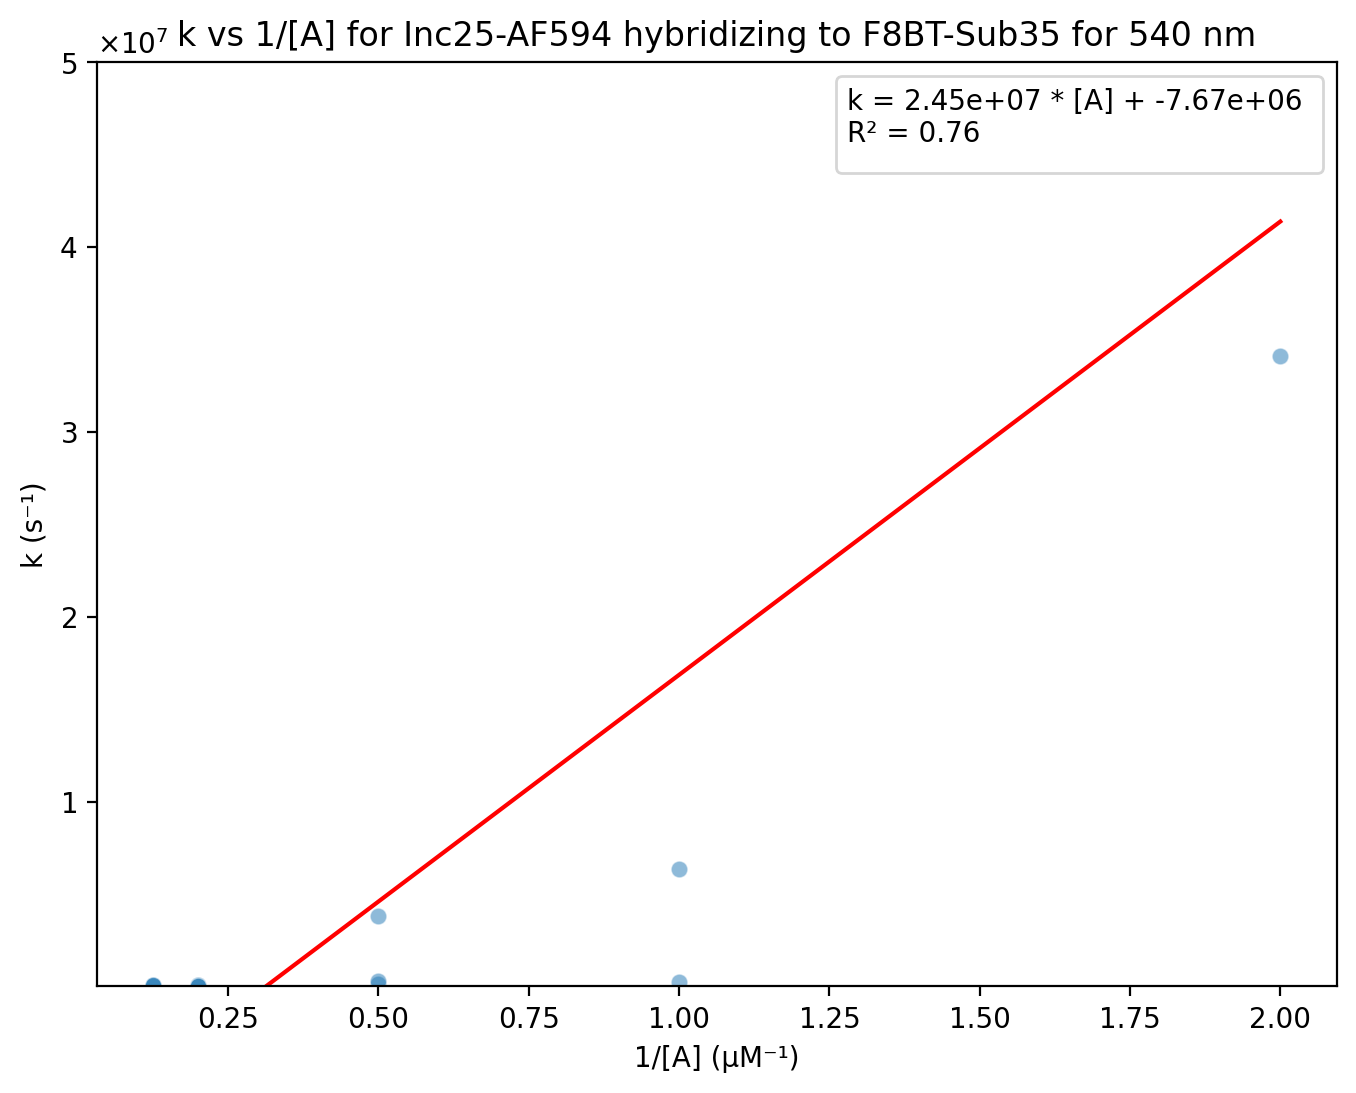

In [34]:
plot_k_vs_concentration(dfrates, wavelength=540)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
/var/folders/zg/rq8bx0nn20ldz2y3n2vmj4rw0000gn/T/ipykernel_4104/717663905.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f'k = {model.coef_[0]:.2e} * [A] + {model.intercept_:.2e} \nR² = {model.score(X, y):.2f}')


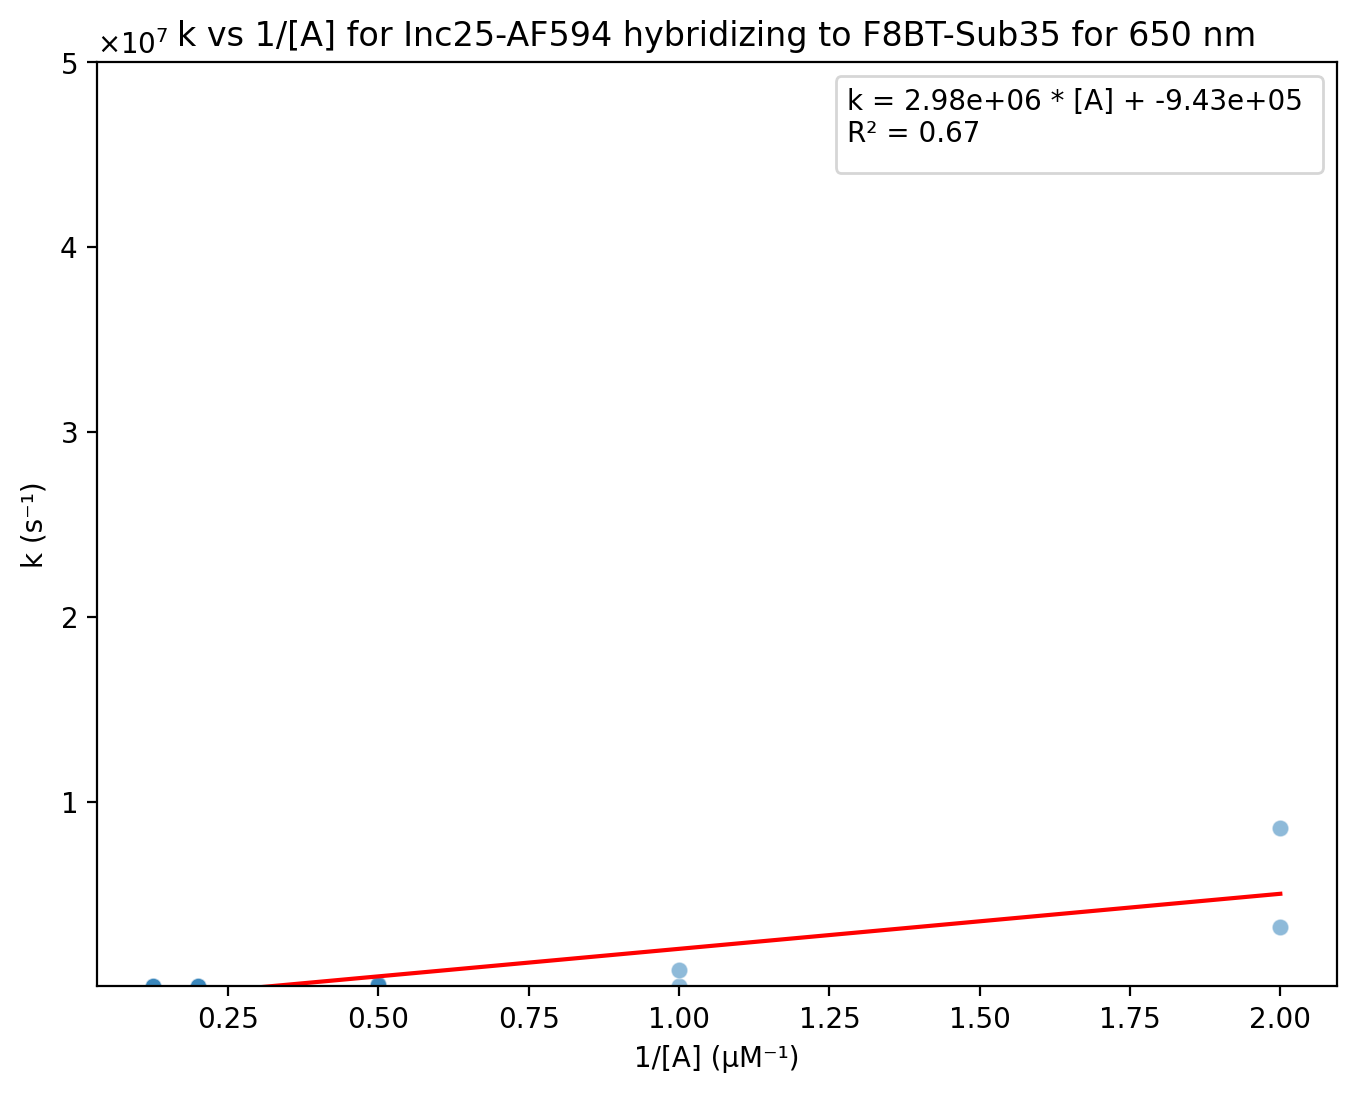

In [38]:
plot_k_vs_concentration(dfrates, wavelength=650) #or 540 or 650